# Plot Waveform

TypeError: ticklabel_format() got an unexpected keyword argument 'fontsize'

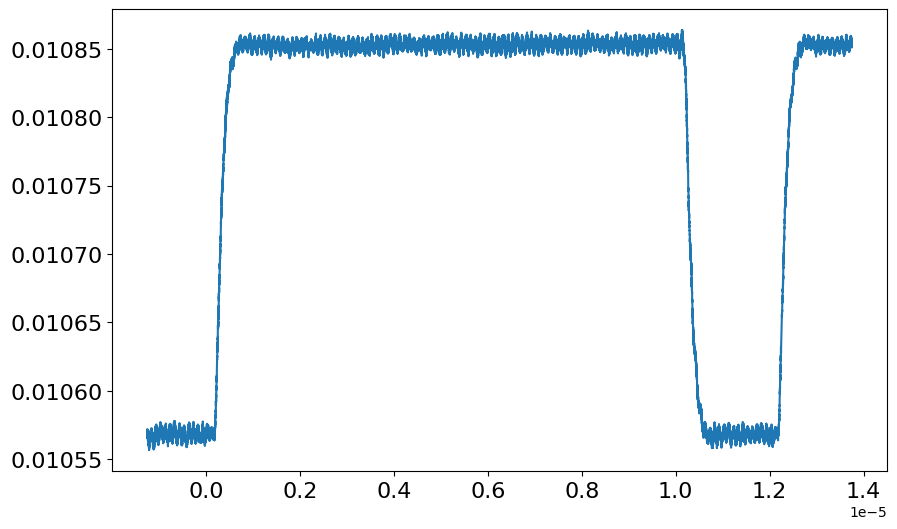

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load CSV (skip header row)
data1_1 = np.loadtxt(r"D:\trina\TA_internal\waveforms_raw\dry\averaged_tau_2uS_0.csv", delimiter=",", skiprows=1)
data1_2 = np.loadtxt(r"D:\trina\TA_internal\waveforms_raw\dry\averaged_tau_5000uS_39.csv", delimiter=",", skiprows=1)

time1_1 = data1_1[:, 0]
voltage1_1 = data1_1[:, 1]

# Plot
plt.figure(figsize=(10,6))
plt.plot(time1_1, voltage1_1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Time (s)",fontsize=16)
plt.ylabel("Voltage (V)",fontsize=16)
# plt.title("Oscilloscope Waveform")
plt.grid(True)
plt.show()


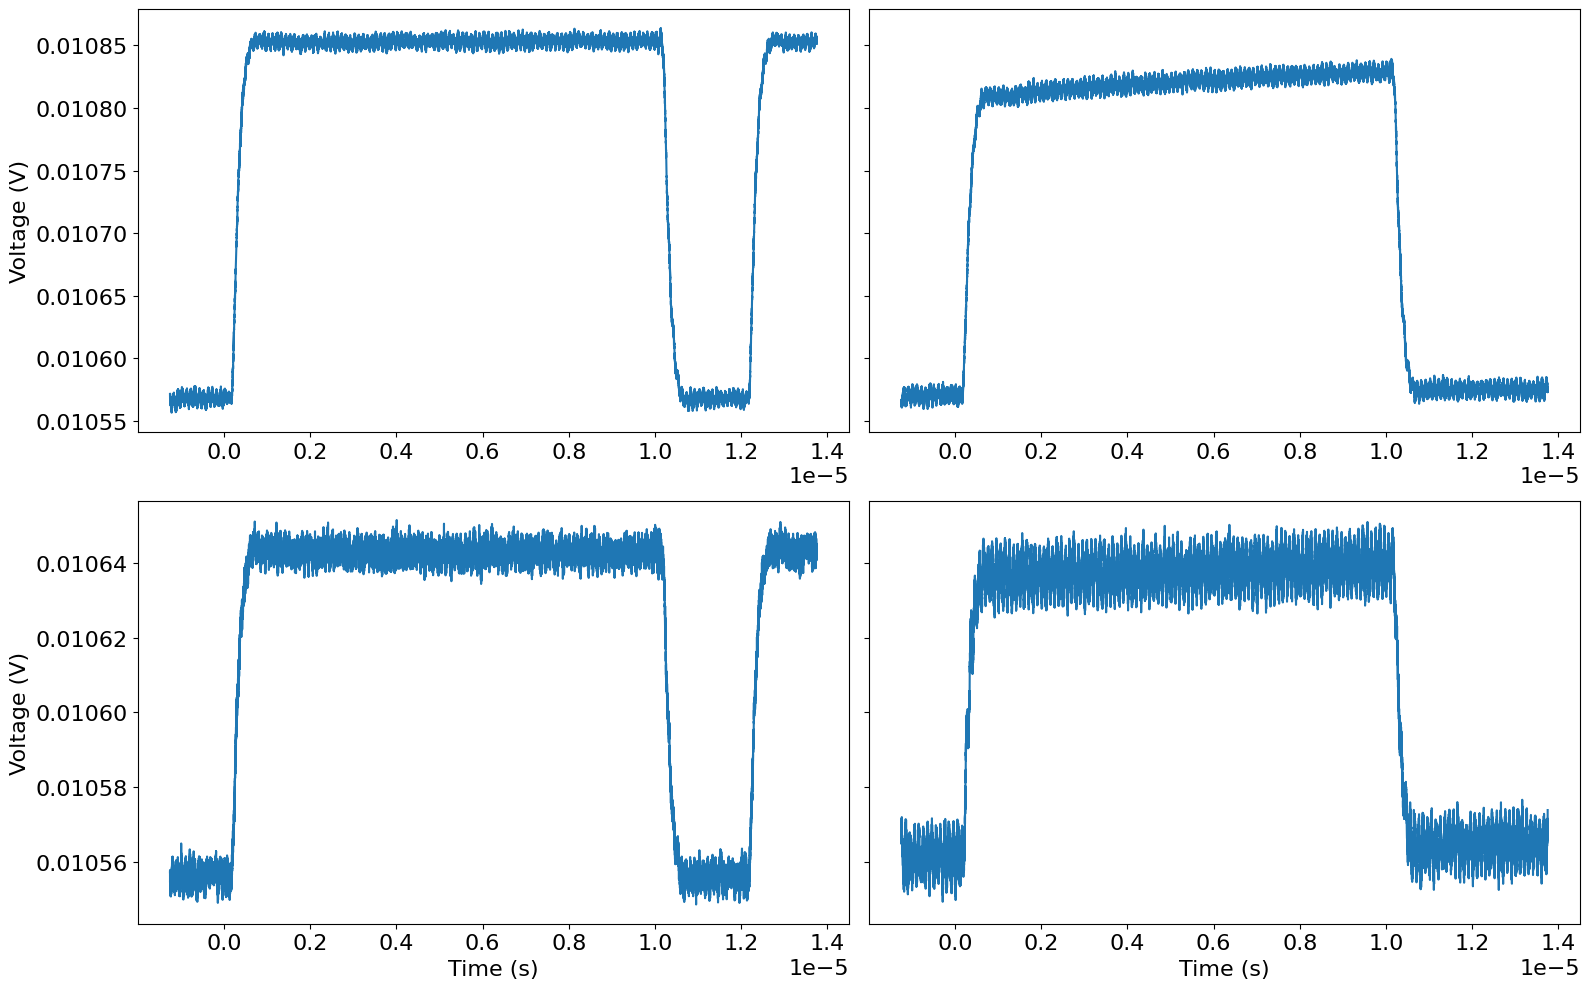

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Load CSV files
data1_1 = np.loadtxt(
    r"D:\trina\TA_internal\waveforms_raw\dry\1_averaged_tau_2uS_0.csv",
    delimiter=",",
    skiprows=1
)

data1_2 = np.loadtxt(
    r"D:\trina\TA_internal\waveforms_raw\dry\1_averaged_tau_5000uS_39.csv",
    delimiter=",",
    skiprows=1
)

data2_1 = np.loadtxt(
    r"D:\trina\TA_internal\waveforms_raw\100uM\1_averaged_tau_2uS_0.csv",
    delimiter=",",
    skiprows=1
)

data2_2 = np.loadtxt(
    r"D:\trina\TA_internal\waveforms_raw\100uM\1_averaged_tau_5000uS_39.csv",
    delimiter=",",
    skiprows=1
)

# Extract time and voltage
time1_1 = data1_1[:, 0]
voltage1_1 = data1_1[:, 1]

time1_2 = data1_2[:, 0]
voltage1_2 = data1_2[:, 1]

time2_1 = data2_1[:, 0]
voltage2_1 = data2_1[:, 1]

time2_2 = data2_2[:, 0]
voltage2_2 = data2_2[:, 1]

# Create 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey="row")

# Row 1: dry sample
axes[0, 0].plot(time1_1, voltage1_1)
axes[0, 0].set_ylabel("Voltage (V)", fontsize=16)
# axes[0, 0].set_title(r"Dry, $\tau = 2~\mu$s", fontsize=16)
axes[0, 0].tick_params(axis="both", labelsize=16)
# axes[0, 0].grid(True)

axes[0, 1].plot(time1_2, voltage1_2)
# axes[0, 1].set_title(r"Dry, $\tau = 5000~\mu$s", fontsize=16)
axes[0, 1].tick_params(axis="both", labelsize=16)
# axes[0, 1].grid(True)

# Row 2: 100 uM sample
axes[1, 0].plot(time2_1, voltage2_1)
axes[1, 0].set_xlabel("Time (s)", fontsize=16)
axes[1, 0].set_ylabel("Voltage (V)", fontsize=16)
# axes[1, 0].set_title(r"100 $\mu$M, $\tau = 2~\mu$s", fontsize=16)
axes[1, 0].tick_params(axis="both", labelsize=16)
# axes[1, 0].grid(True)

axes[1, 1].plot(time2_2, voltage2_2)
axes[1, 1].set_xlabel("Time (s)", fontsize=16)
# axes[1, 1].set_title(r"100 $\mu$M, $\tau = 5000~\mu$s", fontsize=16)
axes[1, 1].tick_params(axis="both", labelsize=16)
# axes[1, 1].grid(True)

# Increase fontsize of scientific notation offset text, e.g. 1e-5
fig.canvas.draw()
for ax in axes.flat:
    ax.xaxis.get_offset_text().set_fontsize(16)
    ax.yaxis.get_offset_text().set_fontsize(16)

plt.tight_layout()
plt.savefig("graphs/dry_100uM_waveforms.png", dpi=400)
plt.show()

# Calculating SNR (excel)

In [21]:
import os
import re
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================

base_dir = r"D:\trina\TA_internal\waveforms_raw"

sample_folders = ["dry", "water", "1uM", "10uM", "100uM"]

noise_rms = 0.000219  # V

output_excel = r"D:\trina\TA_internal\waveforms_raw\waveform_amplitude_snr.xlsx"

# Filename pattern:
# 1_averaged_tau_2uS_0.csv
# 5_averaged_tau_5000uS_39.csv
pattern = re.compile(
    r"(?P<acq>\d+)_averaged_tau_(?P<tau>[\d.]+)uS_(?P<tau_index>\d+)\.csv",
    re.IGNORECASE
)

# =========================
# PROCESS DATA
# =========================

results = []

for sample in sample_folders:
    folder_path = os.path.join(base_dir, sample)

    if not os.path.isdir(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    for filename in os.listdir(folder_path):
        if not filename.endswith(".csv"):
            continue

        match = pattern.match(filename)
        if match is None:
            print(f"Skipped unmatched filename: {filename}")
            continue

        acq_order = int(match.group("acq"))
        tau_us = float(match.group("tau"))
        tau_index = int(match.group("tau_index"))

        file_path = os.path.join(folder_path, filename)

        try:
            data = np.loadtxt(file_path, delimiter=",", skiprows=1)
        except Exception as e:
            print(f"Could not read {file_path}: {e}")
            continue

        voltage = data[:, 1]

        vmax = np.max(voltage)
        vmin = np.min(voltage)
        delta = vmax - vmin
        snr = delta / noise_rms

        results.append({
            "sample": sample,
            "acq_order": acq_order,
            "tau_us": tau_us,
            "tau_index": tau_index,
            "max": vmax,
            "min": vmin,
            "delta": delta,
            "SNR": snr,
            "filename": filename
        })

# Convert to DataFrame
df = pd.DataFrame(results)

# Sort neatly
df = df.sort_values(
    by=["sample", "acq_order", "tau_index"],
    ascending=True
)

# Save all results
df.to_excel(output_excel, index=False)

print("Done.")
print(f"Saved to: {output_excel}")
print(df.head())

Done.
Saved to: D:\trina\TA_internal\waveforms_raw\waveform_amplitude_snr.xlsx
   sample  acq_order  tau_us  tau_index       max       min     delta  \
40  100uM          1     2.0          0  0.010652  0.010549  0.000103   
41  100uM          1  5000.0         39  0.010651  0.010549  0.000102   
42  100uM          2     2.0          0  0.010657  0.010540  0.000117   
43  100uM          2  5000.0         39  0.010657  0.010544  0.000113   
44  100uM          3     2.0          0  0.010658  0.010555  0.000104   

         SNR                      filename  
40  0.470293      1_averaged_tau_2uS_0.csv  
41  0.464600  1_averaged_tau_5000uS_39.csv  
42  0.534782      2_averaged_tau_2uS_0.csv  
43  0.517646  2_averaged_tau_5000uS_39.csv  
44  0.474468      3_averaged_tau_2uS_0.csv  


# Error across dark-times


Processing variation: dry
Number of files loaded: 35
Data Type Label
random 10 comb.    10
random 20 comb.    20
regular             5
Name: Filename, dtype: int64

Processing variation: water
Number of files loaded: 33
Data Type Label
random 10 comb.    10
random 20 comb.    20
regular             3
Name: Filename, dtype: int64

Processing variation: 1 uM
Number of files loaded: 35
Data Type Label
random 10 comb.    10
random 20 comb.    20
regular             5
Name: Filename, dtype: int64

Processing variation: 10 uM
Number of files loaded: 35
Data Type Label
random 10 comb.    10
random 20 comb.    20
regular             5
Name: Filename, dtype: int64

Processing variation: 100 uM
Number of files loaded: 35
Data Type Label
random 10 comb.    10
random 20 comb.    20
regular             5
Name: Filename, dtype: int64


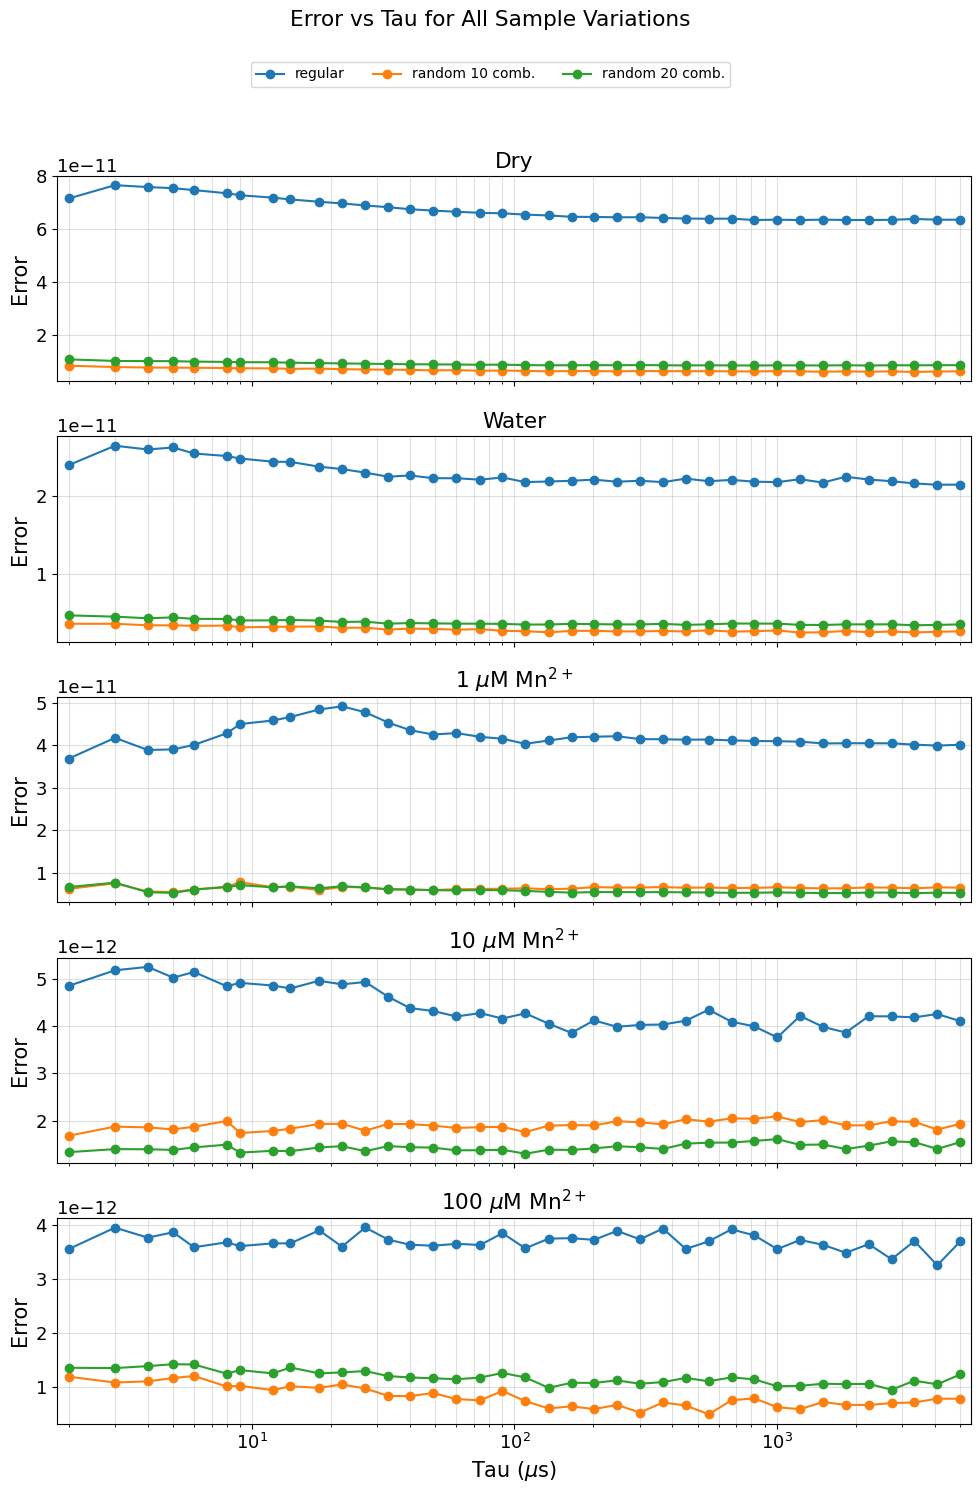


=== Error vs Tau Analysis ===
Number of variations : 5
Saved Excel file     : error_vs_tau_all_variations_all_types_new.xlsx
Saved stacked plot   : error_vs_tau_all_variations_stacked_no-errorbar_new.png

Files loaded by variation and data type:
Variation  Data Type Label
1 uM       random 10 comb.    10
           random 20 comb.    20
           regular             5
10 uM      random 10 comb.    10
           random 20 comb.    20
           regular             5
100 uM     random 10 comb.    10
           random 20 comb.    20
           regular             5
dry        random 10 comb.    10
           random 20 comb.    20
           regular             5
water      random 10 comb.    10
           random 20 comb.    20
           regular             3
Name: Filename, dtype: int64


In [30]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# USER SETTINGS
# ============================================================

# Folder names
variations = ["dry", "water", "1 uM", "10 uM", "100 uM"]

# Display names for plot titles
variation_labels = {
    "dry": "Dry",
    "water": "Water",
    "1 uM": r"1 $\mu$M Mn$^{2+}$",
    "10 uM": r"10 $\mu$M Mn$^{2+}$",
    "100 uM": r"100 $\mu$M Mn$^{2+}$"
}

# Data type folder names
data_type_order = ["regular", "random", "random2"]

# Display names for legend
data_type_labels = {
    "regular": "regular",
    "random": "random 10 comb.",
    "random2": "random 20 comb."
}

output_excel = "error_vs_tau_all_variations_all_types_new.xlsx"
output_stacked_plot = "error_vs_tau_all_variations_stacked_no-errorbar_new.png"


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name

    raise ValueError(f"None of these columns were found: {possible_names}")


def load_acquisition_file(filename):
    df = pd.read_excel(filename)

    tau_col = find_column(
        df,
        ["Tau", "Tau (us)", "tau", "Dark Time", "Dark time"]
    )

    signal_col = find_column(
        df,
        ["Signal", "signal", "Signal Ratio", "PL Ratio"]
    )

    error_col = find_column(
        df,
        ["Signal Error", "Error", "signal error", "Std", "SEM"]
    )

    df = df[[tau_col, signal_col, error_col]].copy()
    df.columns = ["Tau", "Signal", "Signal Error"]

    df = df.dropna()
    df = df.sort_values("Tau").reset_index(drop=True)

    return df


def get_data_type_folders(base_folder):
    if not os.path.isdir(base_folder):
        raise NotADirectoryError(f"Variation folder not found: {base_folder}")

    folders = []

    for data_type in data_type_order:
        folder_path = os.path.join(base_folder, data_type)

        if os.path.isdir(folder_path):
            folders.append((data_type, folder_path))

    if len(folders) == 0:
        raise FileNotFoundError(f"No data type folders found inside: {base_folder}")

    return folders


def calculate_sem(x):
    if len(x) <= 1:
        return np.nan

    return x.std(ddof=1) / np.sqrt(len(x))


def analyze_one_variation(variation):
    base_folder = f"./raw_data/new/{variation}"

    data_type_folders = get_data_type_folders(base_folder)

    files_with_type = []

    for data_type, folder_path in data_type_folders:
        files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))

        if len(files) == 0:
            print(f"Warning: no Excel files found in {folder_path}, skipped.")
            continue

        for file in files:
            files_with_type.append((file, data_type))

    if len(files_with_type) == 0:
        raise FileNotFoundError(
            f"No Excel files found inside any subfolder of {base_folder}."
        )

    all_data = []

    for i, (file, data_type) in enumerate(files_with_type, start=1):
        df = load_acquisition_file(file)

        df["Index"] = i
        df["Variation"] = variation
        df["Data Type"] = data_type
        df["Data Type Label"] = data_type_labels.get(data_type, data_type)
        df["Filename"] = os.path.basename(file)

        all_data.append(df)

    combined = pd.concat(all_data, ignore_index=True)

    summary_by_type = combined.groupby(
        ["Variation", "Data Type", "Data Type Label", "Tau"]
    ).agg(
        Mean_Signal=("Signal", "mean"),
        Std_Across_Files=("Signal", "std"),
        SEM_Across_Files=("Signal", calculate_sem),
        Mean_Signal_Error=("Signal Error", "mean"),
        RMS_Signal_Error=("Signal Error", lambda x: np.sqrt(np.mean(x ** 2))),
        N_Files=("Signal", "count")
    ).reset_index()

    summary_by_type = summary_by_type.sort_values(
        ["Variation", "Data Type", "Tau"]
    ).reset_index(drop=True)

    summary_by_type["Total_Error"] = np.sqrt(
        summary_by_type["Std_Across_Files"] ** 2
        + summary_by_type["RMS_Signal_Error"] ** 2
    )

    return summary_by_type, combined, files_with_type


# ============================================================
# ANALYZE ALL VARIATIONS
# ============================================================

all_summary = []
all_raw = []

for variation in variations:
    print(f"\nProcessing variation: {variation}")

    summary_by_type, combined, files_with_type = analyze_one_variation(variation)

    all_summary.append(summary_by_type)
    all_raw.append(combined)

    print(f"Number of files loaded: {len(files_with_type)}")
    print(combined.groupby("Data Type Label")["Filename"].nunique())


summary_all = pd.concat(all_summary, ignore_index=True)
raw_all = pd.concat(all_raw, ignore_index=True)


# ============================================================
# SAVE TO EXCEL
# ============================================================

with pd.ExcelWriter(output_excel) as writer:
    summary_all.to_excel(writer, sheet_name="Error vs Tau Summary", index=False)
    raw_all.to_excel(writer, sheet_name="Combined Raw Data", index=False)


# ============================================================
# STACKED VERTICAL PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(variations),
    ncols=1,
    figsize=(10, 15),
    sharex=True
)

legend_handles = {}
legend_labels = {}

for ax, variation in zip(axes, variations):
    variation_data = summary_all[summary_all["Variation"] == variation]

    for data_type in data_type_order:
        subset = variation_data[variation_data["Data Type"] == data_type]

        if subset.empty:
            continue

        label = data_type_labels.get(data_type, data_type)

        plot_obj = ax.errorbar(
            subset["Tau"],
            subset["Std_Across_Files"],
            # yerr=subset["SEM_Across_Files"],
            fmt="o-",
            capsize=4,
            label=label
        )

        legend_handles[label] = plot_obj
        legend_labels[label] = label

    ax.set_xscale("log")
    ax.set_ylabel("Error")
    ax.set_title(variation_labels.get(variation, variation))
    ax.grid(True, which="both", alpha=0.4)

    # Use scientific notation for y-axis
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))


# Set x-axis limit to avoid too much empty space on the left
tau_min = summary_all["Tau"].min()
tau_max = summary_all["Tau"].max()

for ax in axes:
    ax.set_xlim(tau_min * 0.9, tau_max * 1.1)

axes[-1].set_xlabel(r"Tau ($\mu$s)")

fig.suptitle(
    "Error vs Tau for All Sample Variations",
    y=0.995
)

fig.legend(
    legend_handles.values(),
    legend_labels.values(),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=3,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(output_stacked_plot, dpi=300)
plt.show()


# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n=== Error vs Tau Analysis ===")
print(f"Number of variations : {len(variations)}")
print(f"Saved Excel file     : {output_excel}")
print(f"Saved stacked plot   : {output_stacked_plot}")

print("\nFiles loaded by variation and data type:")
print(
    raw_all.groupby(["Variation", "Data Type Label"])["Filename"].nunique()
)

In [37]:
get_data_type_folders

<function __main__.get_data_type_folders(base_folder)>

# Plots

## T1 values vs sample variations

### Single exp

['variations', 'T1 regular', 'std regular', 'RMSE regular', 'SNR regular', 'chi regular', 'T1 random 10 combinations', 'std random 10 combinations', 'RMSE random 10 combinations', 'SNR random 10 combinations', 'chi random 10 combinations', 'T1 random 20 combinations', 'std random 20 combinations', 'RMSE random 20 combinations', 'SNR random 20 combinations', 'chi random 20 combinations', 'T1 bootstrap', 'std bootstrap', 'RMSE bootstrap', 'SNR bootstrap', 'chi bootstrap']


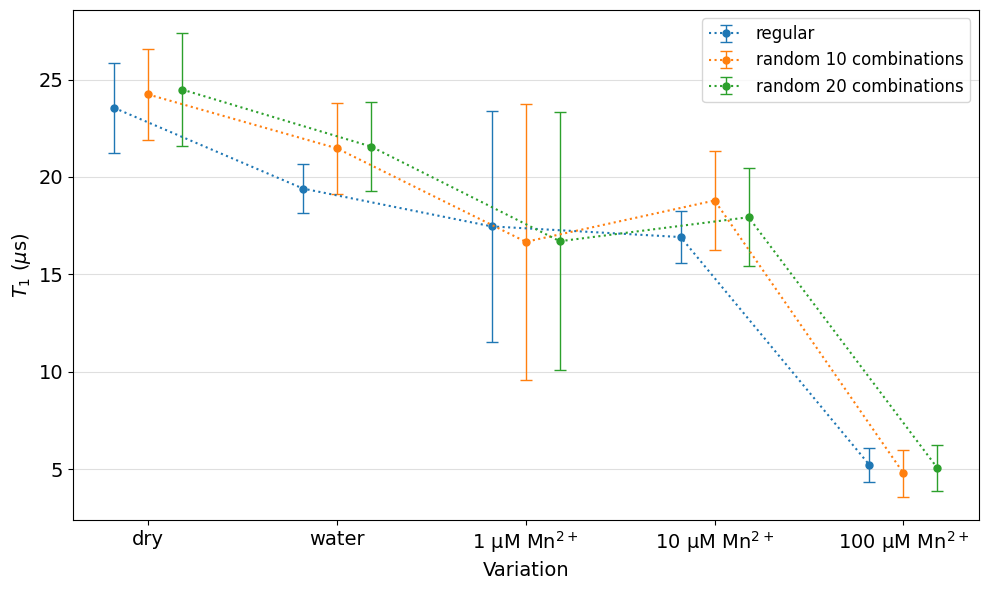

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
file_name = "a_recap.xlsx"
sheet_name = "single_rec"

df = pd.read_excel(file_name, sheet_name=sheet_name)

# Clean column names
df.columns = df.columns.str.strip()

# =========================
# RENAME COLUMNS: samples -> combinations
# =========================
df = df.rename(columns={
    "T1 random 10 samples": "T1 random 10 combinations",
    "std random 10 samples": "std random 10 combinations",
    "RMSE random 10 samples": "RMSE random 10 combinations",
    "SNR random 10 samples": "SNR random 10 combinations",
    "chi random 10 samples": "chi random 10 combinations",

    "T1 random 20 samples": "T1 random 20 combinations",
    "std random 20 samples": "std random 20 combinations",
    "RMSE random 20 samples": "RMSE random 20 combinations",
    "SNR random 20 samples": "SNR random 20 combinations",
    "chi random 20 samples": "chi random 20 combinations"
})

# Optional: print updated column names
print(df.columns.tolist())

# =========================
# DEFINE COLUMNS
# =========================
variation_col = "variations"

methods = {
    "regular": {
        "t1": "T1 regular",
        "std": "std regular"
    },
    "random 10 combinations": {
        "t1": "T1 random 10 combinations",
        "std": "std random 10 combinations"
    },
    "random 20 combinations": {
        "t1": "T1 random 20 combinations",
        "std": "std random 20 combinations"
    }
    # "bootstrap": {
    #     "t1": "T1 bootstrap",
    #     "std": "std bootstrap"
    # }
}

# =========================
# PREPARE X-AXIS
# =========================
# variations = df[variation_col].astype(str).values
variations = ["dry", "water", r"1 μM Mn$^{2+}$", r"10 μM Mn$^{2+}$", r"100 μM Mn$^{2+}$"]
x = np.arange(len(variations))

# Horizontal offsets to prevent error bars from overlapping
offsets = np.linspace(-0.18, 0.18, len(methods))

# =========================
# PLOT T1 VALUES WITH STD ERROR BARS
# =========================
plt.figure(figsize=(10, 6))

for offset, (label, cols) in zip(offsets, methods.items()):
    t1 = df[cols["t1"]].values
    std = df[cols["std"]].values

    plt.errorbar(
        x + offset,
        t1,
        yerr=std,
        marker="o",
        linestyle="dotted",
        capsize=4,
        elinewidth=1,
        linewidth=1.5,
        markersize=5,
        label=label
    )

plt.xticks(x, variations,fontsize=14)
plt.xlabel("Variation", fontsize=14)
plt.ylabel(r"$T_1$ ($\mu$s)", fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, axis="y", alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("graphs/T1_errorbar_plot_single_no-bootstrap.png", dpi=300, bbox_inches="tight")
plt.show()

### Bi-exp

['variations', 'T1 long reg', 'std T1 long reg', 'T1 short', 'std T1 short', 'chi regular', 'RMSE regular', 'Mean T1 reg', 'Mean T1 long (random)', 'std', 'Short tau', 'std.1', 'chi random 10 samples', 'RMSE random 10 samples', 'Long tau rand2', 'std.2', 'Short tau rand2', 'Unnamed: 17', 'chi random 20 samples', 'RMSE random 20 samples', 'T1 long bootstrap', 'std T1 long bootstrap', 'T1 short bootstrap', 'std T1 short bootstrap', 'chi bootstrap', 'RMSE bootstrap']


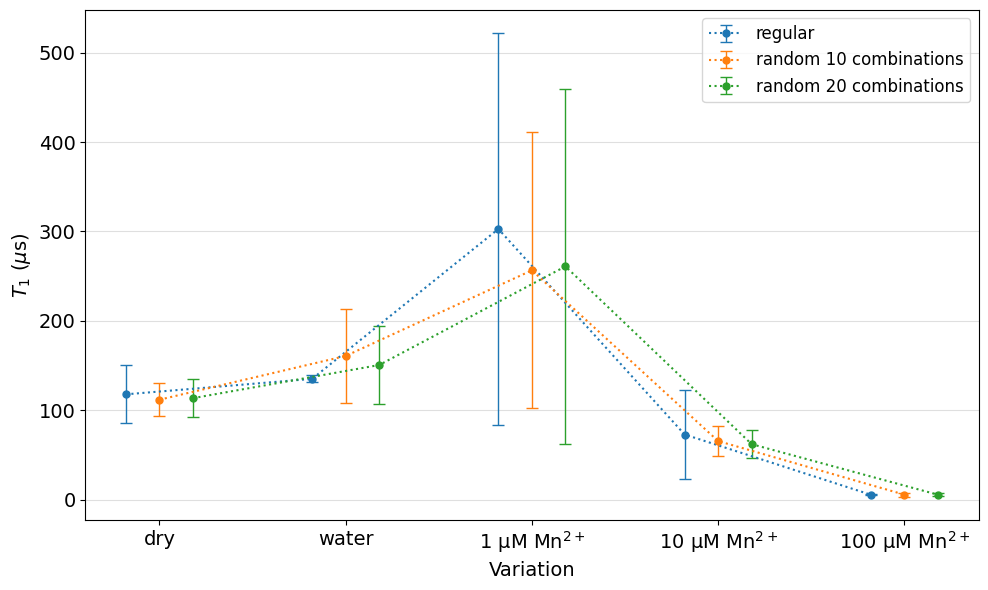

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
file_name = "a_recap.xlsx"
sheet_name = "biexp_rec (2)"

df = pd.read_excel(file_name, sheet_name=sheet_name)
df.columns = df.columns.str.strip()

print(df.columns.tolist())

# =========================
# DEFINE COLUMNS FOR LONG COMPONENT
# =========================
variation_col = "variations"

methods_long = {
    "regular": {
        "t1": "T1 long reg",
        "std": "std T1 long reg"
    },
    "random 10 combinations": {
        "t1": "Mean T1 long (random)",
        "std": "std"
    },
    "random 20 combinations": {
        "t1": "Long tau rand2",
        "std": "std.2"
    }
    # "bootstrap": {
    #     "t1": "T1 long bootstrap",
    #     "std": "std T1 long bootstrap"
    # }
}

# =========================
# PREPARE X-AXIS
# =========================
# variations = df[variation_col].astype(str).values
variations = ["dry", "water", r"1 μM Mn$^{2+}$", r"10 μM Mn$^{2+}$", r"100 μM Mn$^{2+}$"]
x = np.arange(len(variations))

offsets = np.linspace(-0.18, 0.18, len(methods_long))

# =========================
# PLOT LONG COMPONENT
# =========================
plt.figure(figsize=(10, 6))

for offset, (label, cols) in zip(offsets, methods_long.items()):
    t1 = df[cols["t1"]].values
    std = df[cols["std"]].values

    plt.errorbar(
        x + offset,
        t1,
        yerr=std,
        marker="o",
        linestyle="dotted",
        capsize=4,
        elinewidth=1,
        linewidth=1.5,
        markersize=5,
        label=label
    )

plt.xticks(x, variations,fontsize=14)
plt.xlabel("Variation", fontsize=14)
plt.ylabel(r"$T_1$ ($\mu$s)", fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, axis="y", alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("graphs/T1_long_biexponential_errorbar_no-bootstrap.png", dpi=300, bbox_inches="tight")
plt.show()

['variations', 'T1 long reg', 'std T1 long reg', 'T1 short', 'std T1 short', 'chi regular', 'RMSE regular', 'Mean T1 reg', 'Mean T1 long (random)', 'std', 'Short tau', 'std.1', 'chi random 10 samples', 'RMSE random 10 samples', 'Long tau rand2', 'std.2', 'Short tau rand2', 'Unnamed: 17', 'chi random 20 samples', 'RMSE random 20 samples', 'T1 long bootstrap', 'std T1 long bootstrap', 'T1 short bootstrap', 'std T1 short bootstrap', 'chi bootstrap', 'RMSE bootstrap']


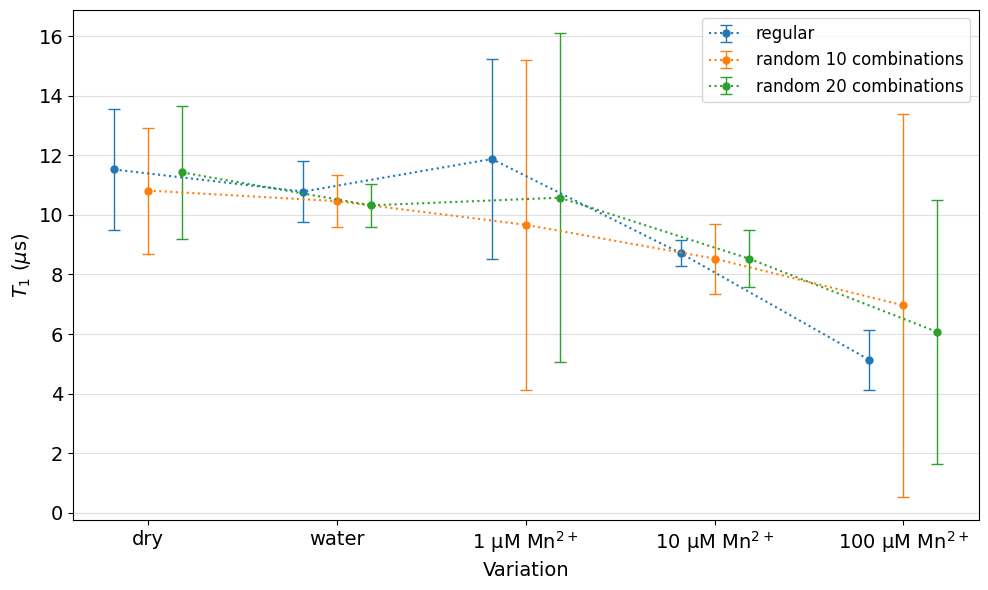

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
file_name = "a_recap.xlsx"
sheet_name = "biexp_rec (2)"

df = pd.read_excel(file_name, sheet_name=sheet_name)
df.columns = df.columns.str.strip()

print(df.columns.tolist())

# =========================
# DEFINE COLUMNS FOR SHORT COMPONENT
# =========================
variation_col = "variations"

methods_short = {
    "regular": {
        "t1": "T1 short",
        "std": "std T1 short"
    },
    "random 10 combinations": {
        "t1": "Short tau",
        "std": "std.1"
    },
    "random 20 combinations": {
        "t1": "Short tau rand2",
        "std": "Unnamed: 17"
    }
    # "bootstrap": {
    #     "t1": "T1 short bootstrap",
    #     "std": "std T1 short bootstrap"
    # }
}

# =========================
# PREPARE X-AXIS
# =========================
# variations = df[variation_col].astype(str).values
variations = ["dry", "water", r"1 μM Mn$^{2+}$", r"10 μM Mn$^{2+}$", r"100 μM Mn$^{2+}$"]
x = np.arange(len(variations))

# Horizontal offsets to prevent overlapping error bars
offsets = np.linspace(-0.18, 0.18, len(methods_short))

# =========================
# PLOT SHORT COMPONENT
# =========================
plt.figure(figsize=(10, 6))

for offset, (label, cols) in zip(offsets, methods_short.items()):
    t1 = df[cols["t1"]].values
    std = df[cols["std"]].values

    plt.errorbar(
        x + offset,
        t1,
        yerr=std,
        marker="o",
        linestyle="dotted",
        capsize=4,
        elinewidth=1,
        linewidth=1.5,
        markersize=5,
        label=label
    )

plt.xticks(x, variations,fontsize=14)
plt.xlabel("Variation", fontsize=14)
plt.ylabel(r"$T_1$ ($\mu$s)", fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, axis="y", alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("graphs/T1_short_biexponential_errorbar_no-bootstrap.png", dpi=300, bbox_inches="tight")

plt.show()

# Plot the Data of Each Variation (Analyzing the Decay Characteristics)


Processing variation: dry
Sampling method: random
Number of files: 10

Processing variation: water
Sampling method: random
Number of files: 10

Processing variation: 1 uM
Sampling method: random
Number of files: 10

Processing variation: 10 uM
Sampling method: random
Number of files: 10

Processing variation: 100 uM
Sampling method: random
Number of files: 9


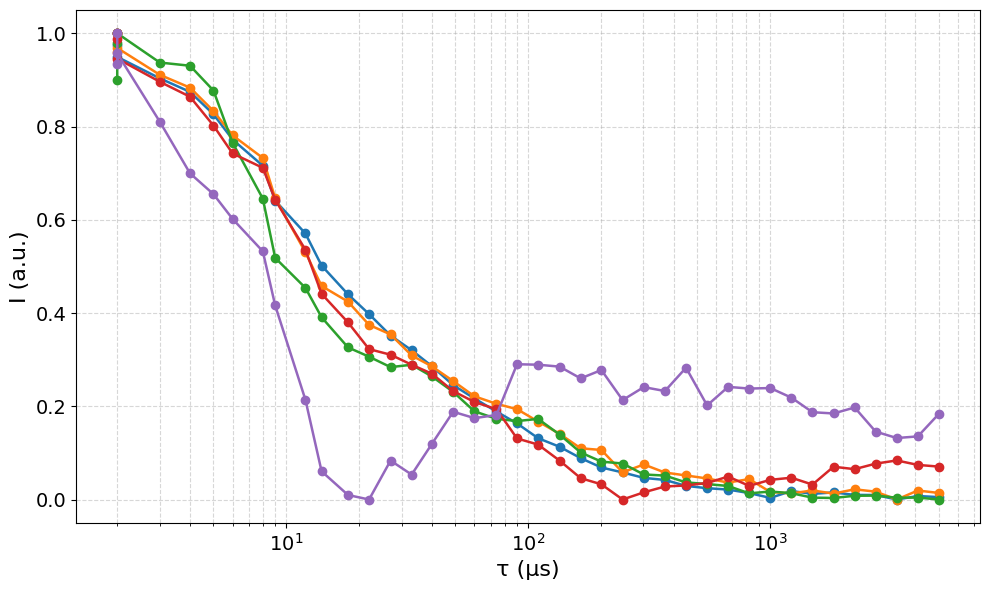

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================

# Change this to: "regular", "random", or "random2"
sampling_method = input("regular/random")

# Main folder containing dry/, water/, 1 uM/, 10 uM/, 100 uM/
base_path = "./raw_data/old"

# Variations to analyze
variations = ["dry", "water", "1 uM", "10 uM", "100 uM"]

# Column names in your Excel files
tau_col = "Tau (us)"
signal_col = "Signal"


# ============================================================
# HELPER FUNCTION
# ============================================================

def normalize_signal(signal):
    """
    Normalize signal to the range 0-1 using:

    normalized = (Signal - min(Signal)) / (max(Signal) - min(Signal))
    """

    signal_min = np.min(signal)
    signal_max = np.max(signal)

    if signal_max == signal_min:
        return np.full_like(signal, np.nan, dtype=float)

    return (signal - signal_min) / (signal_max - signal_min)


# ============================================================
# MAIN PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# var_labels = ["dry", "water", "1 μM", "10 μM", "100 μM"]
var_labels = ["dry", "water", r"1 μM Mn$^{2+}$", r"10 μM Mn$^{2+}$", r"100 μM Mn$^{2+}$"]

for i,variation in enumerate(variations):

    folder_path = os.path.join(base_path, variation, sampling_method)

    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    excel_files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))

    if len(excel_files) == 0:
        print(f"No Excel files found in: {folder_path}")
        continue

    print(f"\nProcessing variation: {variation}")
    print(f"Sampling method: {sampling_method}")
    print(f"Number of files: {len(excel_files)}")

    signal_list = []
    tau_reference = None

    for file in excel_files:
        df = pd.read_excel(file)

        if tau_col not in df.columns or signal_col not in df.columns:
            print(f"Skipped file because required columns were not found: {file}")
            continue

        tau = df[tau_col].to_numpy(dtype=float)
        signal = df[signal_col].to_numpy(dtype=float)

        # Use the first valid tau as reference
        if tau_reference is None:
            tau_reference = tau
        else:
            if len(tau) != len(tau_reference):
                print(f"Skipped file due to different tau length: {file}")
                continue

            if not np.allclose(tau, tau_reference):
                print(f"Skipped file due to different tau values: {file}")
                continue

        signal_list.append(signal)

    if len(signal_list) == 0:
        print(f"No valid signal data found for variation: {variation}")
        continue

    # Convert to array: shape = number of files x number of tau points
    signal_array = np.array(signal_list)

    # Average the raw signal across all files in the selected variation
    average_signal = np.mean(signal_array, axis=0)

    # Normalize only for plotting
    normalized_average_signal = normalize_signal(average_signal)

    # Plot this variation on the same graph
    plt.plot(
        tau_reference,
        normalized_average_signal,
        marker="o",
        linewidth=1.8,
        label=var_labels[i]
    )



# ============================================================
# GRAPH SETTINGS
# ============================================================

plt.xscale("log")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(-1,2000)
plt.xlabel("τ (μs)",fontsize=16)
plt.ylabel("I (a.u.)",fontsize=16)
# plt.title(f"Normalized Decay Characteristics ({sampling_method} sampling)")
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
# plt.legend(fontsize=13)
plt.tight_layout()


# Optional: save figure
plt.savefig(f"graphs/normalized-signal_{sampling_method}_plot_10x6.png", dpi=300, bbox_inches="tight")

plt.show()


Processing variation: dry (norm)
Number of files: 5

Processing variation: water (norm)
Number of files: 4

Processing variation: 1 uM (norm)
Number of files: 12

Processing variation: 10 uM (norm)
Number of files: 5

Processing variation: 100 uM (norm)
Number of files: 7


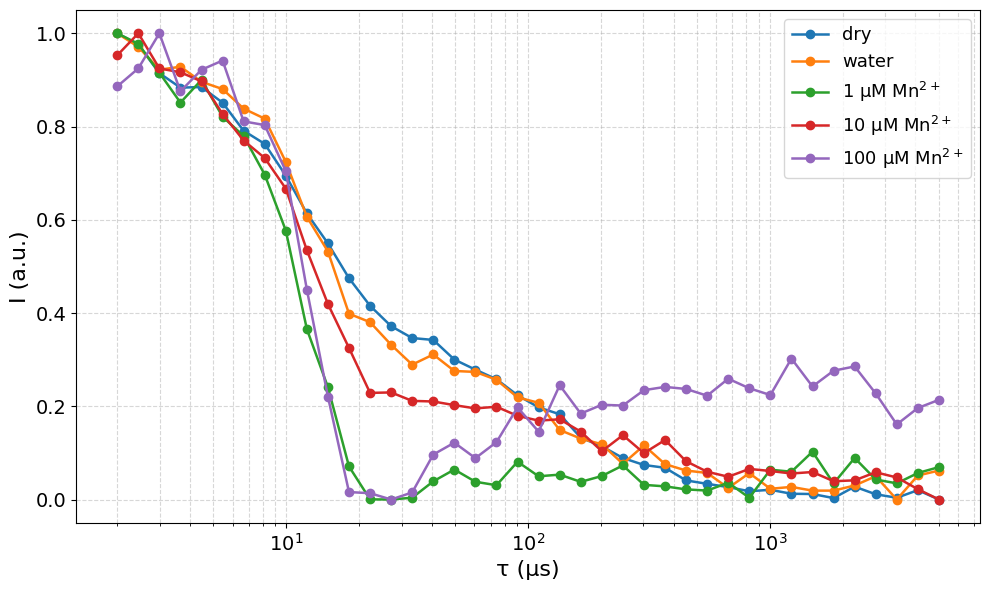

In [10]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================

# Change this to: "regular", "random", or "random2"
# sampling_method = input("regular/random")

# Main folder containing dry/, water/, 1 uM/, 10 uM/, 100 uM/
base_path = "./normalized"

# Variations to analyze
variations = ["dry (norm)", "water (norm)", "1 uM (norm)", "10 uM (norm)", "100 uM (norm)"]

# Column names in your Excel files
tau_col = "Tau (us)"
signal_col = "Signal"


# ============================================================
# HELPER FUNCTION
# ============================================================

def normalize_signal(signal):
    """
    Normalize signal to the range 0-1 using:

    normalized = (Signal - min(Signal)) / (max(Signal) - min(Signal))
    """

    signal_min = np.min(signal)
    signal_max = np.max(signal)

    if signal_max == signal_min:
        return np.full_like(signal, np.nan, dtype=float)

    return (signal - signal_min) / (signal_max - signal_min)


# ============================================================
# MAIN PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# var_labels = ["dry", "water", "1 μM", "10 μM", "100 μM"]
var_labels = ["dry", "water", r"1 μM Mn$^{2+}$", r"10 μM Mn$^{2+}$", r"100 μM Mn$^{2+}$"]

for i,variation in enumerate(variations):

    folder_path = os.path.join(base_path, variation)

    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    excel_files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))

    if len(excel_files) == 0:
        print(f"No Excel files found in: {folder_path}")
        continue

    print(f"\nProcessing variation: {variation}")
    # print(f"Sampling method: {sampling_method}")
    print(f"Number of files: {len(excel_files)}")

    signal_list = []
    tau_reference = None

    for file in excel_files:
        df = pd.read_excel(file)

        if tau_col not in df.columns or signal_col not in df.columns:
            print(f"Skipped file because required columns were not found: {file}")
            continue

        tau = df[tau_col].to_numpy(dtype=float)
        signal = df[signal_col].to_numpy(dtype=float)

        # Use the first valid tau as reference
        if tau_reference is None:
            tau_reference = tau
        else:
            if len(tau) != len(tau_reference):
                print(f"Skipped file due to different tau length: {file}")
                continue

            if not np.allclose(tau, tau_reference):
                print(f"Skipped file due to different tau values: {file}")
                continue

        signal_list.append(signal)

    if len(signal_list) == 0:
        print(f"No valid signal data found for variation: {variation}")
        continue

    # Convert to array: shape = number of files x number of tau points
    signal_array = np.array(signal_list)

    # Average the raw signal across all files in the selected variation
    average_signal = np.mean(signal_array, axis=0)

    # Normalize only for plotting
    normalized_average_signal = normalize_signal(average_signal)

    # Plot this variation on the same graph
    plt.plot(
        tau_reference,
        normalized_average_signal,
        marker="o",
        linewidth=1.8,
        label=var_labels[i]
    )



# ============================================================
# GRAPH SETTINGS
# ============================================================

plt.xscale("log")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(-1,2000)
plt.xlabel("τ (μs)",fontsize=16)
plt.ylabel("I (a.u.)",fontsize=16)
# plt.title(f"Normalized Decay Characteristics ({sampling_method} sampling)")
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=13)
plt.tight_layout()


# Optional: save figure
plt.savefig(f"graphs/referenced-signal_plot_10x6.png", dpi=300, bbox_inches="tight")

plt.show()


Processing variation: dry
Folder: .\dry\regular
Number of files: 5

Processing variation: water
Folder: .\water\regular
Number of files: 3

Processing variation: 1 μM
Folder: .\1 uM\regular
Number of files: 5

Processing variation: 10 μM
Folder: .\10 uM\regular
Number of files: 5

Processing variation: 100 μM
Folder: .\100 uM\regular
Number of files: 5

Normalized data saved to:
processed_data\normalized_signal_regular.xlsx

Graph saved to:
graphs\normalized_signal_regular_plot_no-log.png


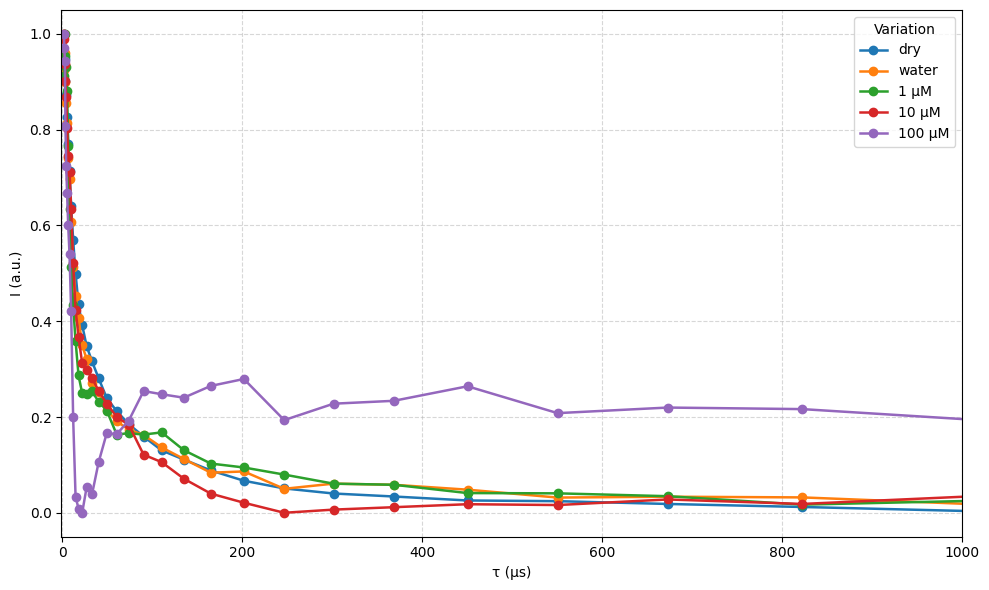

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# USER SETTINGS
# ============================================================

# Choose sampling method: "regular", "random", or "random2"
sampling_method = input("Input sampling method (regular/random/random2): ").strip()

# Main folder containing dry/, water/, 1 uM/, 10 uM/, 100 uM/
base_path = "."

# Variations folder names
variations = ["dry", "water", "1 uM", "10 uM", "100 uM"]

# Labels used in the plot and Excel file
var_labels = ["dry", "water", "1 μM", "10 μM", "100 μM"]

# Column names in the Excel files
tau_col = "Tau (us)"
signal_col = "Signal"

# Output folders
graph_folder = "graphs"
data_folder = "processed_data"

os.makedirs(graph_folder, exist_ok=True)
os.makedirs(data_folder, exist_ok=True)


# ============================================================
# HELPER FUNCTION
# ============================================================

def normalize_signal(signal):
    """
    Normalize signal using:

    normalized = (Signal - min(Signal)) / (max(Signal) - min(Signal))
    """

    signal_min = np.min(signal)
    signal_max = np.max(signal)

    if signal_max == signal_min:
        return np.full_like(signal, np.nan, dtype=float)

    return (signal - signal_min) / (signal_max - signal_min)


# ============================================================
# MAIN PROCESS
# ============================================================

plt.figure(figsize=(10, 6))

normalized_results = []

for i, variation in enumerate(variations):

    label = var_labels[i]
    folder_path = os.path.join(base_path, variation, sampling_method)

    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    excel_files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))

    if len(excel_files) == 0:
        print(f"No Excel files found in: {folder_path}")
        continue

    print(f"\nProcessing variation: {label}")
    print(f"Folder: {folder_path}")
    print(f"Number of files: {len(excel_files)}")

    signal_list = []
    tau_reference = None

    for file in excel_files:

        df = pd.read_excel(file)
        df.columns = df.columns.str.strip()

        if tau_col not in df.columns or signal_col not in df.columns:
            print(f"Skipped because required columns were not found: {file}")
            continue

        tau = df[tau_col].to_numpy(dtype=float)
        signal = df[signal_col].to_numpy(dtype=float)

        if tau_reference is None:
            tau_reference = tau
        else:
            if len(tau) != len(tau_reference):
                print(f"Skipped due to different tau length: {file}")
                continue

            if not np.allclose(tau, tau_reference):
                print(f"Skipped due to different tau values: {file}")
                continue

        signal_list.append(signal)

    if len(signal_list) == 0:
        print(f"No valid signal data found for variation: {label}")
        continue

    # Shape: number of files x number of tau points
    signal_array = np.array(signal_list)

    # Average raw signal across all files in one variation
    average_signal = np.mean(signal_array, axis=0)

    # Optional standard deviation between files
    std_signal = np.std(signal_array, axis=0, ddof=1)

    # Normalize averaged signal
    normalized_average_signal = normalize_signal(average_signal)

    # Store normalized data
    result_df = pd.DataFrame({
        "Variation": label,
        "Tau (us)": tau_reference,
        "Average Signal": average_signal,
        "STD Signal": std_signal,
        "Normalized Average Signal": normalized_average_signal
    })

    normalized_results.append(result_df)

    # Plot normalized signal
    plt.plot(
        tau_reference,
        normalized_average_signal,
        marker="o",
        linewidth=1.8,
        label=label
    )


# ============================================================
# SAVE NORMALIZED DATA
# ============================================================

if len(normalized_results) > 0:

    final_df = pd.concat(normalized_results, ignore_index=True)

    output_excel = os.path.join(
        data_folder,
        f"normalized_signal_{sampling_method}.xlsx"
    )

    final_df.to_excel(output_excel, index=False)

    print(f"\nNormalized data saved to:")
    print(output_excel)

else:
    print("\nNo normalized data was saved.")


# ============================================================
# GRAPH SETTINGS
# ============================================================

plt.xlim(-1, 1000)
plt.xlabel("τ (μs)")
plt.ylabel("I (a.u.)")
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(title="Variation")
plt.tight_layout()

output_graph = os.path.join(
    graph_folder,
    f"normalized_signal_{sampling_method}_plot_no-log.png"
)

plt.savefig(output_graph, dpi=300, bbox_inches="tight")

print(f"\nGraph saved to:")
print(output_graph)

plt.show()

# Plot Chi and RMSE

['variations', 'T1 regular', 'std regular', 'RMSE regular', 'SNR regular', 'chi regular', 'T1 random 10 samples', 'std random 10 samples', 'RMSE random 10 samples', 'SNR random 10 samples', 'chi random 10 samples', 'T1 random 20 samples', 'std random 20 samples', 'RMSE random 20 samples', 'SNR random 20 samples', 'chi random 20 samples', 'T1 bootstrap', 'std bootstrap', 'RMSE bootstrap', 'SNR bootstrap', 'chi bootstrap']


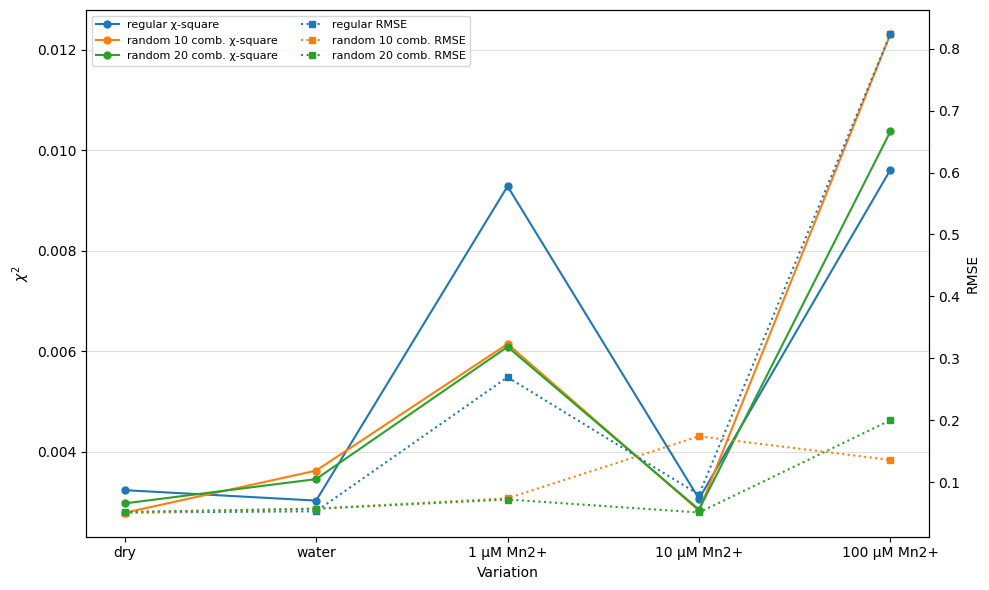

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
file_name = "a_recap.xlsx"
sheet_name = "single_rec (2)"

df = pd.read_excel(file_name, sheet_name=sheet_name)
df.columns = df.columns.str.strip()

print(df.columns.tolist())

# =========================
# DEFINE COLUMNS
# =========================
variation_col = "variations"

methods = {
    "regular": {
        "chi": "chi regular",
        "rmse": "RMSE regular"
    },
    "random 10 comb.": {
        "chi": "chi random 10 samples",
        "rmse": "RMSE random 10 samples"
    },
    "random 20 comb.": {
        "chi": "chi random 20 samples",
        "rmse": "RMSE random 20 samples"
    },
    # "bootstrap": {
    #     "chi": "chi bootstrap",
    #     "rmse": "RMSE bootstrap"
    # }
}

# =========================
# PREPARE X-AXIS
# =========================
# variations = df[variation_col].astype(str).values
variations = ["dry", "water", "1 μM Mn2+", "10 μM Mn2+", "100 μM Mn2+"]
x = np.arange(len(variations))

# =========================
# PLOT CHI-SQUARE AND RMSE
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Second y-axis for RMSE
ax2 = ax1.twinx()

# Plot chi-square on left y-axis
for label, cols in methods.items():
    chi = df[cols["chi"]].values

    ax1.plot(
        x,
        chi,
        marker="o",
        linestyle="-",
        linewidth=1.5,
        markersize=5,
        label=f"{label} χ-square"
    )

# Plot RMSE on right y-axis
for label, cols in methods.items():
    rmse = df[cols["rmse"]].values

    ax2.plot(
        x,
        rmse,
        marker="s",
        linestyle="dotted",
        linewidth=1.5,
        markersize=5,
        label=f"{label} RMSE"
    )

# =========================
# AXIS SETTINGS
# =========================
ax1.set_xticks(x)
ax1.set_xticklabels(variations)

ax1.set_xlabel("Variation")
ax1.set_ylabel(r"$\chi^2$")
ax2.set_ylabel("RMSE")

ax1.grid(True, axis="y", alpha=0.4)

# =========================
# COMBINE LEGENDS
# =========================
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    fontsize=8,
    ncol=2,
    loc="upper left"
)

plt.tight_layout()

# Save figure
plt.savefig("norm_red_chi_square_RMSE_single.png", dpi=300, bbox_inches="tight")

plt.show()

## Biexp

['variations', 'T1 long reg', 'std T1 long reg', 'T1 short', 'std T1 short', 'chi regular', 'RMSE regular', 'Mean T1 reg', 'Mean T1 long (random)', 'std', 'Short tau', 'std.1', 'chi random 10 samples', 'RMSE random 10 samples', 'Long tau rand2', 'std.2', 'Short tau rand2', 'Unnamed: 17', 'chi random 20 samples', 'RMSE random 20 samples', 'T1 long bootstrap', 'std T1 long bootstrap', 'T1 short bootstrap', 'std T1 short bootstrap', 'chi bootstrap', 'RMSE bootstrap']


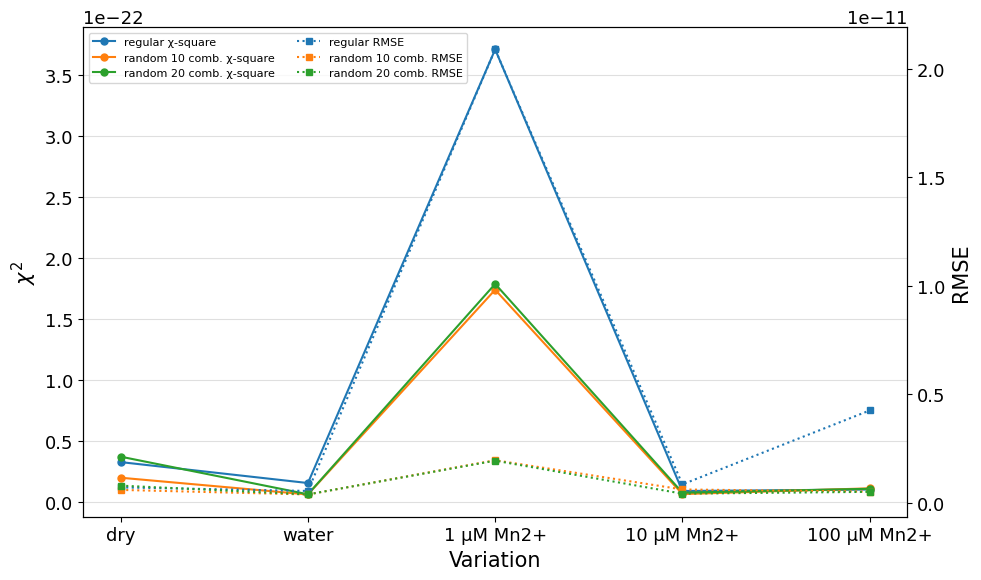

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
file_name = "a_recap.xlsx"
sheet_name = "biexp_rec (2)"

df = pd.read_excel(file_name, sheet_name=sheet_name)
df.columns = df.columns.str.strip()

print(df.columns.tolist())

# =========================
# DEFINE COLUMNS
# =========================
variation_col = "variations"

methods = {
    "regular": {
        "chi": "chi regular",
        "rmse": "RMSE regular"
    },
    "random 10 comb.": {
        "chi": "chi random 10 samples",
        "rmse": "RMSE random 10 samples"
    },
    "random 20 comb.": {
        "chi": "chi random 20 samples",
        "rmse": "RMSE random 20 samples"
    },
    # "bootstrap": {
    #     "chi": "chi bootstrap",
    #     "rmse": "RMSE bootstrap"
    # }
}

# =========================
# PREPARE X-AXIS
# =========================
# variations = df[variation_col].astype(str).values
variations = ["dry", "water", "1 μM Mn2+", "10 μM Mn2+", "100 μM Mn2+"]
x = np.arange(len(variations))

# =========================
# PLOT CHI-SQUARE AND RMSE
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Second y-axis for RMSE
ax2 = ax1.twinx()

# Plot chi-square on left y-axis
for label, cols in methods.items():
    chi = df[cols["chi"]].values

    ax1.plot(
        x,
        chi,
        marker="o",
        linestyle="-",
        linewidth=1.5,
        markersize=5,
        label=f"{label} χ-square"
    )

# Plot RMSE on right y-axis
for label, cols in methods.items():
    rmse = df[cols["rmse"]].values

    ax2.plot(
        x,
        rmse,
        marker="s",
        linestyle="dotted",
        linewidth=1.5,
        markersize=5,
        label=f"{label} RMSE"
    )

# =========================
# AXIS SETTINGS
# =========================
ax1.set_xticks(x)
ax1.set_xticklabels(variations)

ax1.set_xlabel("Variation")
ax1.set_ylabel(r"$\chi^2$")
ax2.set_ylabel("RMSE")

ax1.grid(True, axis="y", alpha=0.4)

# =========================
# COMBINE LEGENDS
# =========================
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    fontsize=8,
    ncol=2,
    loc="upper left"
)

plt.tight_layout()

# Save figure
plt.savefig("chi_square_RMSE_biexp2.png", dpi=300, bbox_inches="tight")

plt.show()

## Separate

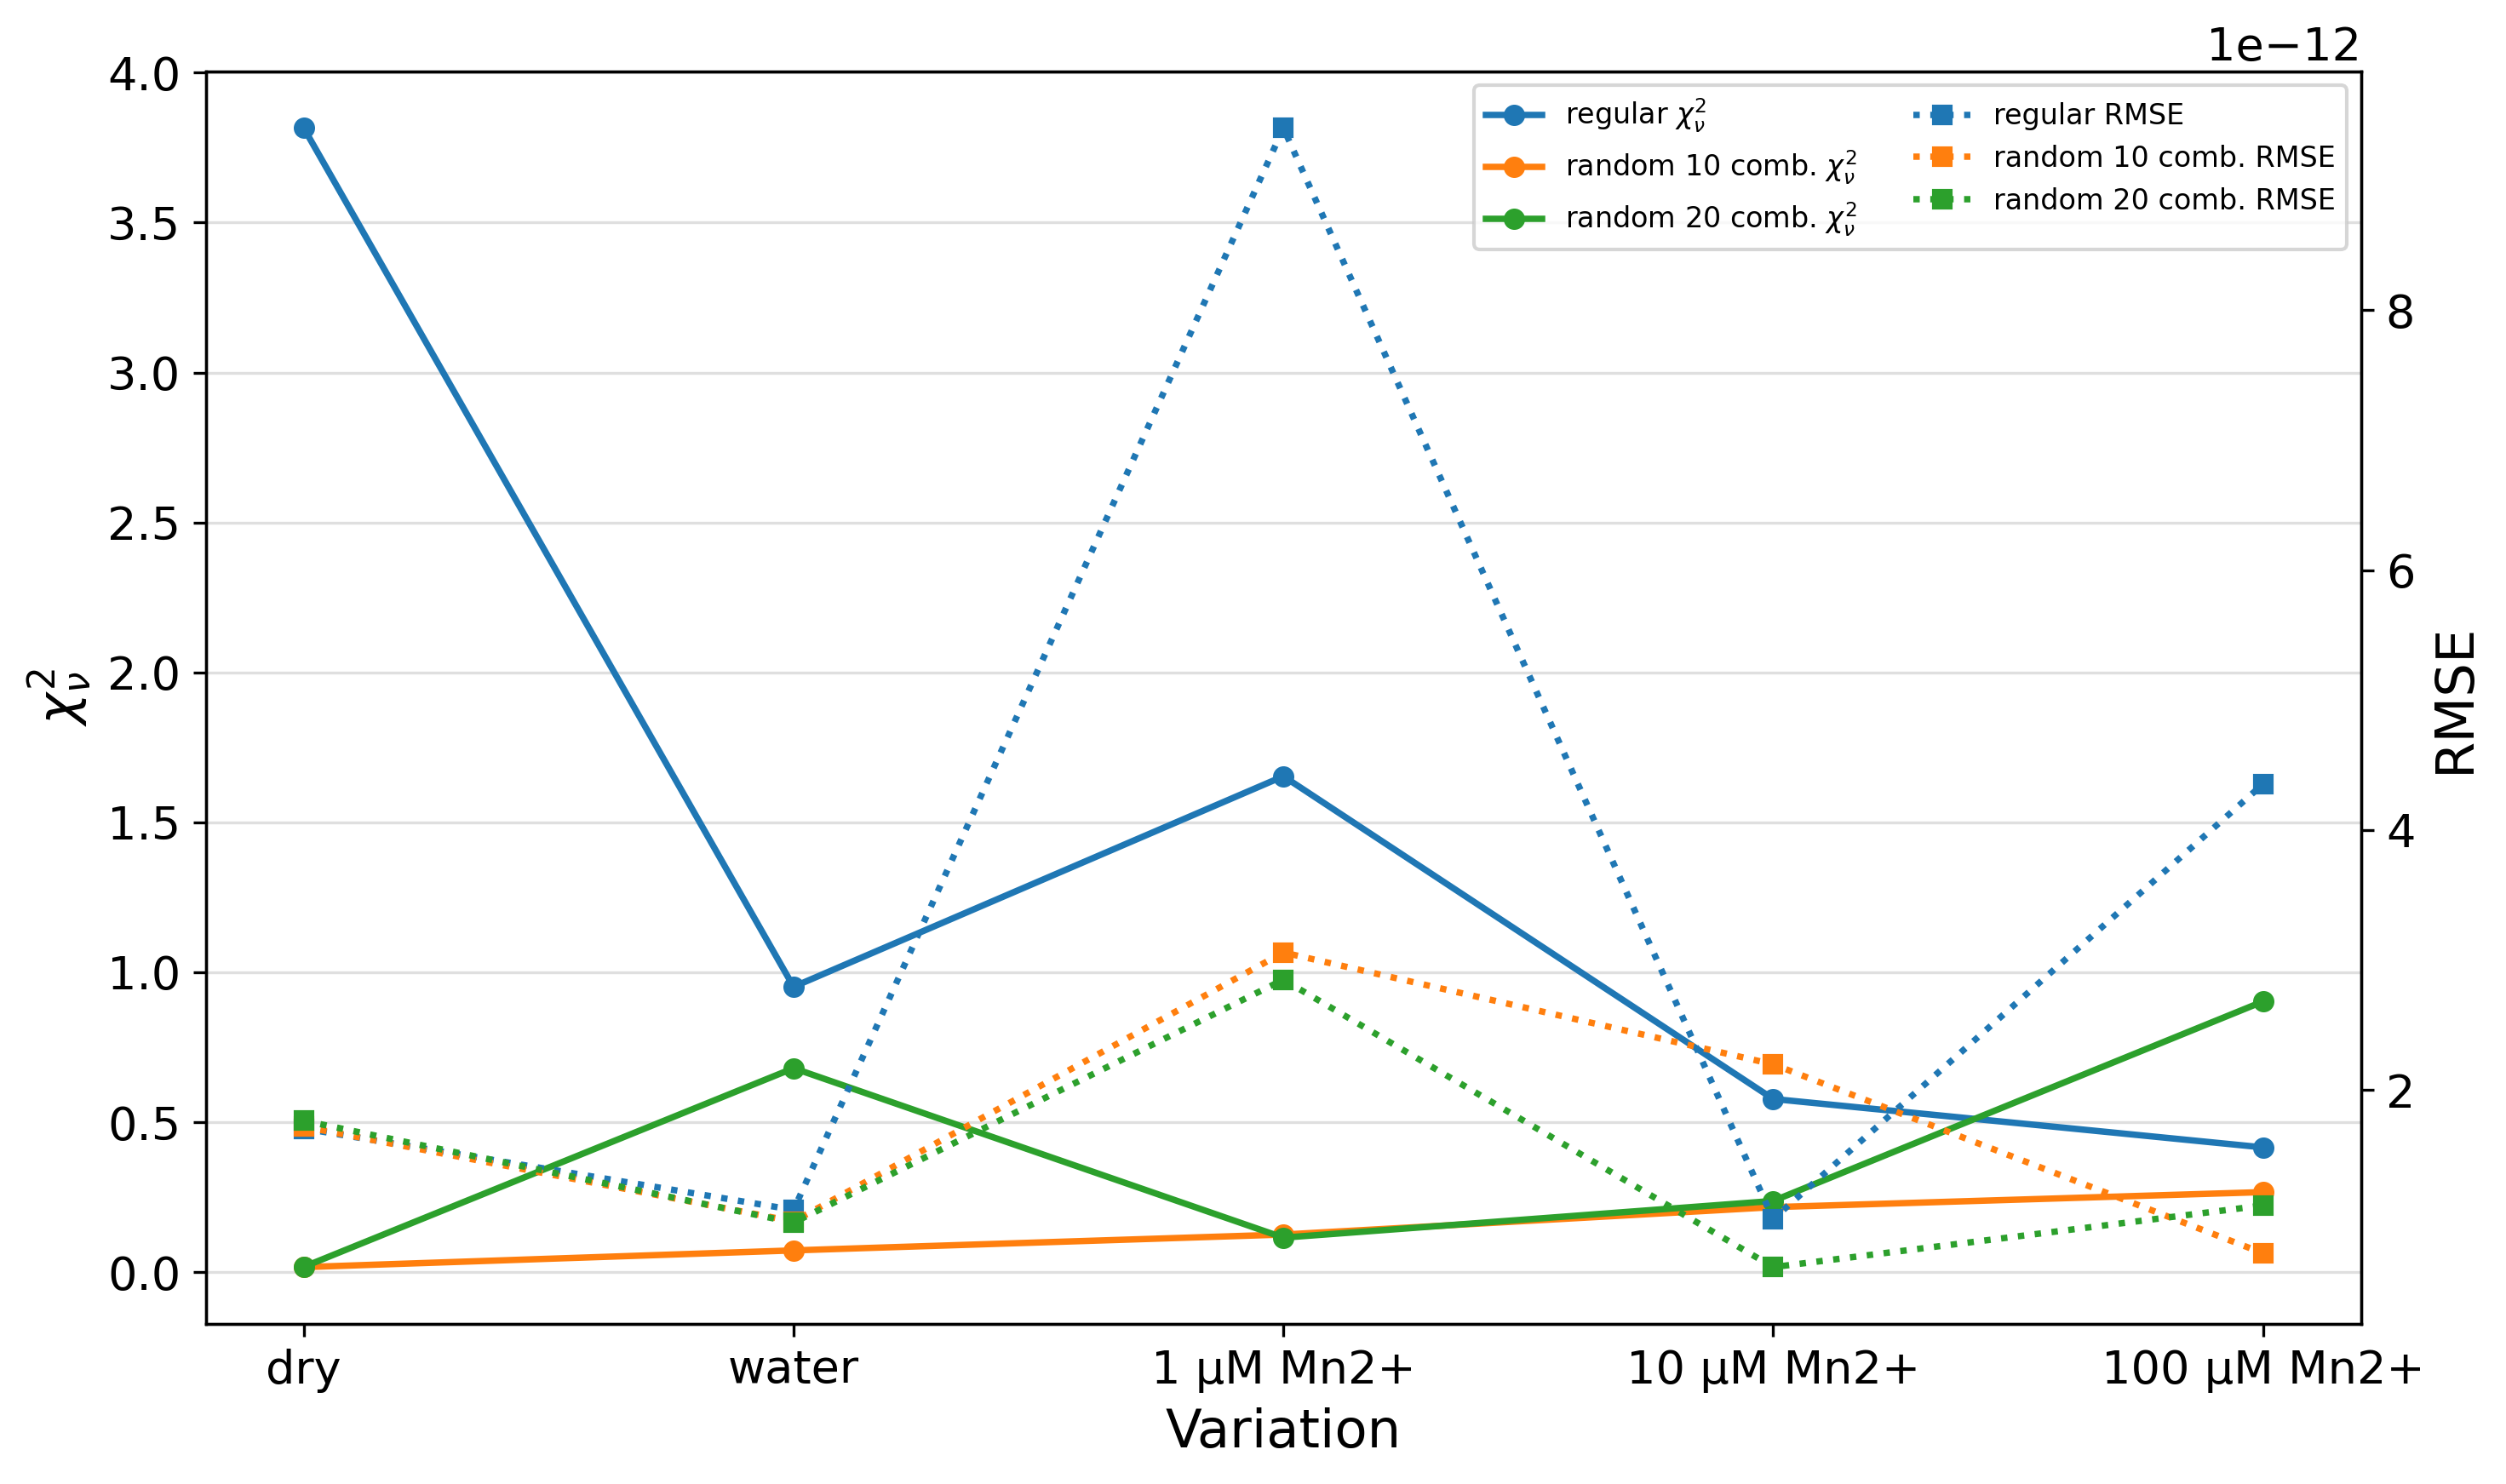

Saved: red_chi_square_RMSE_single_from_two_files.png


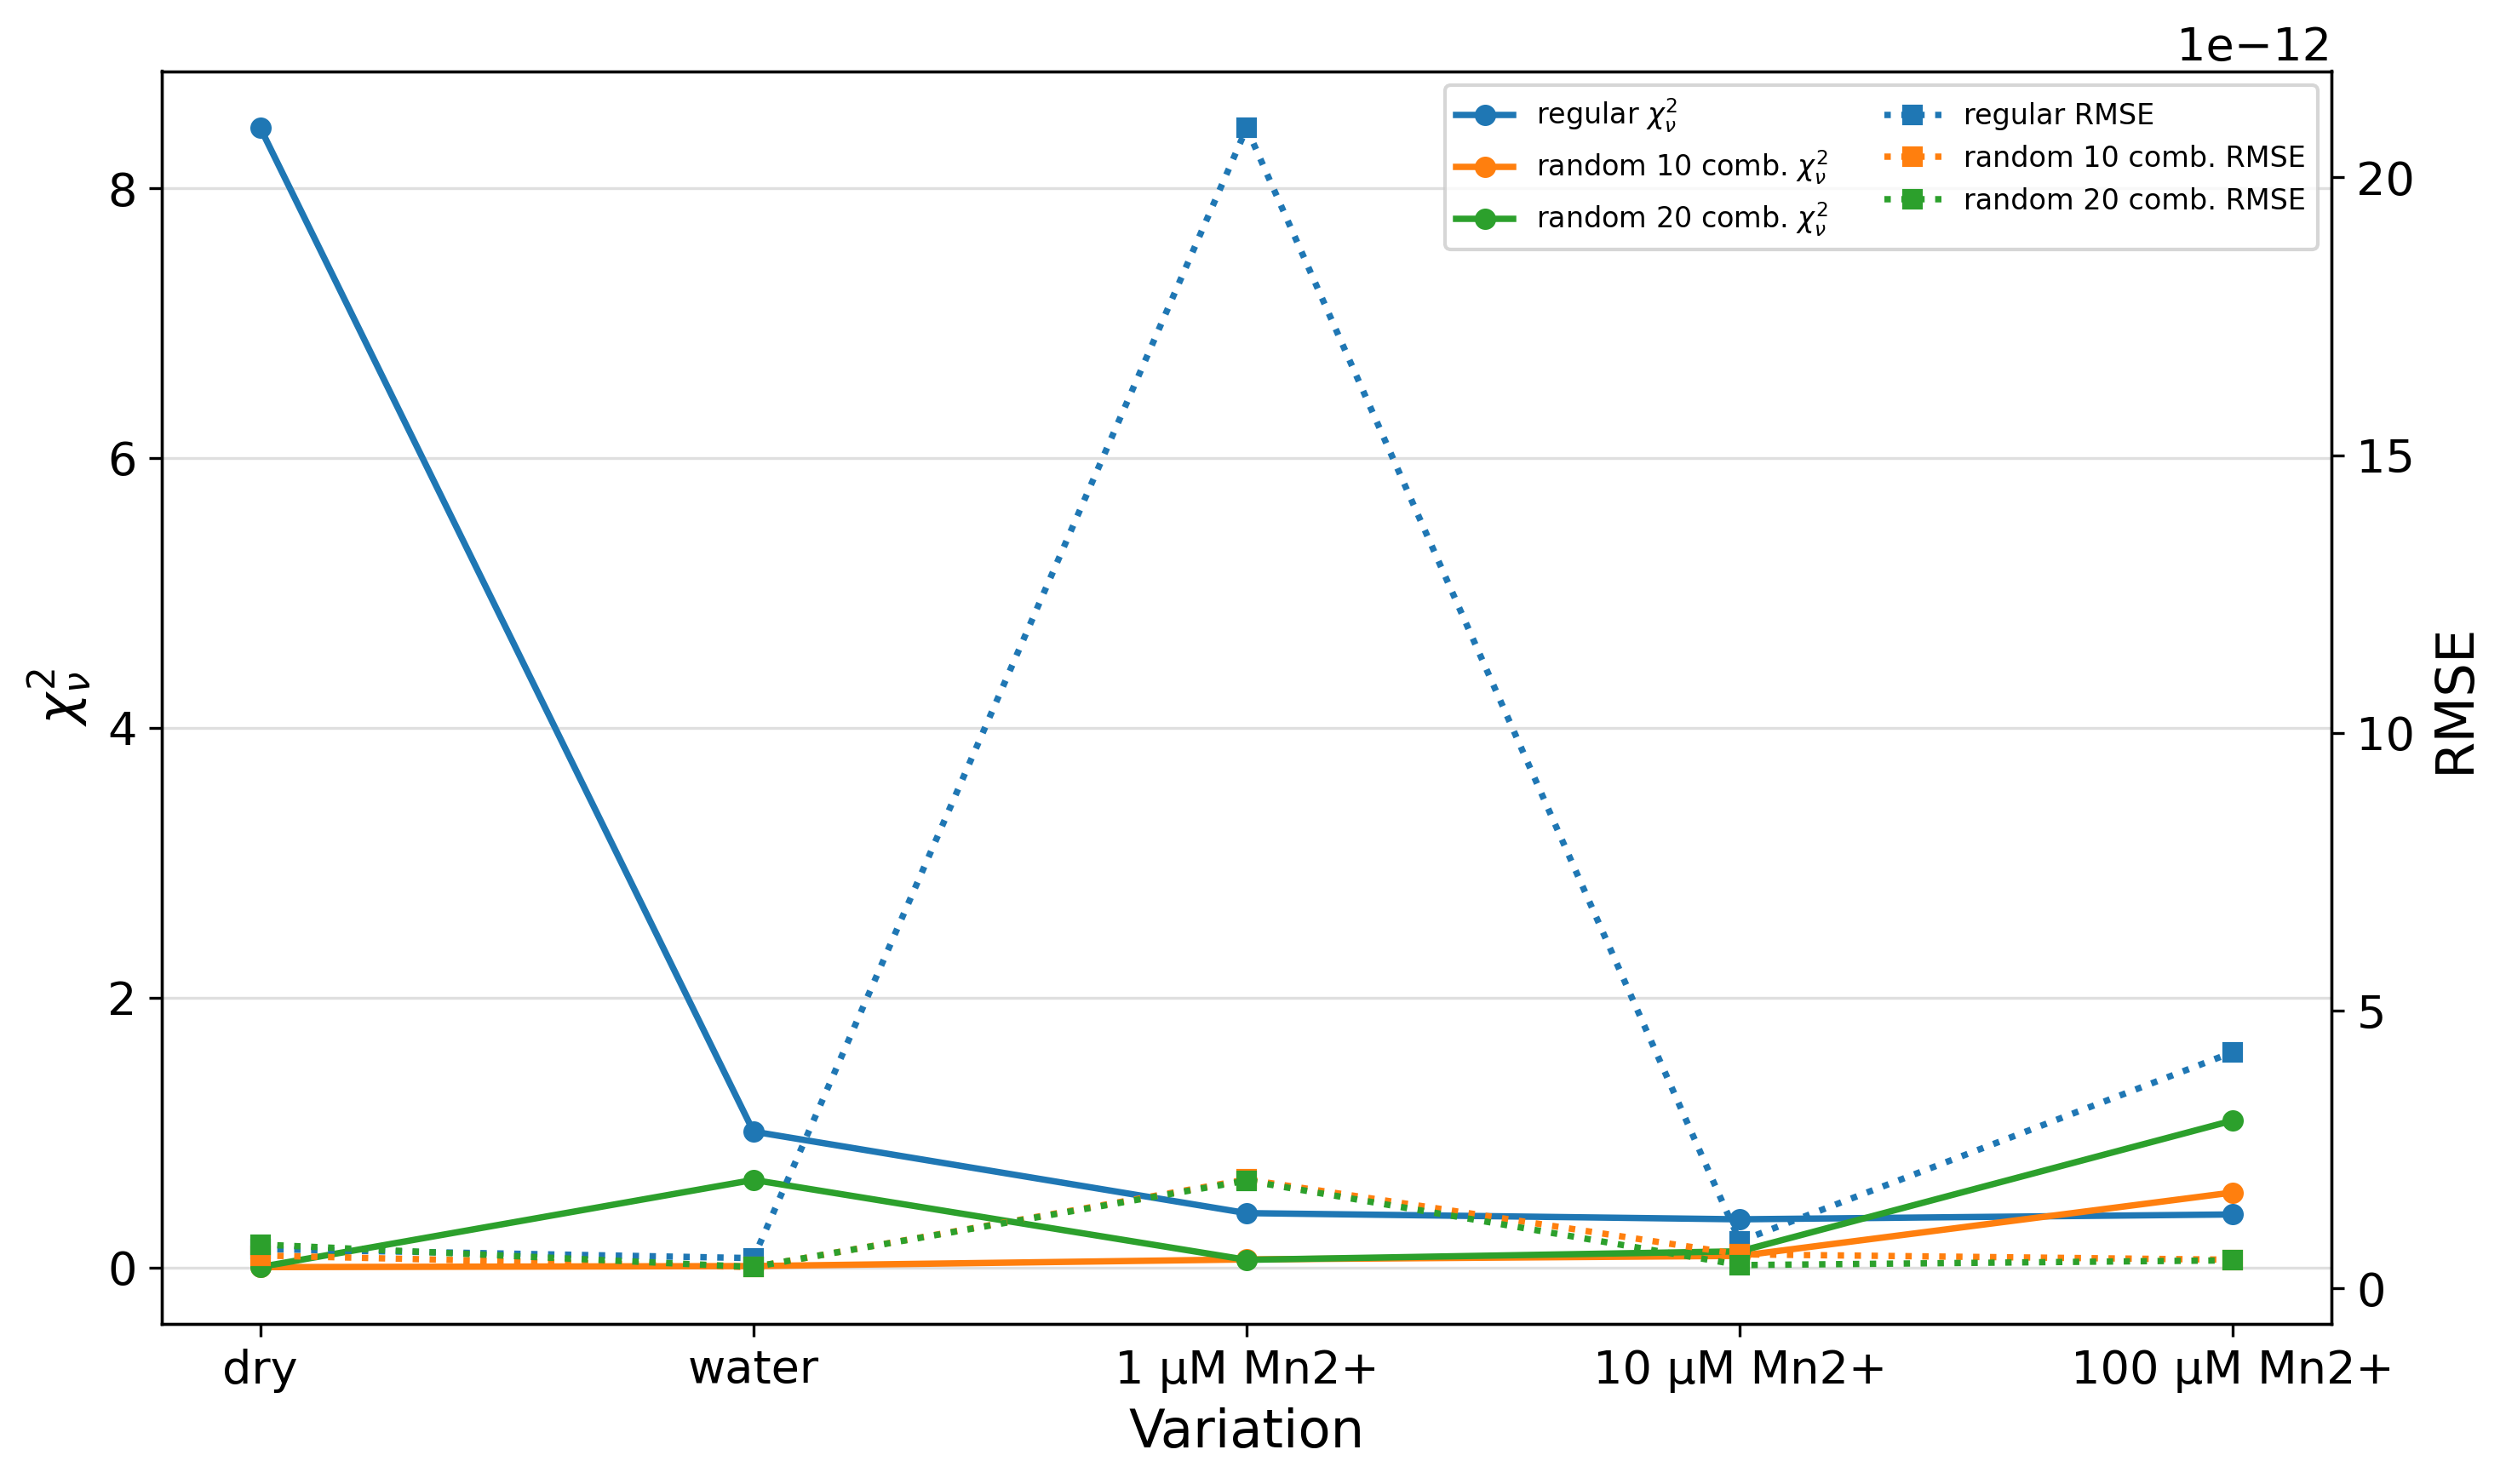

Saved: red_chi_square_RMSE_bi_from_two_files.png


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# USER SETTINGS
# =========================
rmse_file = "a_recap.xlsx"
chi_file = "chi_square_output/average_reduced_chi_square.xlsx"

rmse_sheets = {
    "single": "single_rec (2)",
    "bi": "biexp_rec (3)",
}

chi_sheet_candidates = ["by_variation_method"]

variation_order = ["dry", "water", "1um", "10um", "100um"]
variation_labels = [
    "dry",
    "water",
    "1 μM Mn2+",
    "10 μM Mn2+",
    "100 μM Mn2+",
]

methods_rmse = {
    "regular": "RMSE regular",
    "random10": "RMSE random 10 samples",
    "random20": "RMSE random 20 samples",
}

methods_label = {
    "regular": "regular",
    "random10": "random 10 comb.",
    "random20": "random 20 comb.",
}

colors = {
    "regular": "tab:blue",
    "random10": "tab:orange",
    "random20": "tab:green",
}

output_names = {
    "single": "red_chi_square_RMSE_single_from_two_files.png",
    "bi": "red_chi_square_RMSE_bi_from_two_files.png",
}

# =========================
# LOAD CHI-SQUARE DATA
# =========================
chi_excel = pd.ExcelFile(chi_file)

chi_sheet = None
for candidate in chi_sheet_candidates:
    if candidate in chi_excel.sheet_names:
        chi_sheet = candidate
        break

if chi_sheet is None:
    raise ValueError(
        f"No chi-square sheet found. Available sheets: {chi_excel.sheet_names}"
    )

df_chi = pd.read_excel(chi_file, sheet_name=chi_sheet)
df_chi.columns = df_chi.columns.str.strip()

df_chi["variation"] = df_chi["variation"].astype(str).str.strip()
df_chi["sampling_method"] = df_chi["sampling_method"].astype(str).str.strip()
df_chi["fitting_model"] = df_chi["fitting_model"].astype(str).str.strip()

df_chi["mean_reduced_chi_square"] = pd.to_numeric(
    df_chi["mean_reduced_chi_square"],
    errors="coerce"
)

# =========================
# PLOT FUNCTION
# =========================
def plot_model(model):
    # Load RMSE from a_recap
    df_rmse = pd.read_excel(rmse_file, sheet_name=rmse_sheets[model])
    df_rmse.columns = df_rmse.columns.str.strip()

    # Filter chi-square for selected model
    df_chi_model = df_chi[df_chi["fitting_model"] == model].copy()

    x = np.arange(len(variation_order))

    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
    ax2 = ax1.twinx()

    # =========================
    # PLOT REDUCED CHI-SQUARE
    # =========================
    for method in ["regular", "random10", "random20"]:
        chi_subset = (
            df_chi_model[df_chi_model["sampling_method"] == method]
            .set_index("variation")
            .reindex(variation_order)
        )

        ax1.plot(
            x,
            chi_subset["mean_reduced_chi_square"].values,
            color=colors[method],
            marker="o",
            linestyle="-",
            linewidth=1.8,
            markersize=5,
            label=rf"{methods_label[method]} $\chi_\nu^2$",
        )

    # =========================
    # PLOT RMSE
    # =========================
    for method in ["regular", "random10", "random20"]:
        rmse = pd.to_numeric(
            df_rmse[methods_rmse[method]],
            errors="coerce"
        ).values

        ax2.plot(
            x,
            rmse,
            color=colors[method],
            marker="s",
            linestyle=":",
            linewidth=1.8,
            markersize=5,
            label=f"{methods_label[method]} RMSE",
        )

    # =========================
    # AXIS SETTINGS
    # =========================
    ax1.set_xticks(x)
    ax1.set_xticklabels(variation_labels)

    ax1.set_xlabel("Variation")
    ax1.set_ylabel(r"$\chi_\nu^2$")
    ax2.set_ylabel("RMSE")

    # Force RMSE axis scientific notation to show 1e-12
    formatter = ticker.ScalarFormatter(useMathText=False)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-12, -12))
    ax2.yaxis.set_major_formatter(formatter)
    ax2.ticklabel_format(axis="y", style="sci", scilimits=(-12, -12))

    ax1.grid(True, axis="y", alpha=0.4)

    # =========================
    # LEGEND
    # =========================
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        fontsize=8,
        ncol=2,
        loc="upper right",
    )

    plt.tight_layout()

    plt.savefig(output_names[model], dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_names[model]}")

# =========================
# CREATE PLOTS
# =========================
plot_model("single")
plot_model("bi")

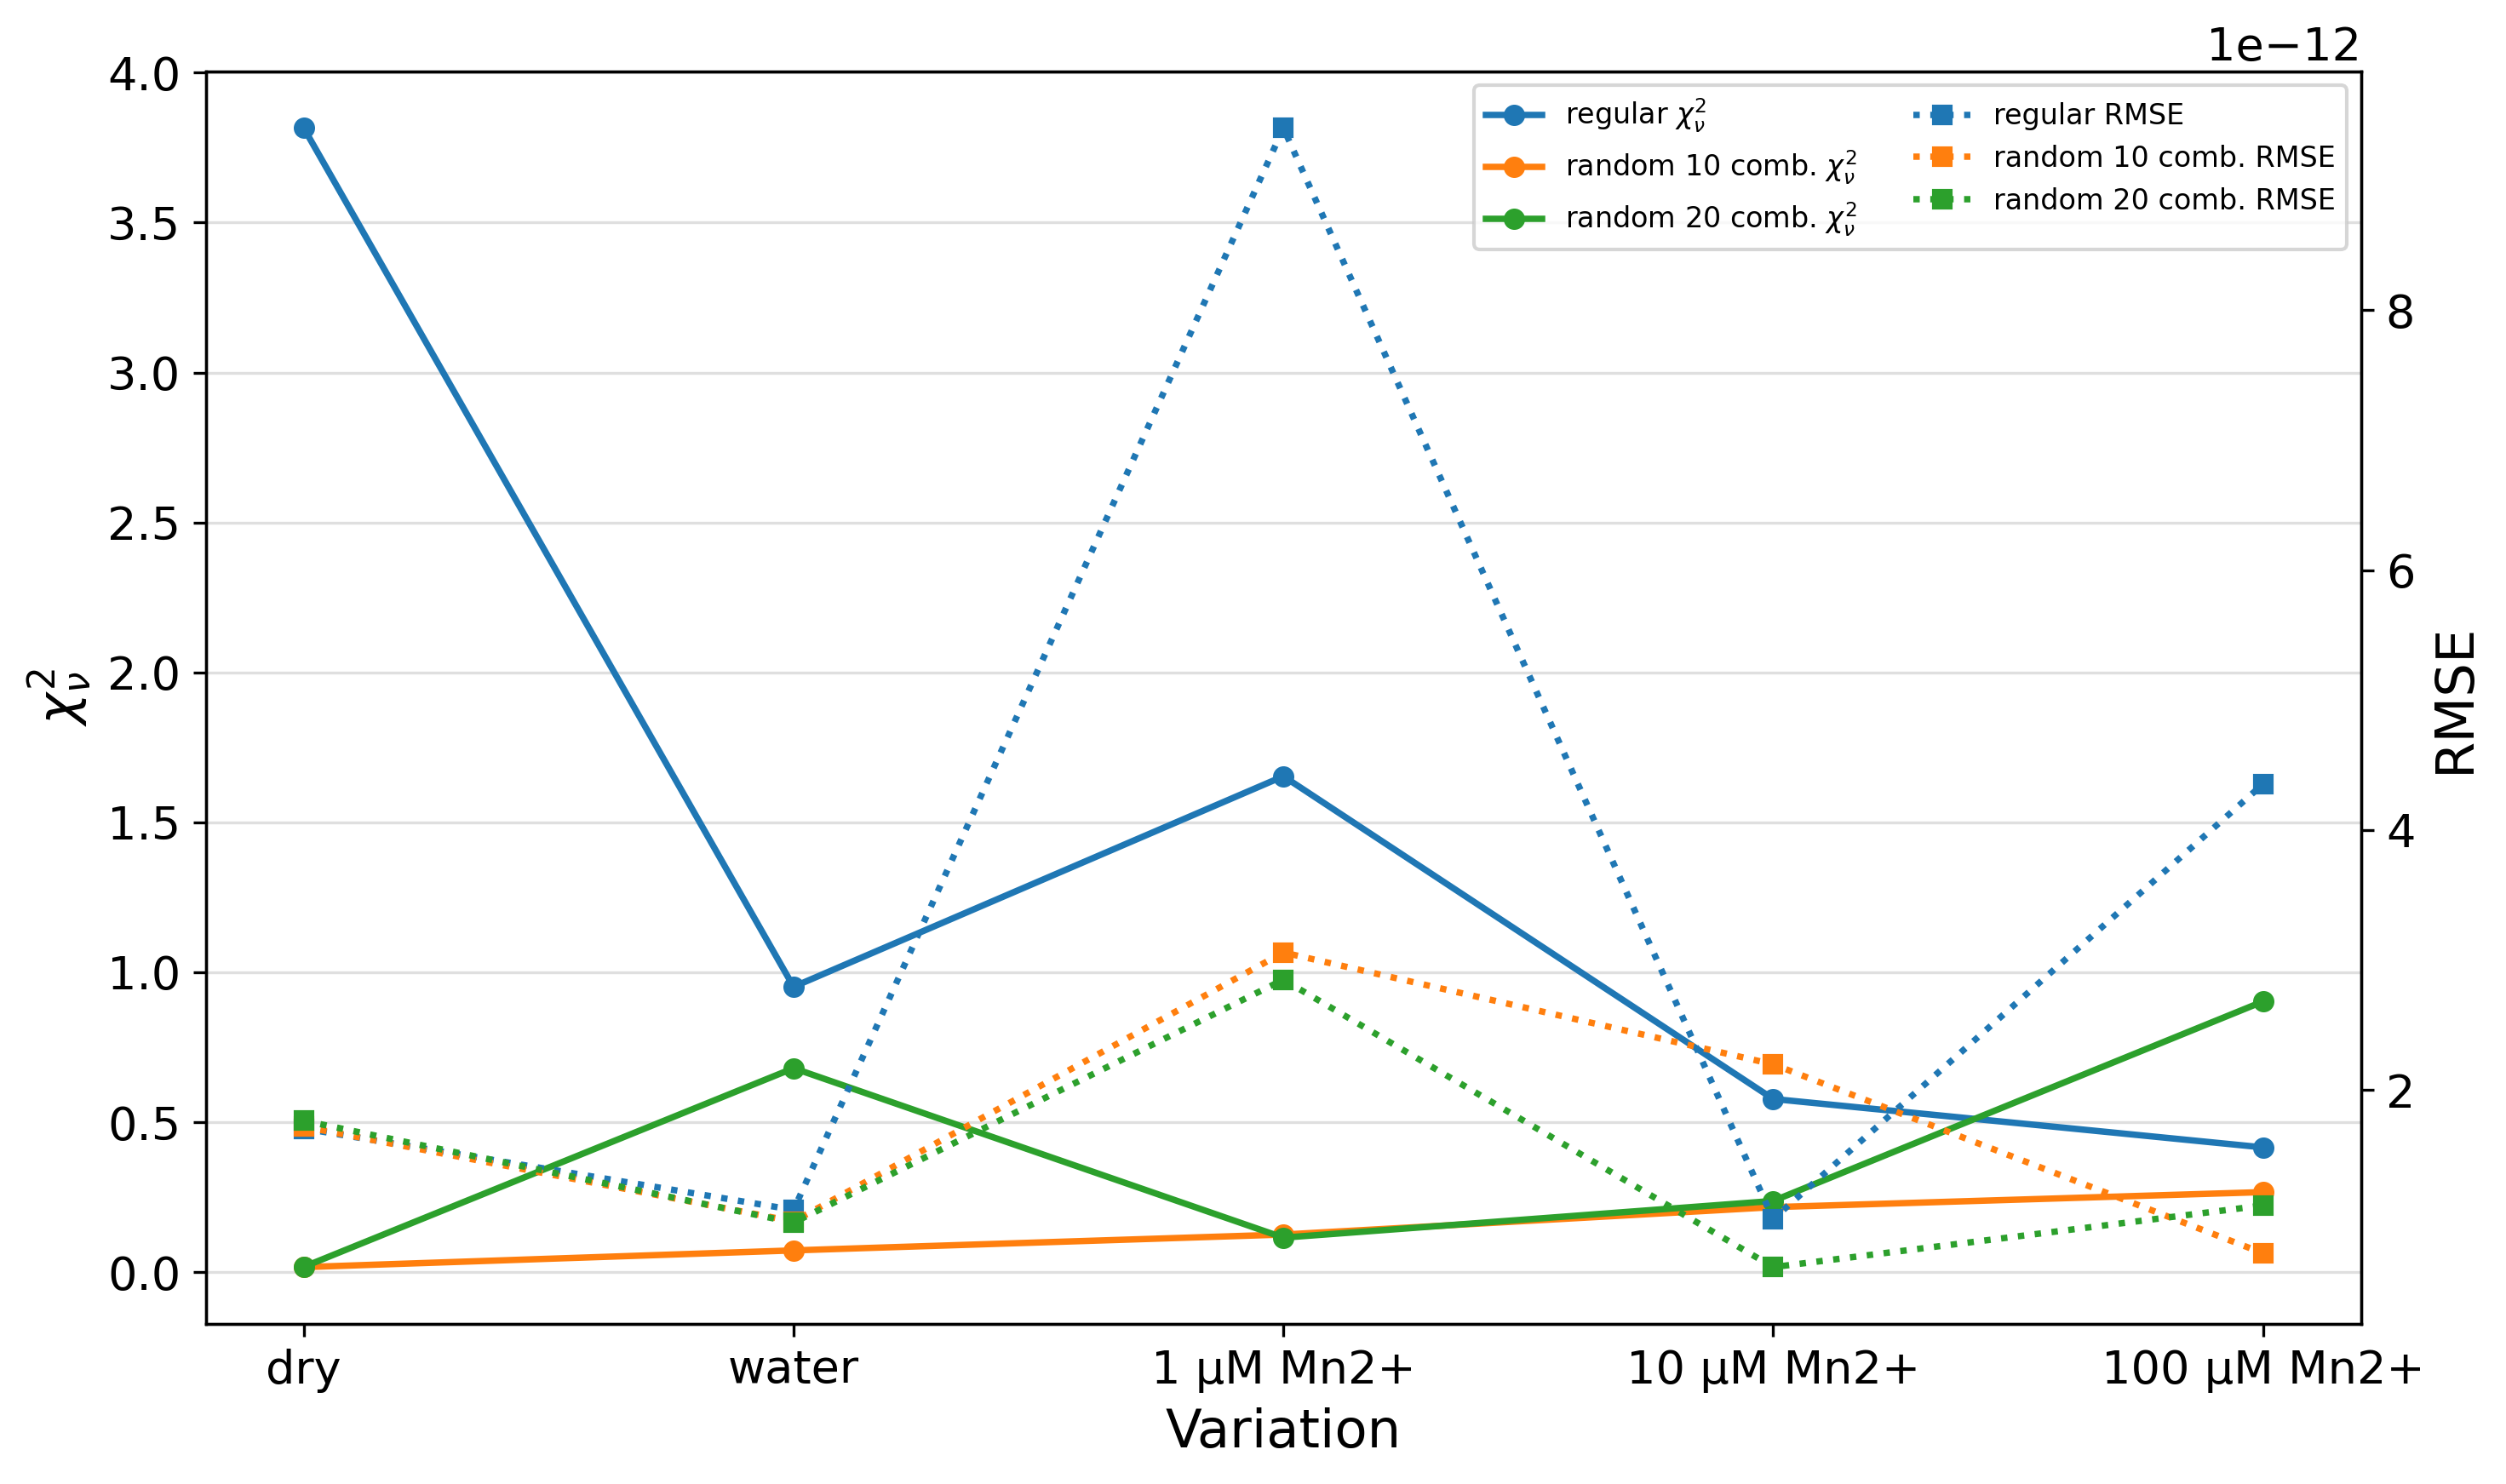

Saved: 1_red_chi_square_RMSE_single_from_two_files.png


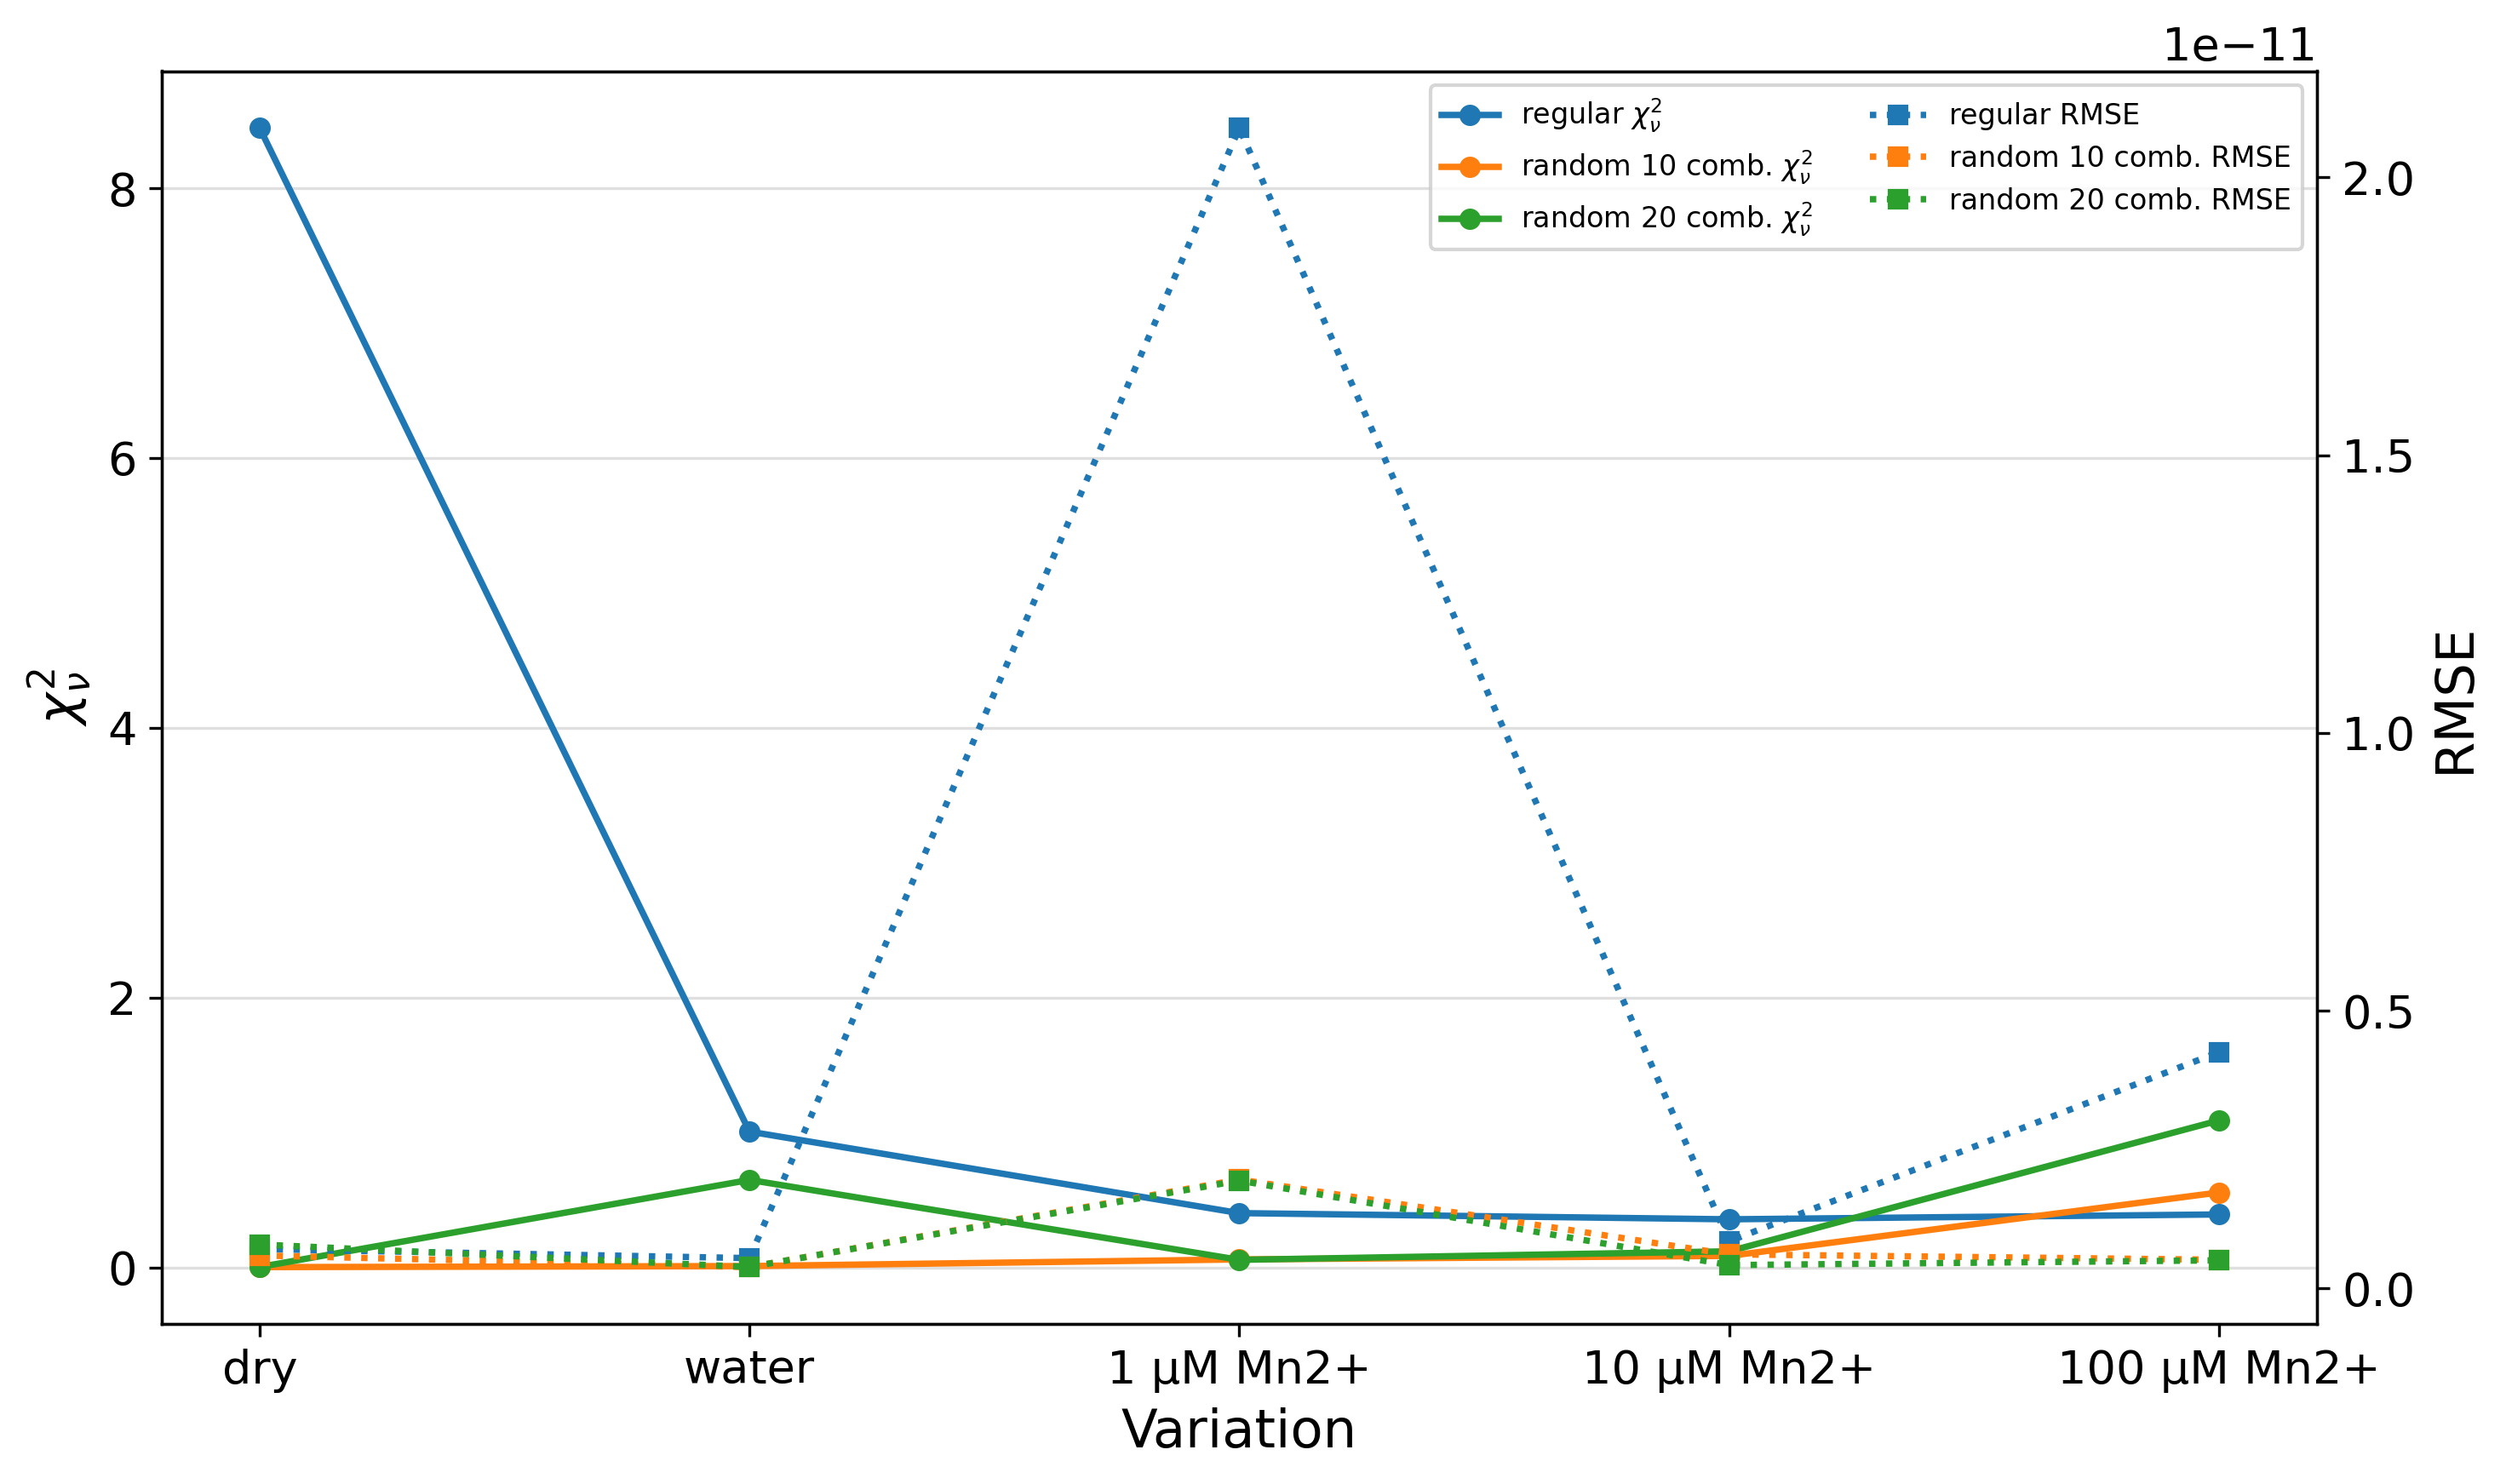

Saved: 1_red_chi_square_RMSE_bi_from_two_files.png


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
rmse_file = "a_recap.xlsx"
chi_file = "chi_square_output/average_reduced_chi_square.xlsx"

# Change these if your exact sheet names are different
rmse_sheets = {
    "single": "single_rec (2)",   # or "single_exp (2)"
    "bi": "biexp_rec (3)",        # or "biexp_rec (2)"
}

chi_sheet_candidates = ["by_variation_method"]

variation_order = ["dry", "water", "1um", "10um", "100um"]
variation_labels = [
    "dry",
    "water",
    "1 μM Mn2+",
    "10 μM Mn2+",
    "100 μM Mn2+",
]

methods_rmse = {
    "regular": "RMSE regular",
    "random10": "RMSE random 10 samples",
    "random20": "RMSE random 20 samples",
}

methods_label = {
    "regular": "regular",
    "random10": "random 10 comb.",
    "random20": "random 20 comb.",
}

colors = {
    "regular": "tab:blue",
    "random10": "tab:orange",
    "random20": "tab:green",
}

model_titles = {
    "single": "single-exponential",
    "bi": "bi-exponential",
}

output_names = {
    "single": "1_red_chi_square_RMSE_single_from_two_files.png",
    "bi": "1_red_chi_square_RMSE_bi_from_two_files.png",
}

# =========================
# LOAD CHI-SQUARE DATA
# =========================
chi_excel = pd.ExcelFile(chi_file)

chi_sheet = None
for candidate in chi_sheet_candidates:
    if candidate in chi_excel.sheet_names:
        chi_sheet = candidate
        break

if chi_sheet is None:
    raise ValueError(f"No chi-square sheet found. Available sheets: {chi_excel.sheet_names}")

df_chi = pd.read_excel(chi_file, sheet_name=chi_sheet)
df_chi.columns = df_chi.columns.str.strip()

df_chi["variation"] = df_chi["variation"].astype(str).str.strip()
df_chi["sampling_method"] = df_chi["sampling_method"].astype(str).str.strip()
df_chi["fitting_model"] = df_chi["fitting_model"].astype(str).str.strip()
df_chi["mean_reduced_chi_square"] = pd.to_numeric(
    df_chi["mean_reduced_chi_square"],
    errors="coerce"
)

# =========================
# PLOT FUNCTION
# =========================
def plot_model(model):
    # Load RMSE from a_recap
    df_rmse = pd.read_excel(rmse_file, sheet_name=rmse_sheets[model])
    df_rmse.columns = df_rmse.columns.str.strip()

    # Filter chi-square for selected model
    df_chi_model = df_chi[df_chi["fitting_model"] == model].copy()

    x = np.arange(len(variation_order))

    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
    ax2 = ax1.twinx()

    # =========================
    # PLOT REDUCED CHI-SQUARE
    # =========================
    for method in ["regular", "random10", "random20"]:
        chi_subset = (
            df_chi_model[df_chi_model["sampling_method"] == method]
            .set_index("variation")
            .reindex(variation_order)
        )

        ax1.plot(
            x,
            chi_subset["mean_reduced_chi_square"].values,
            color=colors[method],
            marker="o",
            linestyle="-",
            linewidth=1.8,
            markersize=5,
            label=rf"{methods_label[method]} $\chi_\nu^2$",
        )

    # =========================
    # PLOT RMSE
    # =========================
    for method in ["regular", "random10", "random20"]:
        rmse = pd.to_numeric(df_rmse[methods_rmse[method]], errors="coerce").values

        ax2.plot(
            x,
            rmse,
            color=colors[method],
            marker="s",
            linestyle=":",
            linewidth=1.8,
            markersize=5,
            label=f"{methods_label[method]} RMSE",
        )

    # =========================
    # AXIS SETTINGS
    # =========================
    ax1.set_xticks(x)
    ax1.set_xticklabels(variation_labels)

    ax1.set_xlabel("Variation")
    ax1.set_ylabel(r"$\chi_\nu^2$")
    ax2.set_ylabel("RMSE")

    ax1.grid(True, axis="y", alpha=0.4)

    # =========================
    # LEGEND
    # =========================
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        fontsize=8,
        ncol=2,
        loc="upper right",
    )

    # plt.title(f"Reduced chi-square and RMSE ({model_titles[model]})")
    plt.tight_layout()

    plt.savefig(output_names[model], dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_names[model]}")

# =========================
# CREATE PLOTS
# =========================
plot_model("single")
plot_model("bi") 

## Separate (by models)

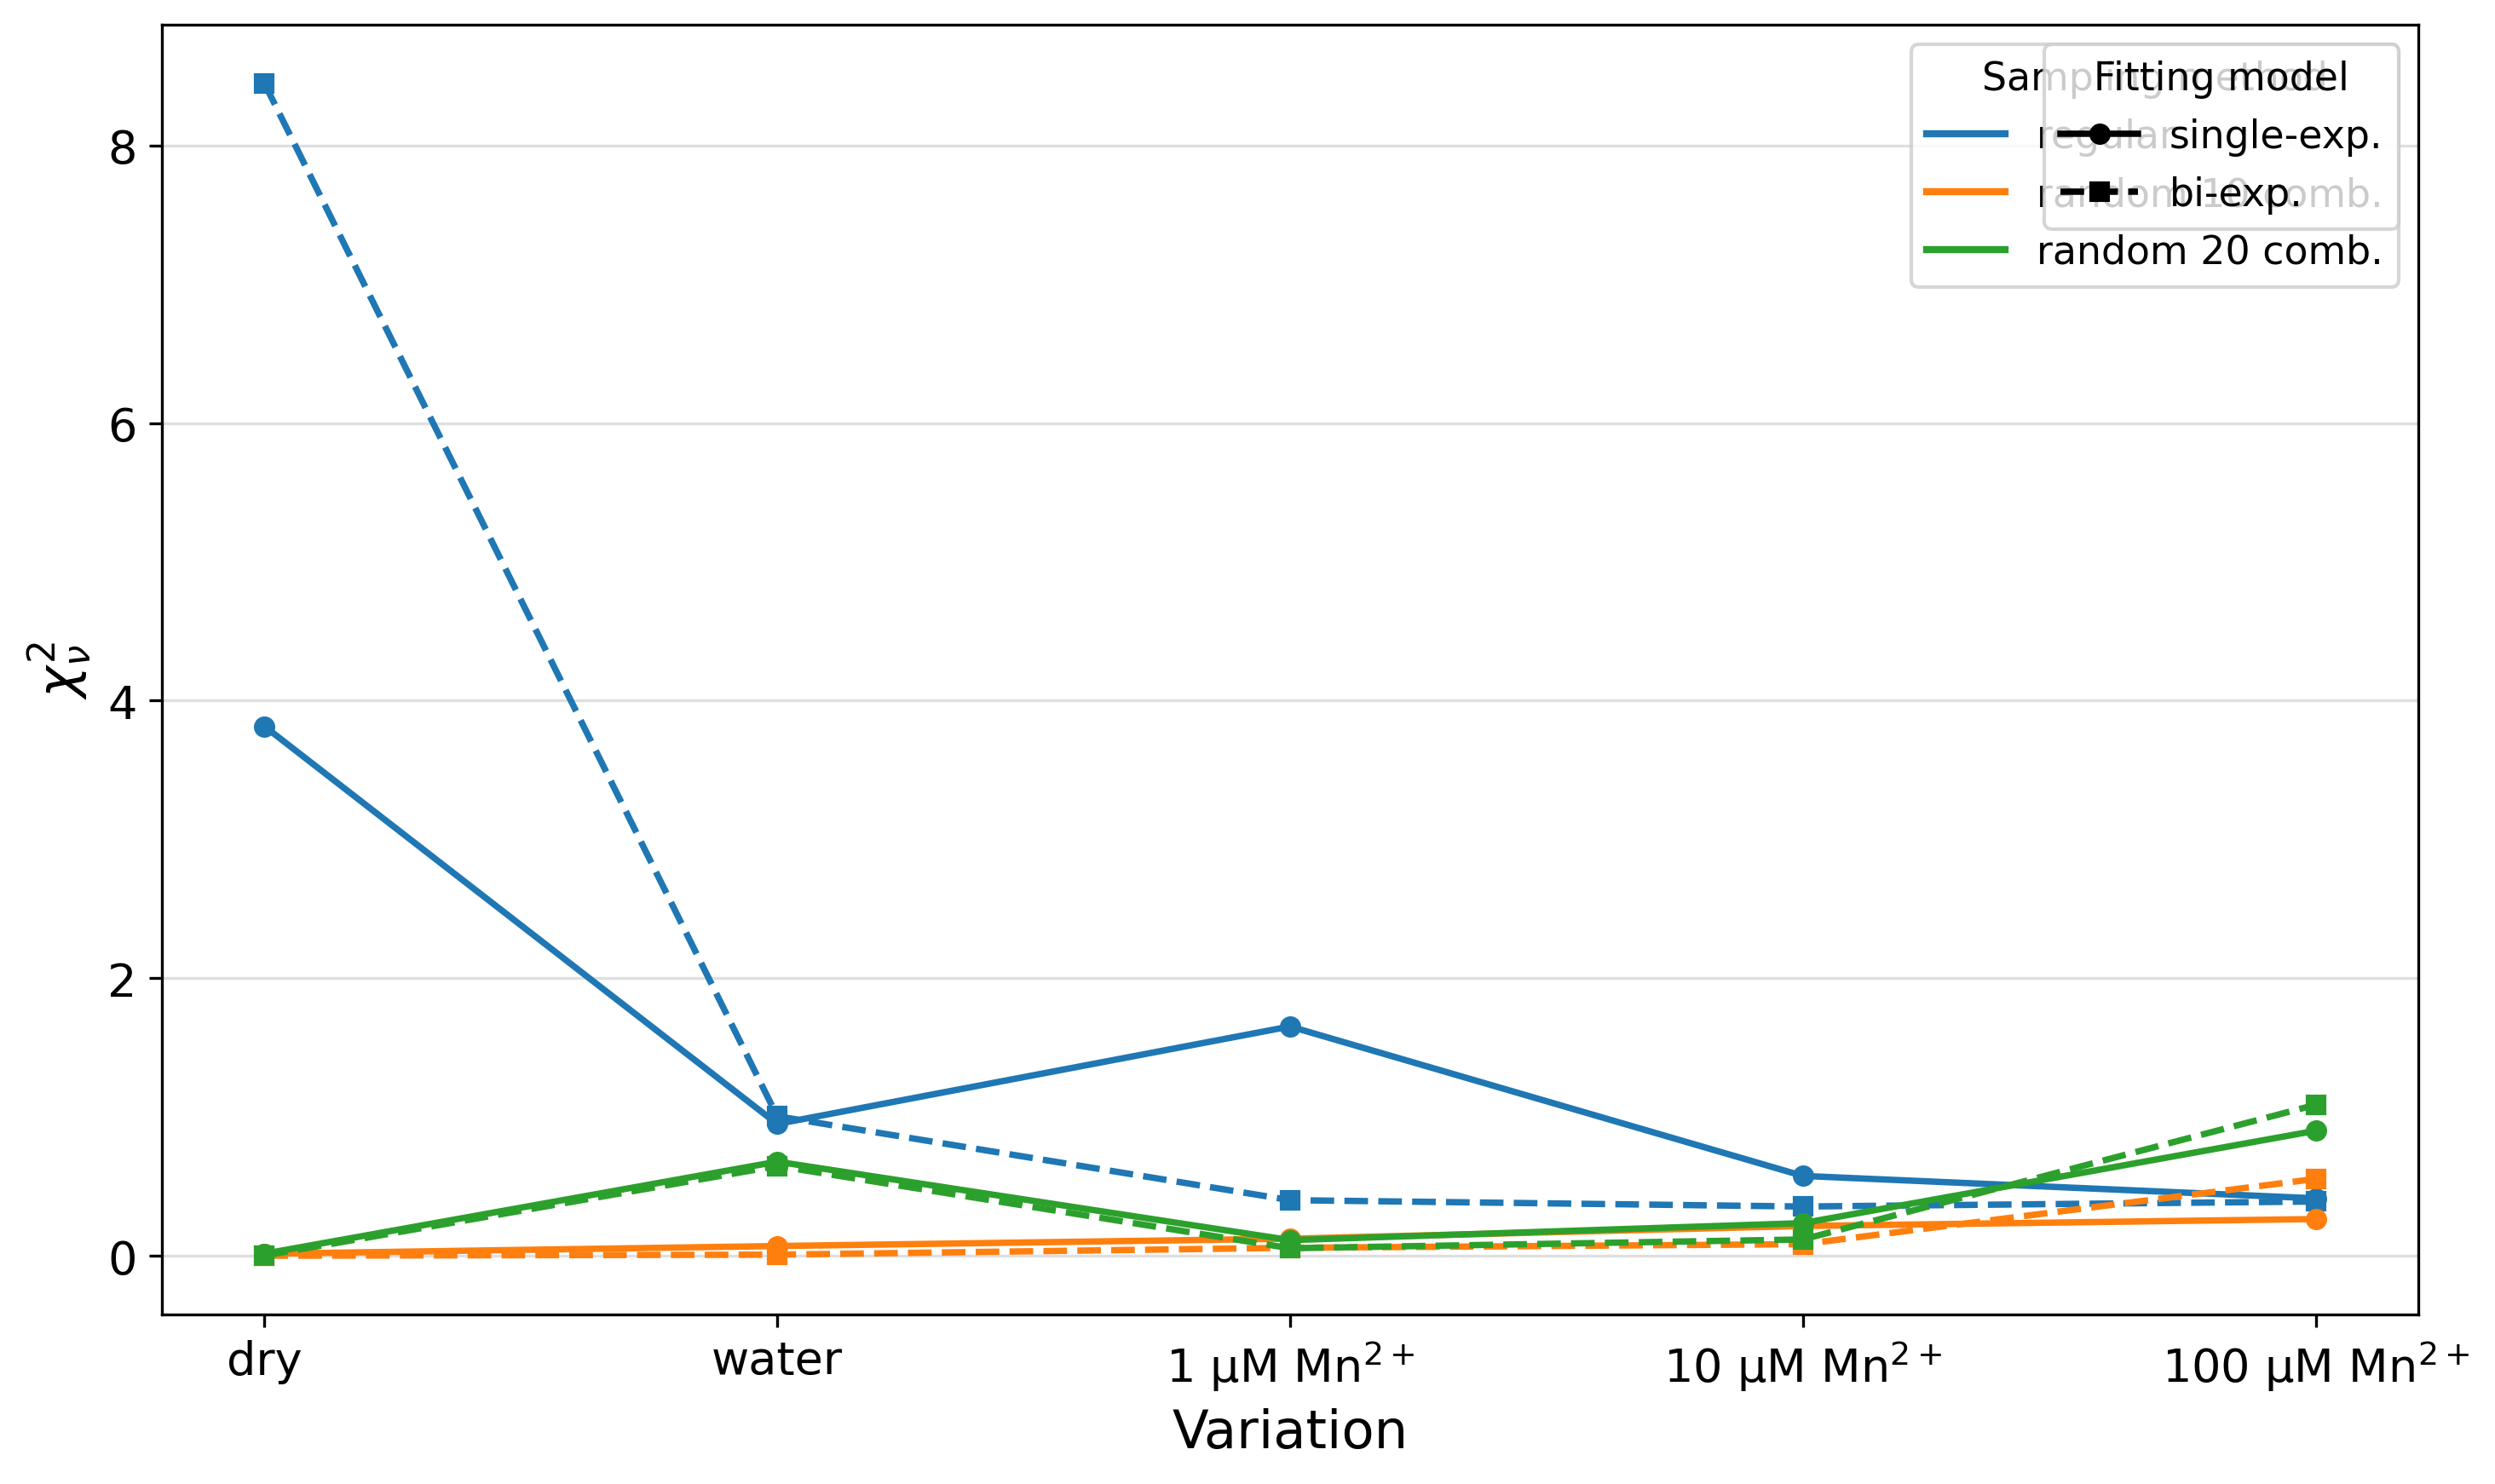

Saved: reduced_chi_square_single_vs_bi.png


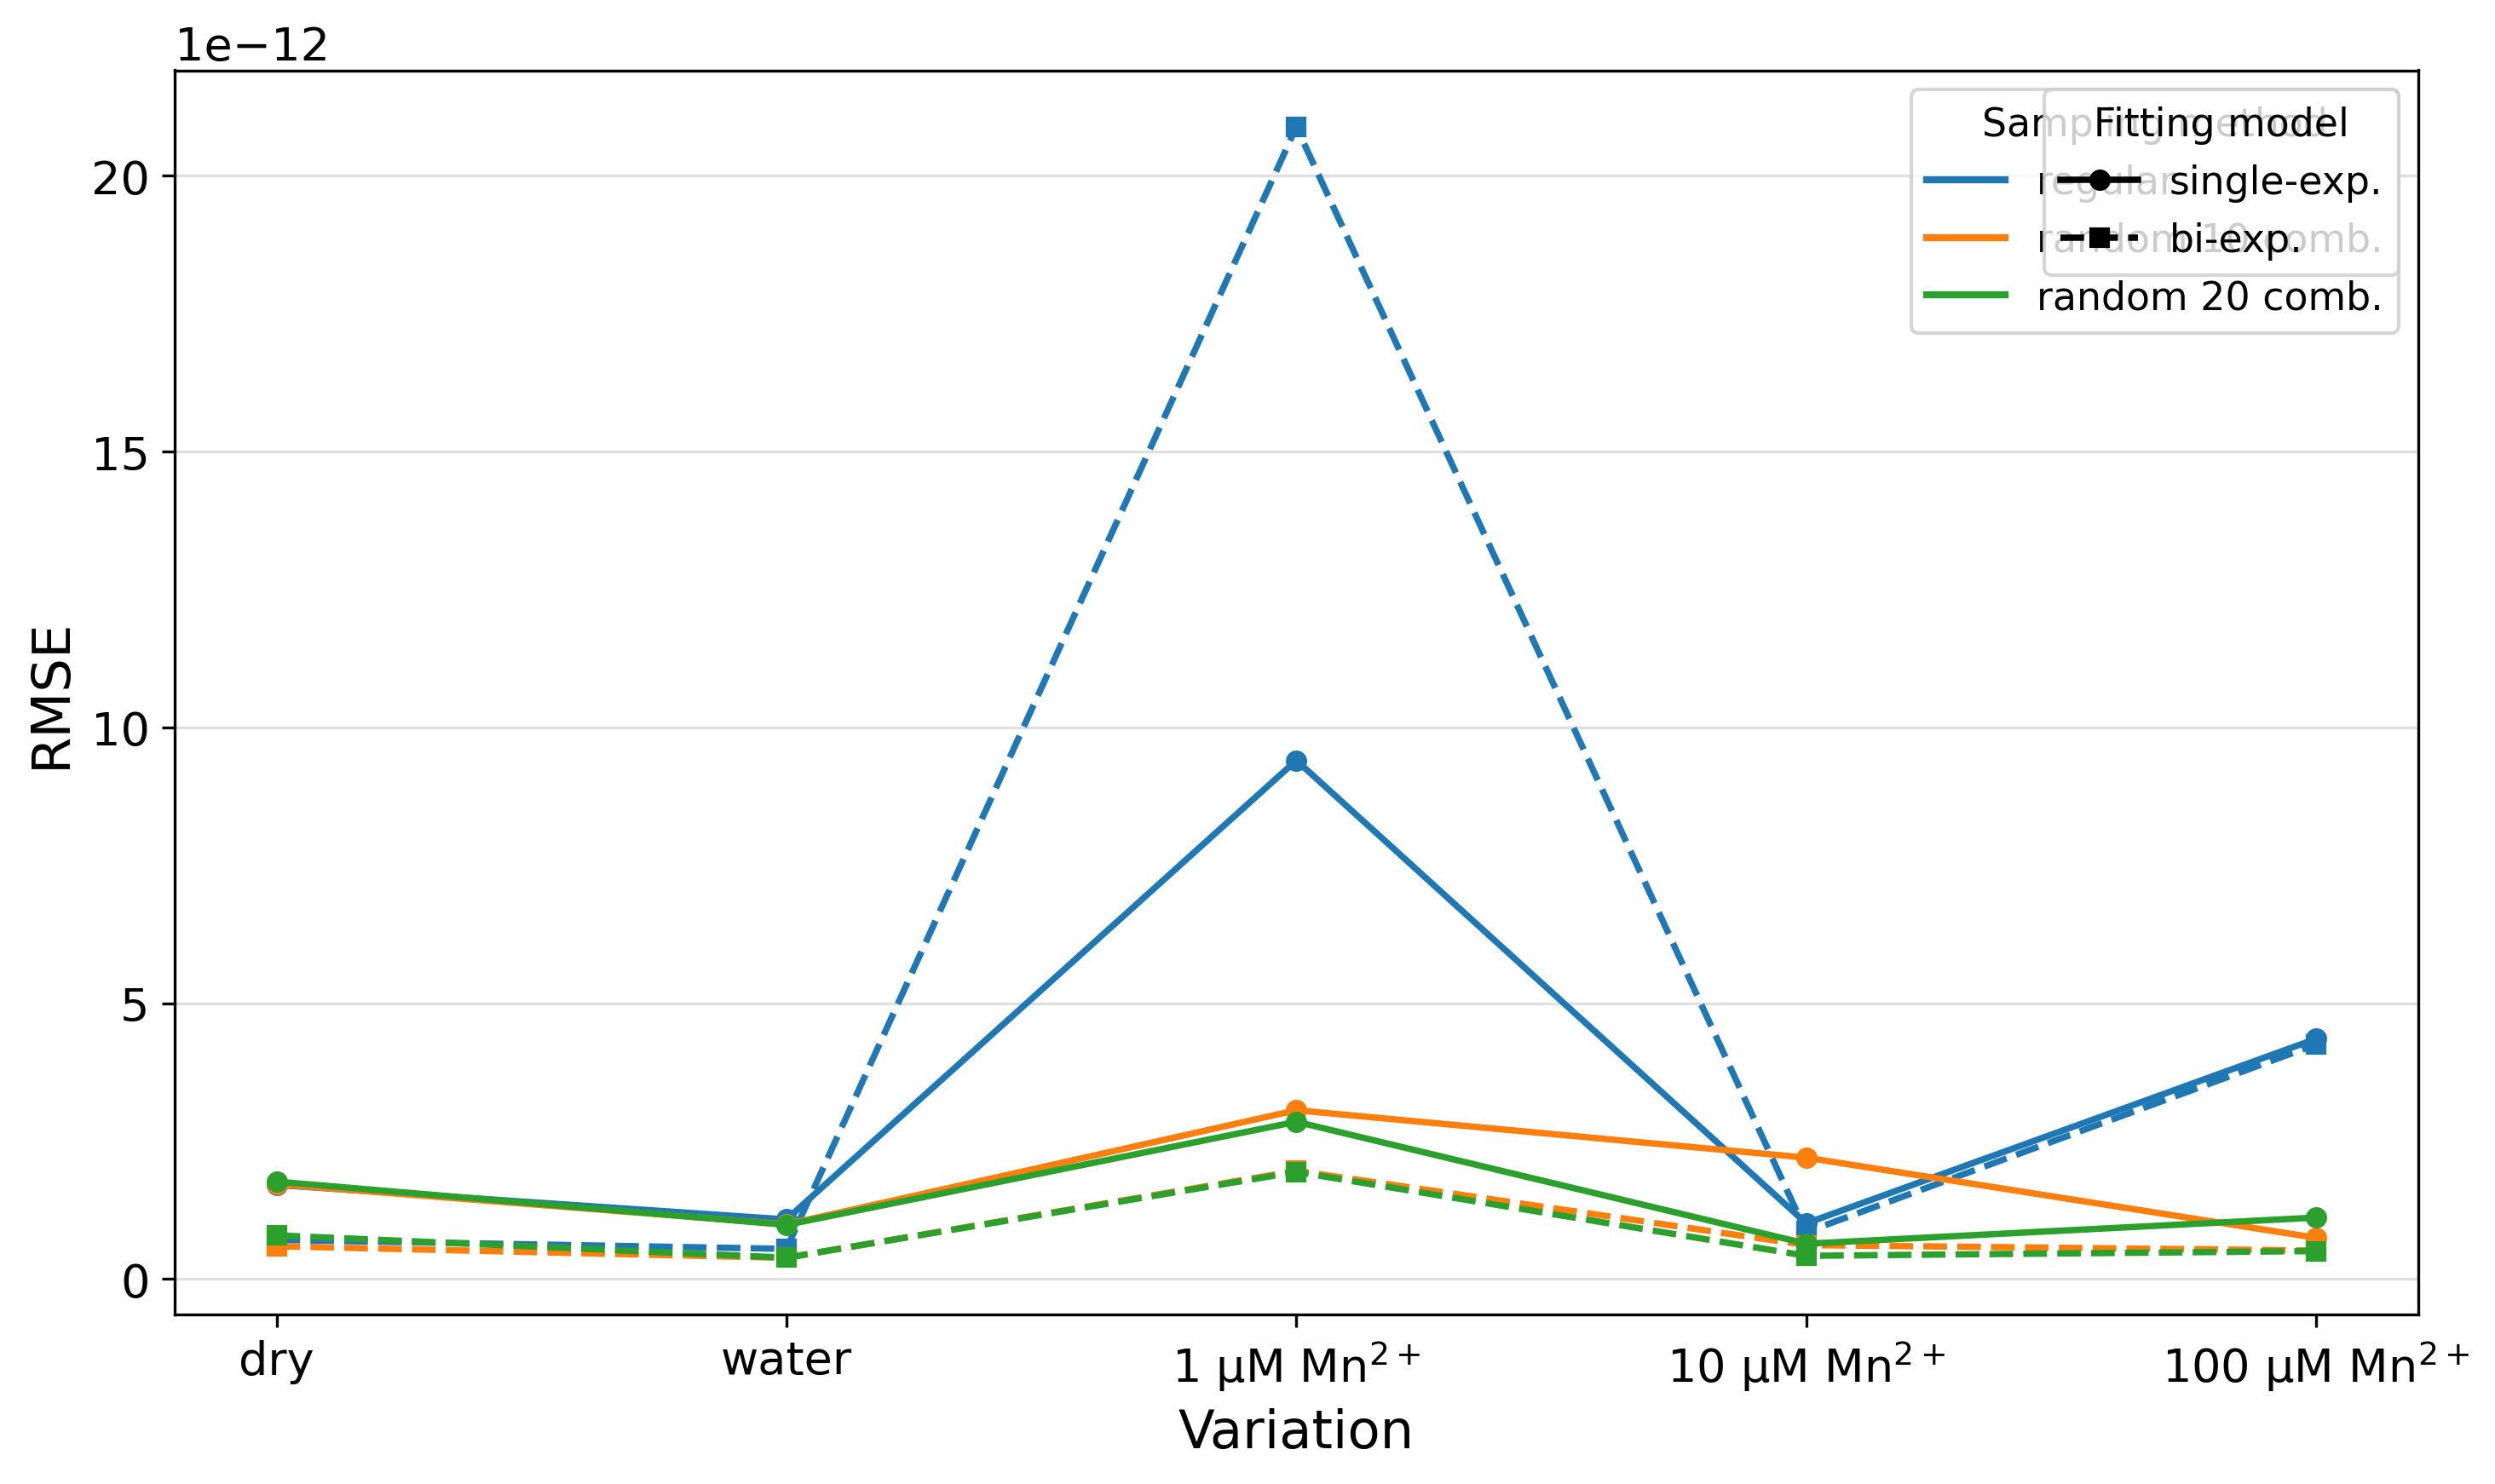

Saved: RMSE_single_vs_bi.png


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# =========================
# USER SETTINGS
# =========================
rmse_file = "a_recap.xlsx"
chi_file = "chi_square_output/average_reduced_chi_square.xlsx"

rmse_sheets = {
    "single": "single_rec (2)",
    "bi": "biexp_rec (3)",
}

chi_sheet_candidates = ["by_variation_method"]

variation_order = ["dry", "water", "1um", "10um", "100um"]
variation_labels = [
    "dry",
    "water",
    "1 μM Mn$^{2+}$",
    "10 μM Mn$^{2+}$",
    "100 μM Mn$^{2+}$",
]

methods_rmse = {
    "regular": "RMSE regular",
    "random10": "RMSE random 10 samples",
    "random20": "RMSE random 20 samples",
}

methods_label = {
    "regular": "regular",
    "random10": "random 10 comb.",
    "random20": "random 20 comb.",
}

colors = {
    "regular": "tab:blue",
    "random10": "tab:orange",
    "random20": "tab:green",
}

model_labels = {
    "single": "single-exp.",
    "bi": "bi-exp.",
}

model_styles = {
    "single": {
        "linestyle": "-",
        "marker": "o",
    },
    "bi": {
        "linestyle": "--",
        "marker": "s",
    },
}

output_chi = "reduced_chi_square_single_vs_bi.png"
output_rmse = "RMSE_single_vs_bi.png"


# =========================
# HELPER FUNCTION
# =========================
def standardize_variation_name(name):
    """
    Standardize variation names so that chi-square and RMSE data can be matched.
    """
    name = str(name).strip().lower()
    name = name.replace(" ", "")
    name = name.replace("µ", "u")
    name = name.replace("μ", "u")

    mapping = {
        "dry": "dry",
        "water": "water",
        "1um": "1um",
        "1um mn2+": "1um",
        "10um": "10um",
        "10um mn2+": "10um",
        "100um": "100um",
        "100um mn2+": "100um",
    }

    return mapping.get(name, name)


def prepare_rmse_data():
    """
    Load RMSE data from both single- and bi-exponential sheets,
    then convert them into long-format dataframe.
    """
    all_rmse = []

    for model, sheet_name in rmse_sheets.items():
        df = pd.read_excel(rmse_file, sheet_name=sheet_name)
        df.columns = df.columns.str.strip()

        # If the sheet already has a variation column, use it.
        # Otherwise, assume the rows follow variation_order.
        possible_variation_cols = [
            col for col in df.columns
            if col.lower().strip() in ["variation", "sample", "samples"]
        ]

        if possible_variation_cols:
            variation_col = possible_variation_cols[0]
            df["variation"] = df[variation_col].apply(standardize_variation_name)
        else:
            df["variation"] = variation_order[:len(df)]

        for method, rmse_col in methods_rmse.items():
            if rmse_col not in df.columns:
                raise KeyError(
                    f"Column '{rmse_col}' not found in sheet '{sheet_name}'. "
                    f"Available columns: {list(df.columns)}"
                )

            temp = pd.DataFrame({
                "variation": df["variation"],
                "sampling_method": method,
                "fitting_model": model,
                "RMSE": pd.to_numeric(df[rmse_col], errors="coerce")
            })

            all_rmse.append(temp)

    df_rmse_long = pd.concat(all_rmse, ignore_index=True)
    return df_rmse_long


def prepare_chi_data():
    """
    Load reduced chi-square data and clean the labels.
    """
    chi_excel = pd.ExcelFile(chi_file)

    chi_sheet = None
    for candidate in chi_sheet_candidates:
        if candidate in chi_excel.sheet_names:
            chi_sheet = candidate
            break

    if chi_sheet is None:
        raise ValueError(
            f"No chi-square sheet found. Available sheets: {chi_excel.sheet_names}"
        )

    df_chi = pd.read_excel(chi_file, sheet_name=chi_sheet)
    df_chi.columns = df_chi.columns.str.strip()

    required_cols = [
        "variation",
        "sampling_method",
        "fitting_model",
        "mean_reduced_chi_square",
    ]

    for col in required_cols:
        if col not in df_chi.columns:
            raise KeyError(
                f"Column '{col}' not found in chi-square file. "
                f"Available columns: {list(df_chi.columns)}"
            )

    df_chi["variation"] = df_chi["variation"].apply(standardize_variation_name)
    df_chi["sampling_method"] = df_chi["sampling_method"].astype(str).str.strip()
    df_chi["fitting_model"] = df_chi["fitting_model"].astype(str).str.strip()

    df_chi["mean_reduced_chi_square"] = pd.to_numeric(
        df_chi["mean_reduced_chi_square"],
        errors="coerce"
    )

    return df_chi


# =========================
# LOAD DATA
# =========================
df_rmse = prepare_rmse_data()
df_chi = prepare_chi_data()

x = np.arange(len(variation_order))


# =========================
# GENERAL PLOT FUNCTION
# =========================
def plot_metric(df, metric_col, ylabel, output_name, force_rmse_scientific=False):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    for method in ["regular", "random10", "random20"]:
        for model in ["single", "bi"]:

            subset = (
                df[
                    (df["sampling_method"] == method) &
                    (df["fitting_model"] == model)
                ]
                .set_index("variation")
                .reindex(variation_order)
            )

            ax.plot(
                x,
                subset[metric_col].values,
                color=colors[method],
                linestyle=model_styles[model]["linestyle"],
                marker=model_styles[model]["marker"],
                linewidth=1.8,
                markersize=5,
                label=f"{methods_label[method]} - {model_labels[model]}",
            )

    # =========================
    # AXIS SETTINGS
    # =========================
    ax.set_xticks(x)
    ax.set_xticklabels(variation_labels)

    ax.set_xlabel("Variation")
    ax.set_ylabel(ylabel)

    ax.grid(True, axis="y", alpha=0.4)

    # Show RMSE scientific notation on the axis itself
    if force_rmse_scientific:
        formatter = ticker.ScalarFormatter(useMathText=False)
        formatter.set_scientific(True)
        formatter.set_powerlimits((-12, -12))
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis="y", style="sci", scilimits=(-12, -12))

    # =========================
    # CUSTOM LEGENDS
    # =========================
    method_handles = [
        Line2D(
            [0], [0],
            color=colors[method],
            linewidth=2,
            label=methods_label[method],
        )
        for method in ["regular", "random10", "random20"]
    ]

    model_handles = [
        Line2D(
            [0], [0],
            color="black",
            linestyle=model_styles[model]["linestyle"],
            marker=model_styles[model]["marker"],
            linewidth=1.8,
            markersize=5,
            label=model_labels[model],
        )
        for model in ["single", "bi"]
    ]

    legend1 = ax.legend(
        handles=method_handles,
        title="Sampling method",
        fontsize=11,
        title_fontsize=11,
        loc="upper right",
    )

    ax.add_artist(legend1)

    ax.legend(
        handles=model_handles,
        title="Fitting model",
        fontsize=11,
        title_fontsize=11,
        loc="upper right",
    )

    plt.tight_layout()
    # plt.savefig(output_name, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_name}")


# =========================
# CREATE REDUCED CHI-SQUARE PLOT
# =========================
plot_metric(
    df=df_chi,
    metric_col="mean_reduced_chi_square",
    ylabel=r"$\chi_\nu^2$",
    output_name=output_chi,
    force_rmse_scientific=False,
)


# =========================
# CREATE RMSE PLOT
# =========================
plot_metric(
    df=df_rmse,
    metric_col="RMSE",
    ylabel="RMSE",
    output_name=output_rmse,
    force_rmse_scientific=True,
)

## All

   variation sampling_method  avg_reduced_chi_square      avg_RMSE
0      100um        random10                0.411348  6.305690e-13
1      100um        random20                0.996127  8.086092e-13
2      100um         regular                0.404494  4.303317e-12
3       10um        random10                0.151202  1.405767e-12
4       10um        random20                0.178589  5.286160e-13
5       10um         regular                0.467210  9.282042e-13
6        1um        random10                0.092475  2.509320e-12
7        1um        random20                0.085746  2.394895e-12
8        1um         regular                1.028253  1.514387e-11
9        dry        random10                0.009590  1.155849e-12
10       dry        random20                0.010608  1.277337e-12
11       dry         regular                6.130702  1.205999e-12
12     water        random10                0.041391  6.860814e-13
13     water        random20                0.664566  6.828584

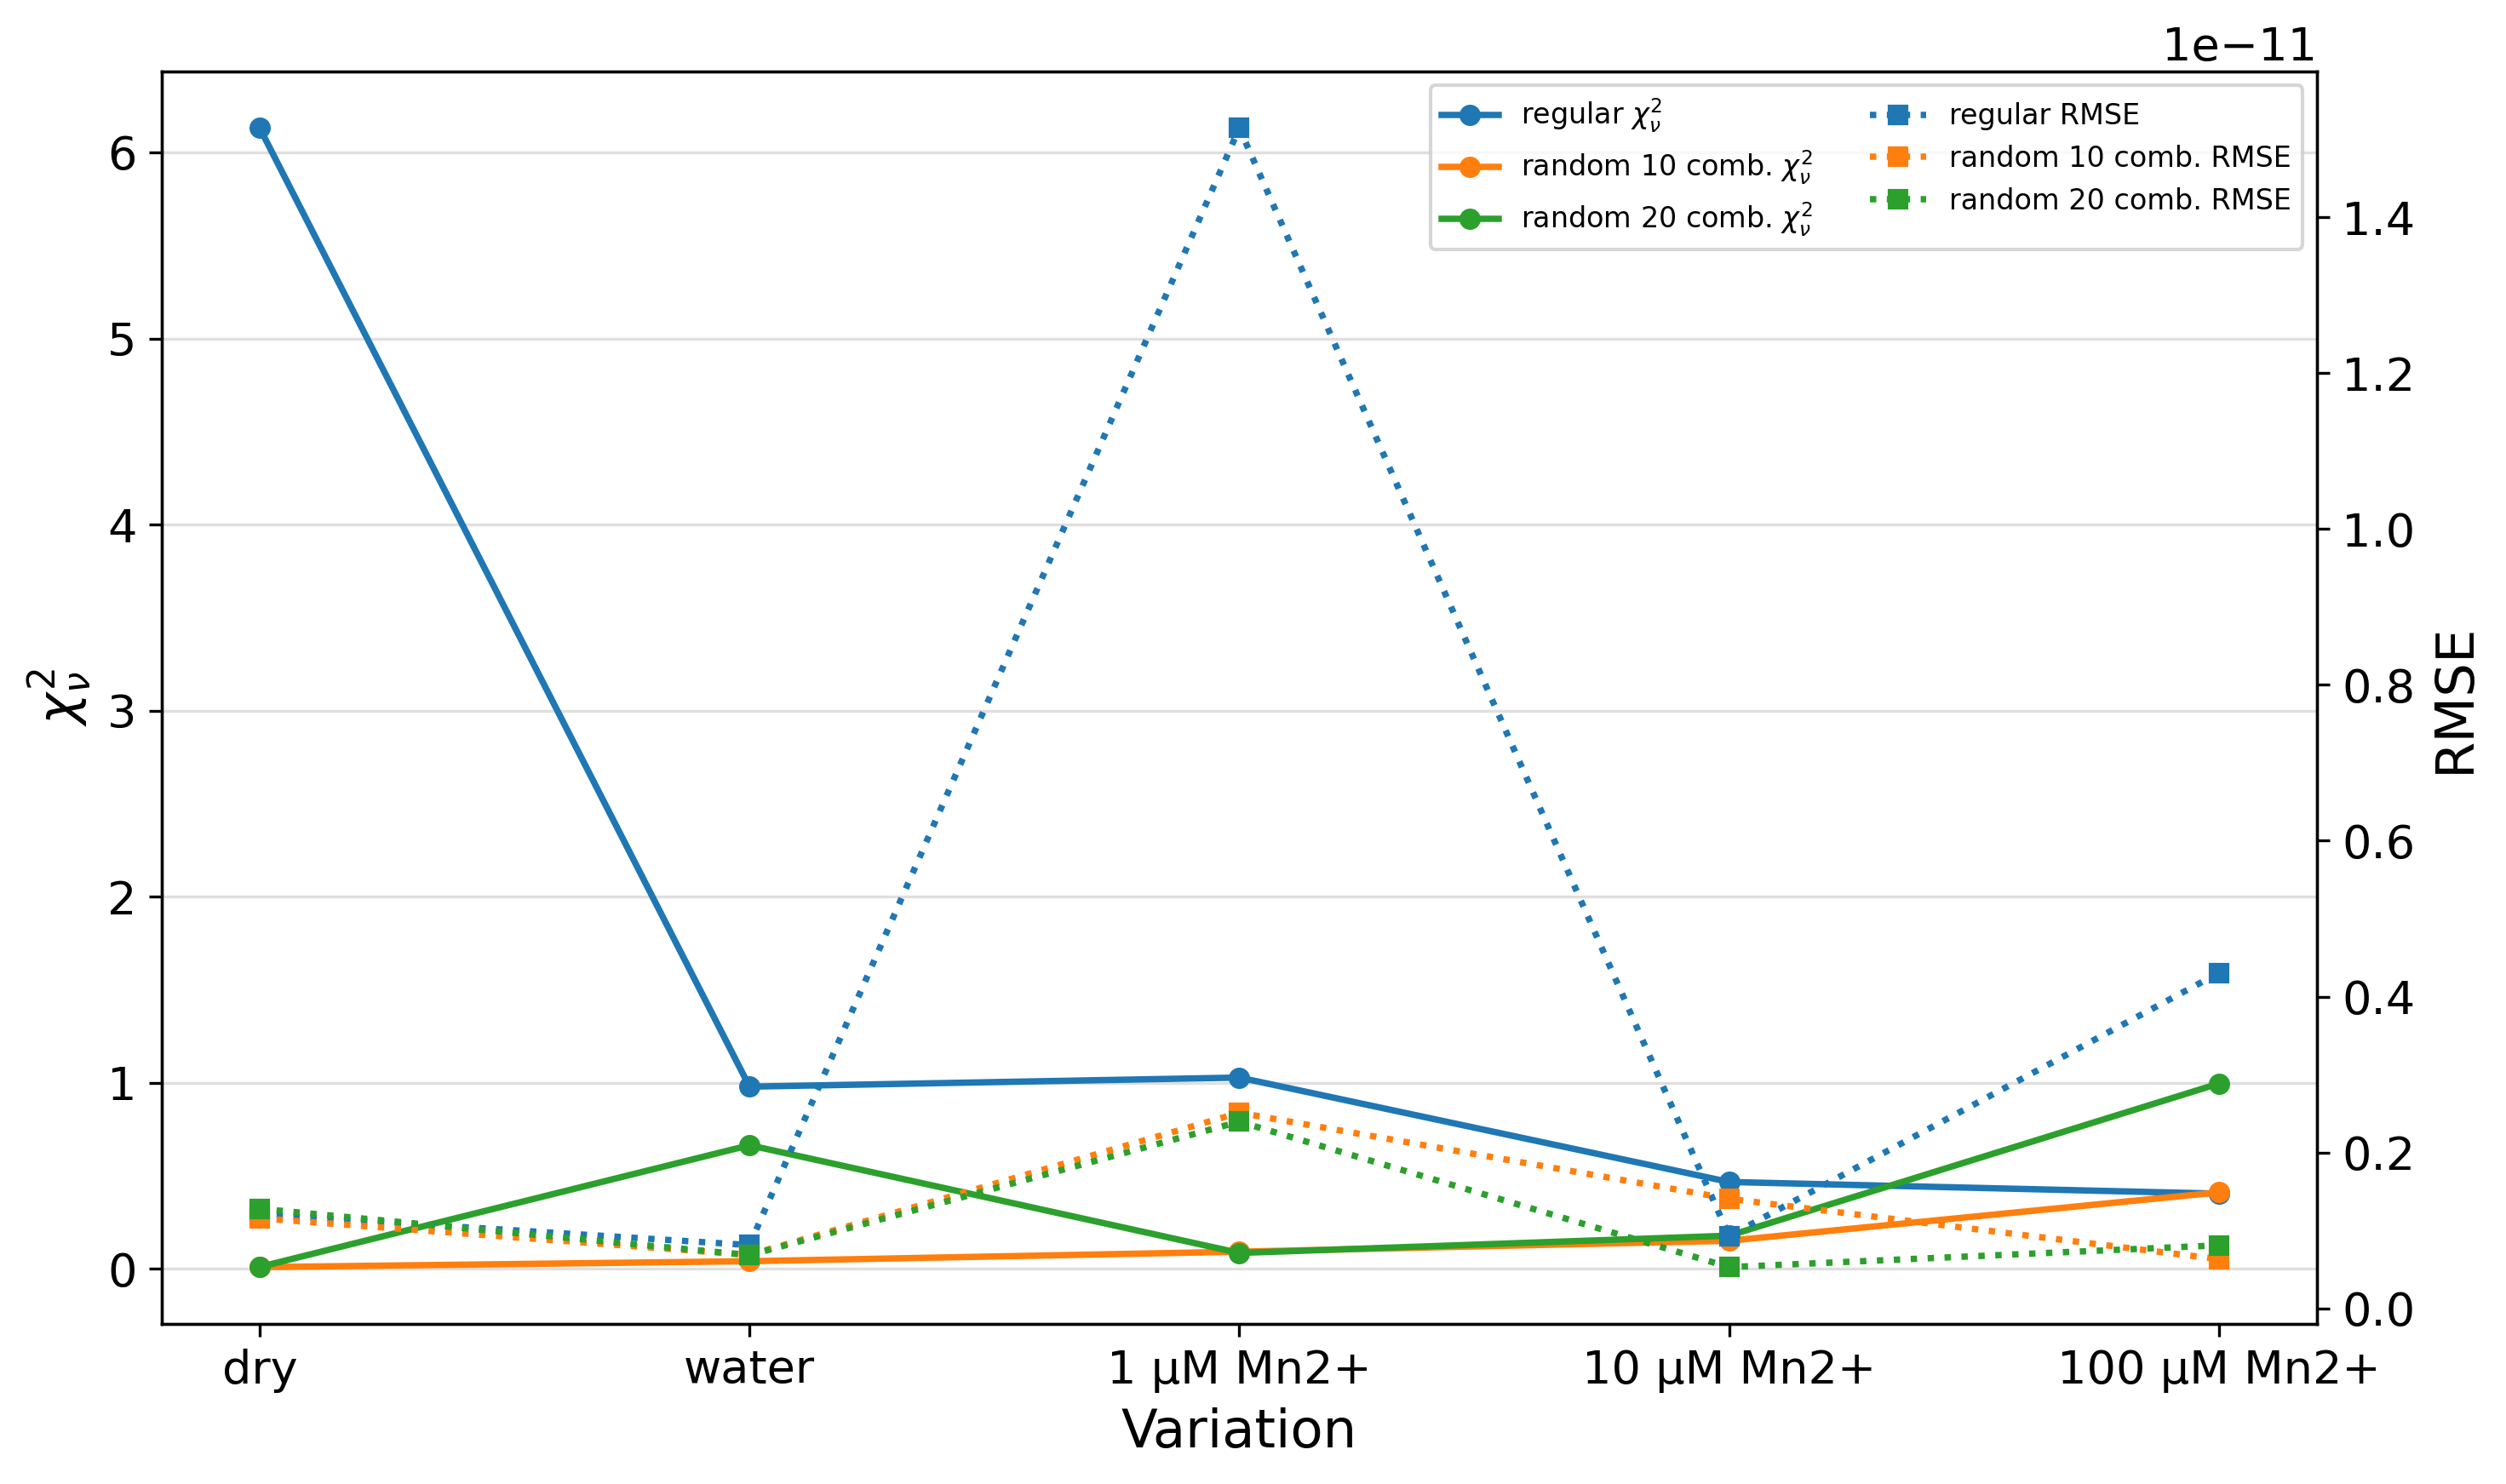

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
rmse_file = "a_recap.xlsx"
chi_file = r"chi_square_output\average_reduced_chi_square.xlsx"

rmse_sheets = {
    "single": "single_rec (2)",   # or "single_exp (2)"
    "bi": "biexp_rec (3)",        # or "biexp_rec (2)"
}

chi_sheet_candidates = ["by_average_method", "by_variation_method"]

variation_order = ["dry", "water", "1um", "10um", "100um"]
variation_labels = [
    "dry",
    "water",
    "1 μM Mn2+",
    "10 μM Mn2+",
    "100 μM Mn2+",
]

methods_rmse = {
    "regular": "RMSE regular",
    "random10": "RMSE random 10 samples",
    "random20": "RMSE random 20 samples",
}

methods_label = {
    "regular": "regular",
    "random10": "random 10 comb.",
    "random20": "random 20 comb.",
}

colors = {
    "regular": "tab:blue",
    "random10": "tab:orange",
    "random20": "tab:green",
}

# =========================
# LOAD CHI-SQUARE DATA
# =========================
chi_excel = pd.ExcelFile(chi_file)

chi_sheet = None
for candidate in chi_sheet_candidates:
    if candidate in chi_excel.sheet_names:
        chi_sheet = candidate
        break

if chi_sheet is None:
    raise ValueError(f"No chi-square sheet found. Available sheets: {chi_excel.sheet_names}")

df_chi = pd.read_excel(chi_file, sheet_name=chi_sheet)
df_chi.columns = df_chi.columns.str.strip()

df_chi["variation"] = df_chi["variation"].astype(str).str.strip()
df_chi["sampling_method"] = df_chi["sampling_method"].astype(str).str.strip()
df_chi["fitting_model"] = df_chi["fitting_model"].astype(str).str.strip()
df_chi["mean_reduced_chi_square"] = pd.to_numeric(
    df_chi["mean_reduced_chi_square"],
    errors="coerce"
)

# Average chi-square across single and bi models
df_chi_avg = (
    df_chi.groupby(["variation", "sampling_method"], as_index=False)
    .agg(avg_reduced_chi_square=("mean_reduced_chi_square", "mean"))
)

# =========================
# LOAD AND AVERAGE RMSE DATA
# =========================
rmse_frames = []

for model, sheet in rmse_sheets.items():
    df_rmse = pd.read_excel(rmse_file, sheet_name=sheet)
    df_rmse.columns = df_rmse.columns.str.strip()

    # Use fixed variation order
    df_model = pd.DataFrame({
        "variation": variation_order,
        "regular": pd.to_numeric(df_rmse[methods_rmse["regular"]], errors="coerce"),
        "random10": pd.to_numeric(df_rmse[methods_rmse["random10"]], errors="coerce"),
        "random20": pd.to_numeric(df_rmse[methods_rmse["random20"]], errors="coerce"),
    })

    df_model["fitting_model"] = model
    rmse_frames.append(df_model)

df_rmse_all = pd.concat(rmse_frames, ignore_index=True)

# Convert wide RMSE format to long format
df_rmse_long = df_rmse_all.melt(
    id_vars=["variation", "fitting_model"],
    value_vars=["regular", "random10", "random20"],
    var_name="sampling_method",
    value_name="RMSE",
)

# Average RMSE across single and bi models
df_rmse_avg = (
    df_rmse_long.groupby(["variation", "sampling_method"], as_index=False)
    .agg(avg_RMSE=("RMSE", "mean"))
)

# =========================
# MERGE AVERAGED CHI + RMSE
# =========================
df_avg = pd.merge(
    df_chi_avg,
    df_rmse_avg,
    on=["variation", "sampling_method"],
    how="inner",
)

print(df_avg)

# =========================
# PLOT
# =========================
x = np.arange(len(variation_order))

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
ax2 = ax1.twinx()

for method in ["regular", "random10", "random20"]:
    subset = (
        df_avg[df_avg["sampling_method"] == method]
        .set_index("variation")
        .reindex(variation_order)
    )

    ax1.plot(
        x,
        subset["avg_reduced_chi_square"].values,
        color=colors[method],
        marker="o",
        linestyle="-",
        linewidth=1.8,
        markersize=5,
        label=rf"{methods_label[method]} $\chi_\nu^2$",
    )

    ax2.plot(
        x,
        subset["avg_RMSE"].values,
        color=colors[method],
        marker="s",
        linestyle=":",
        linewidth=1.8,
        markersize=5,
        label=f"{methods_label[method]} RMSE",
    )

ax1.set_xticks(x)
ax1.set_xticklabels(variation_labels)

ax1.set_xlabel("Variation")
ax1.set_ylabel(r"$\chi_\nu^2$")
ax2.set_ylabel("RMSE")

ax1.grid(True, axis="y", alpha=0.4)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    fontsize=8,
    ncol=2,
    loc="upper right",
)

# plt.title("Average reduced chi-square and RMSE across fitting models")
plt.tight_layout()

plt.savefig("avg_red_chi_square_RMSE_single_bi.png", dpi=300, bbox_inches="tight")
plt.show()

# T1 Local Trendline

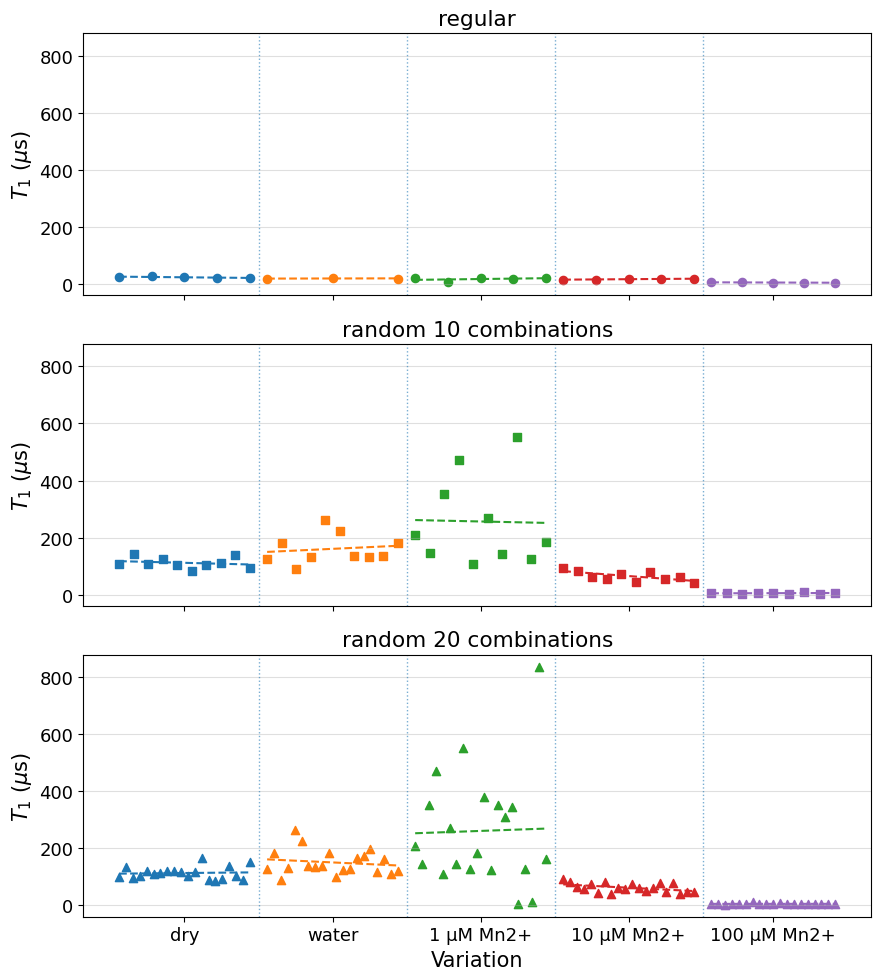

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
file_name = "a_recap.xlsx"

sheet_name_reg = "single"
sheet_name_rand1 = "biexp_rand"
sheet_name_rand2 = "biexp_rand2"

df_reg = pd.read_excel(file_name, sheet_name=sheet_name_reg)
df_rand1 = pd.read_excel(file_name, sheet_name=sheet_name_rand1)
df_rand2 = pd.read_excel(file_name, sheet_name=sheet_name_rand2)

df_reg.columns = df_reg.columns.str.strip()
df_rand1.columns = df_rand1.columns.str.strip()
df_rand2.columns = df_rand2.columns.str.strip()

# =========================
# SELECT COLUMNS
# =========================
variation_col = "variations"
t1_col = "Tau1"

# =========================
# STORE DATASETS
# =========================
datasets = {
    "regular": df_reg,
    "random 10 combinations": df_rand1,
    "random 20 combinations": df_rand2
}

# =========================
# GET VARIATION ORDER
# =========================

all_variations = pd.concat([
    df_reg[variation_col],
    df_rand1[variation_col],
    df_rand2[variation_col]
]).astype(str)

variation_order = all_variations.drop_duplicates().values

new_variation_labels = ["dry", "water", "1 μM Mn2+", "10 μM Mn2+", "100 μM Mn2+"]

# =========================
# FIND MAXIMUM NUMBER OF POINTS PER VARIATION
# =========================
max_counts = {}

for variation in variation_order:
    counts = []

    for df in datasets.values():
        count = (df[variation_col].astype(str) == variation).sum()
        counts.append(count)

    max_counts[variation] = max(counts)

# =========================
# CREATE BLOCK POSITIONS
# =========================
block_starts = {}
tick_positions = []
tick_labels = []
border_positions = []

current_start = 0
gap = 1.5

for i, variation in enumerate(variation_order):
    block_width = max_counts[variation]

    block_starts[variation] = current_start

    center_position = current_start + (block_width - 1) / 2
    tick_positions.append(center_position)
    tick_labels.append(new_variation_labels[i])

    if i < len(variation_order) - 1:
        border_position = current_start + block_width - 0.5 + gap / 2
        border_positions.append(border_position)

    current_start += block_width + gap

# =========================
# FUNCTION TO GET X POSITIONS PER VARIATION
# =========================
def get_positions_for_variation(df, variation, variation_col, block_starts, max_counts):
    subset = df[df[variation_col].astype(str) == variation].copy()

    n_points = len(subset)

    if n_points == 0:
        return np.array([]), np.array([])

    start = block_starts[variation]
    max_count = max_counts[variation]

    if n_points == 1:
        x = np.array([start + (max_count - 1) / 2])
    else:
        x = start + np.linspace(0, max_count - 1, n_points)

    y = subset[t1_col].values

    return x, y

# =========================
# MAKE 3 VERTICAL SUBPLOTS
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(9, 10),
    sharex=True,
    sharey=True
)

markers = {
    "regular": "o",
    "random 10 combinations": "s",
    "random 20 combinations": "^"
}

for ax, (method_name, df) in zip(axes, datasets.items()):

    for variation in variation_order:
        x, y = get_positions_for_variation(
            df,
            variation,
            variation_col,
            block_starts,
            max_counts
        )

        if len(x) == 0:
            continue

        # Plot raw data points only
        ax.scatter(
            x,
            y,
            marker=markers[method_name],
            s=35,
            label=variation if method_name == "regular" else None
        )

        # Plot local trendline for each variation
        if len(x) >= 2:
            coeff = np.polyfit(x, y, deg=1)
            trend = np.polyval(coeff, x)

            ax.plot(
                x,
                trend,
                linestyle="--",
                linewidth=1.5
            )

    # Add vertical borders between variations
    for border in border_positions:
        ax.axvline(
            x=border,
            linestyle=":",
            linewidth=1,
            alpha=0.6
        )

    ax.set_ylabel(r"$T_1$ ($\mu$s)")
    ax.set_title(method_name)
    ax.grid(True, axis="y", alpha=0.4)

# =========================
# X-AXIS SETTINGS
# =========================
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_labels)
axes[-1].set_xlabel("Variation")

plt.tight_layout()

plt.savefig("T1_biexp_short_local_trendlines.png", dpi=300, bbox_inches="tight")

plt.show()

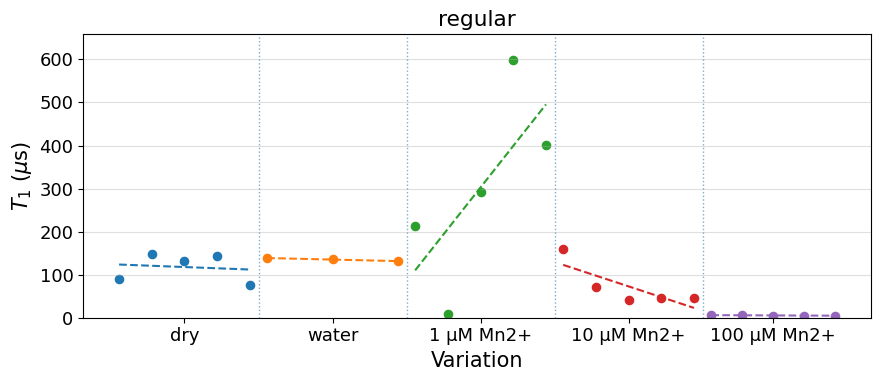

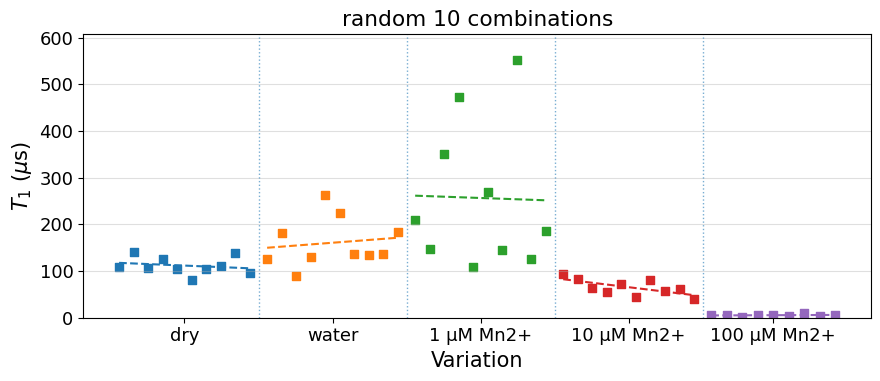

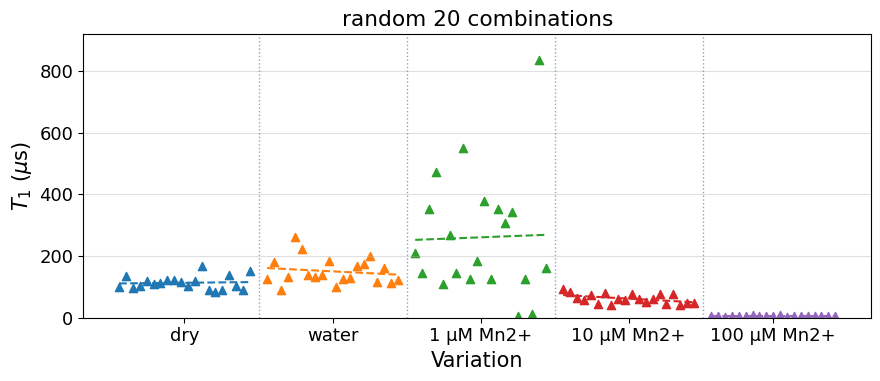

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
file_name = "a_recap.xlsx"

# Use bi-exponential sheets for Tau1 and Tau2
sheet_name_reg = "biexp"
sheet_name_rand1 = "biexp_rand"
sheet_name_rand2 = "biexp_rand2"

df_reg = pd.read_excel(file_name, sheet_name=sheet_name_reg)
df_rand1 = pd.read_excel(file_name, sheet_name=sheet_name_rand1)
df_rand2 = pd.read_excel(file_name, sheet_name=sheet_name_rand2)

df_reg.columns = df_reg.columns.str.strip()
df_rand1.columns = df_rand1.columns.str.strip()
df_rand2.columns = df_rand2.columns.str.strip()

# =========================
# SELECT COLUMNS
# =========================
variation_col = "variations"

# Change this to "Tau1" or "Tau2"
t1_col = "Tau1"

# =========================
# STORE DATASETS
# =========================
datasets = {
    "regular": df_reg,
    "random 10 combinations": df_rand1,
    "random 20 combinations": df_rand2
}

# =========================
# CHECK COLUMNS
# =========================
for method_name, df in datasets.items():
    if variation_col not in df.columns:
        raise ValueError(
            f"Column '{variation_col}' was not found in {method_name}.\n"
            f"Available columns: {list(df.columns)}"
        )

    if t1_col not in df.columns:
        raise ValueError(
            f"Column '{t1_col}' was not found in {method_name}.\n"
            f"Available columns: {list(df.columns)}"
        )

# =========================
# GET VARIATION ORDER
# =========================
all_variations = pd.concat([
    df_reg[variation_col],
    df_rand1[variation_col],
    df_rand2[variation_col]
]).astype(str)

variation_order = all_variations.drop_duplicates().values

new_variation_labels = [
    "dry",
    "water",
    "1 μM Mn2+",
    "10 μM Mn2+",
    "100 μM Mn2+"
]

# =========================
# FIND MAXIMUM NUMBER OF POINTS PER VARIATION
# =========================
max_counts = {}

for variation in variation_order:
    counts = []

    for df in datasets.values():
        count = (df[variation_col].astype(str) == variation).sum()
        counts.append(count)

    max_counts[variation] = max(counts)

# =========================
# CREATE BLOCK POSITIONS
# =========================
block_starts = {}
tick_positions = []
tick_labels = []
border_positions = []

current_start = 0
gap = 1.5

for i, variation in enumerate(variation_order):
    block_width = max_counts[variation]

    block_starts[variation] = current_start

    center_position = current_start + (block_width - 1) / 2
    tick_positions.append(center_position)

    if i < len(new_variation_labels):
        tick_labels.append(new_variation_labels[i])
    else:
        tick_labels.append(str(variation))

    if i < len(variation_order) - 1:
        border_position = current_start + block_width - 0.5 + gap / 2
        border_positions.append(border_position)

    current_start += block_width + gap

# =========================
# FUNCTION TO GET X AND Y POSITIONS
# =========================
def get_positions_for_variation(df, variation):
    subset = df[df[variation_col].astype(str) == variation].copy()

    y = pd.to_numeric(subset[t1_col], errors="coerce")
    y = y.replace([np.inf, -np.inf], np.nan).dropna().values

    n_points = len(y)

    if n_points == 0:
        return np.array([]), np.array([])

    start = block_starts[variation]
    max_count = max_counts[variation]

    if n_points == 1:
        x = np.array([start + (max_count - 1) / 2])
    else:
        x = start + np.linspace(0, max_count - 1, n_points)

    return x, y

# =========================
# FUNCTION FOR AUTOMATIC Y-LIMIT
# =========================
def get_auto_ylim(df, y_col, margin_ratio=0.10):
    y_all = pd.to_numeric(df[y_col], errors="coerce")
    y_all = y_all.replace([np.inf, -np.inf], np.nan).dropna().values

    if len(y_all) == 0:
        return None

    ymin = np.min(y_all)
    ymax = np.max(y_all)

    y_range = ymax - ymin

    if y_range == 0:
        y_range = max(abs(ymax), 1)

    margin = margin_ratio * y_range

    # Since T1 should be positive, keep the lower limit at 0
    lower_limit = 0
    upper_limit = ymax + margin

    return lower_limit, upper_limit

# =========================
# PLOT SETTINGS
# =========================
markers = {
    "regular": "o",
    "random 10 combinations": "s",
    "random 20 combinations": "^"
}

# =========================
# CREATE 3 SEPARATE PLOTS
# =========================
for method_name, df in datasets.items():

    fig, ax = plt.subplots(figsize=(9, 4))

    for variation in variation_order:
        x, y = get_positions_for_variation(df, variation)

        if len(x) == 0:
            continue

        scatter = ax.scatter(
            x,
            y,
            marker=markers[method_name],
            s=35,
            label=str(variation)
        )

        point_color = scatter.get_facecolor()[0]

        # Local trendline for each variation
        if len(x) >= 2:
            coeff = np.polyfit(x, y, deg=1)
            trend = np.polyval(coeff, x)

            ax.plot(
                x,
                trend,
                linestyle="--",
                linewidth=1.5,
                color=point_color
            )

    # Vertical borders between variations
    for border in border_positions:
        ax.axvline(
            x=border,
            linestyle=":",
            linewidth=1,
            alpha=0.6
        )

    # X-axis settings
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel("Variation")
    ax.set_ylabel(r"$T_1$ ($\mu$s)")

    ax.set_title(f"{method_name}")

    # Automatic y-limit for each separate plot
    auto_ylim = get_auto_ylim(df, t1_col, margin_ratio=0.10)

    if auto_ylim is not None:
        ax.set_ylim(auto_ylim)

    ax.grid(True, axis="y", alpha=0.4)

    plt.tight_layout()

    file_safe_name = method_name.replace(" ", "_")

    plt.savefig(
        f"T1_biexp_long_{t1_col}_{file_safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# Error Correlation

In [8]:
import os
import glob
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import pearsonr, spearmanr


# ============================================================
# USER SETTINGS
# ============================================================

base_path = "./raw_data/new"

variations = ["dry", "water", "1 uM", "10 uM", "100 uM"]

variation_labels = {
    "dry": "Dry",
    "water": "Water",
    "1 uM": r"1 $\mu$M Mn$^{2+}$",
    "10 uM": r"10 $\mu$M Mn$^{2+}$",
    "100 uM": r"100 $\mu$M Mn$^{2+}$"
}

sampling_methods = {
    "regular": "regular",
    "random": "random 10 comb.",
    "random2": "random 20 comb."
}

corr_method = "pearson"

output_excel = "std_error_correlation_by_tau_index.xlsx"

In [9]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_column(df, possible_names):
    df.columns = df.columns.str.strip()

    for name in possible_names:
        if name in df.columns:
            return name

    raise ValueError(
        f"None of these columns were found: {possible_names}\n"
        f"Available columns: {list(df.columns)}"
    )


def load_signal_file(filename):
    """
    Load one Excel file.

    Tau_Index is used as the main identifier for matching tau points.
    This avoids mismatch caused by floating-point tau values.
    """

    df = pd.read_excel(filename)
    df.columns = df.columns.str.strip()

    tau_col = find_column(
        df,
        ["Tau", "Tau (us)", "tau", "tau (us)", "Dark Time", "Dark time", "Dark time (us)"]
    )

    signal_col = find_column(
        df,
        ["Signal", "signal", "Signal Ratio", "PL Ratio", "Ratio", "Normalized Signal"]
    )

    df = df[[tau_col, signal_col]].copy()
    df.columns = ["Tau", "Signal"]

    df = df.dropna()
    df = df.sort_values("Tau").reset_index(drop=True)

    # Main fix:
    # use the order of tau points instead of the exact tau value
    df["Tau_Index"] = np.arange(len(df))

    return df


def calculate_std_error_for_method(folder_path, variation, method_key, method_label):
    """
    Calculate STD across files at each Tau_Index.
    """

    files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")))

    files = [
        f for f in files
        if "summary" not in os.path.basename(f).lower()
        and "correlation" not in os.path.basename(f).lower()
        and "recap" not in os.path.basename(f).lower()
    ]

    if len(files) == 0:
        return None, None

    all_rows = []

    for file_index, file in enumerate(files, start=1):

        df = load_signal_file(file)

        df["Variation"] = variation
        df["Sampling Method"] = method_label
        df["Sampling Method Key"] = method_key
        df["File Index"] = file_index
        df["Filename"] = os.path.basename(file)

        all_rows.append(df)

    raw_df = pd.concat(all_rows, ignore_index=True)

    std_df = raw_df.groupby(
        ["Variation", "Sampling Method", "Sampling Method Key", "Tau_Index"]
    ).agg(
        Tau=("Tau", "mean"),
        Tau_STD=("Tau", "std"),
        Mean_Signal=("Signal", "mean"),
        Std_Across_Files=("Signal", "std"),
        SEM_Across_Files=("Signal", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan),
        N_Files=("Signal", "count")
    ).reset_index()

    return std_df, raw_df


def calculate_corr_and_pvalue(x, y, method="pearson"):
    valid = x.notna() & y.notna()

    x_valid = x[valid]
    y_valid = y[valid]

    n = len(x_valid)

    if n < 3:
        return np.nan, np.nan, n

    if method == "pearson":
        r, p_value = pearsonr(x_valid, y_valid)
    elif method == "spearman":
        r, p_value = spearmanr(x_valid, y_valid)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    return r, p_value, n


def interpret_correlation(r):
    if pd.isna(r):
        return "not available"

    abs_r = abs(r)

    if abs_r >= 0.80:
        strength = "strong"
    elif abs_r >= 0.60:
        strength = "moderate"
    elif abs_r >= 0.40:
        strength = "weak to moderate"
    else:
        strength = "weak"

    if r > 0:
        direction = "positive"
    elif r < 0:
        direction = "negative"
    else:
        direction = "no"

    return f"{strength} {direction} correlation"

In [10]:
# ============================================================
# CALCULATE STD ERROR ACROSS FILES
# ============================================================

std_summary_list = []
raw_data_list = []

for variation in variations:

    print(f"\nProcessing variation: {variation}")

    for method_key, method_label in sampling_methods.items():

        folder_path = os.path.join(base_path, variation, method_key)

        if not os.path.isdir(folder_path):
            print(f"Skipped, folder not found: {folder_path}")
            continue

        std_df, raw_df = calculate_std_error_for_method(
            folder_path=folder_path,
            variation=variation,
            method_key=method_key,
            method_label=method_label
        )

        if std_df is None:
            print(f"Skipped, no Excel files found: {folder_path}")
            continue

        std_summary_list.append(std_df)
        raw_data_list.append(raw_df)

        n_files = raw_df["Filename"].nunique()
        n_tau = std_df["Tau_Index"].nunique()

        print(f"  {method_label}: {n_files} files, {n_tau} tau points")


std_summary_all = pd.concat(std_summary_list, ignore_index=True)
raw_all = pd.concat(raw_data_list, ignore_index=True)

std_summary_all.head()


Processing variation: dry
  regular: 5 files, 40 tau points
  random 10 comb.: 10 files, 40 tau points
  random 20 comb.: 20 files, 40 tau points

Processing variation: water
  regular: 3 files, 40 tau points
  random 10 comb.: 10 files, 40 tau points
  random 20 comb.: 20 files, 40 tau points

Processing variation: 1 uM
  regular: 5 files, 40 tau points
  random 10 comb.: 10 files, 40 tau points
  random 20 comb.: 20 files, 40 tau points

Processing variation: 10 uM
  regular: 5 files, 40 tau points
  random 10 comb.: 10 files, 40 tau points
  random 20 comb.: 20 files, 40 tau points

Processing variation: 100 uM
  regular: 5 files, 40 tau points
  random 10 comb.: 10 files, 40 tau points
  random 20 comb.: 20 files, 40 tau points


,Variation,Sampling Method,Sampling Method Key,Tau_Index,Tau,Tau_STD,Mean_Signal,Std_Across_Files,SEM_Across_Files,N_Files
0,dry,regular,regular,0,2.0,0.0,1.078235e-08,7.591981e-11,3.395237e-11,5
1,dry,regular,regular,1,2.0,0.0,1.078444e-08,7.810865e-11,3.493125e-11,5
2,dry,regular,regular,2,2.0,0.0,1.078269e-08,7.753495e-11,3.467468e-11,5
3,dry,regular,regular,3,3.0,0.0,1.078121e-08,7.649512e-11,3.420966e-11,5
4,dry,regular,regular,4,4.0,0.0,1.078026e-08,7.578061e-11,3.389012e-11,5


In [11]:
# ============================================================
# CHECK TAU COMPLETENESS
# ============================================================

tau_check = std_summary_all.groupby(
    ["Variation", "Sampling Method"]
).agg(
    N_Tau=("Tau_Index", "nunique"),
    Mean_N_Files=("N_Files", "mean"),
    Min_N_Files=("N_Files", "min"),
    Max_N_Files=("N_Files", "max"),
    Max_Tau_STD=("Tau_STD", "max")
).reset_index()

tau_check

,Variation,Sampling Method,N_Tau,Mean_N_Files,Min_N_Files,Max_N_Files,Max_Tau_STD
0,1 uM,random 10 comb.,40,10.0,10,10,0.0
1,1 uM,random 20 comb.,40,20.0,20,20,0.0
2,1 uM,regular,40,5.0,5,5,0.0
3,10 uM,random 10 comb.,40,10.0,10,10,0.0
4,10 uM,random 20 comb.,40,20.0,20,20,0.0
5,10 uM,regular,40,5.0,5,5,0.0
6,100 uM,random 10 comb.,40,10.0,10,10,0.0
7,100 uM,random 20 comb.,40,20.0,20,20,0.0
8,100 uM,regular,40,5.0,5,5,0.0
9,dry,random 10 comb.,40,10.0,10,10,0.0


In [12]:
# ============================================================
# CALCULATE CORRELATION BETWEEN STD ERROR CURVES
# ============================================================

correlation_rows = []
correlation_matrices = {}
error_pivot_tables = {}

for variation in variations:

    variation_data = std_summary_all[
        std_summary_all["Variation"] == variation
    ].copy()

    error_pivot = variation_data.pivot_table(
        index="Tau_Index",
        columns="Sampling Method",
        values="Std_Across_Files",
        aggfunc="mean"
    )

    ordered_methods = [
        label for key, label in sampling_methods.items()
        if label in error_pivot.columns
    ]

    error_pivot = error_pivot[ordered_methods]
    error_pivot = error_pivot.dropna()

    error_pivot_tables[variation] = error_pivot
    correlation_matrices[variation] = error_pivot.corr(method=corr_method)

    for method_1, method_2 in combinations(ordered_methods, 2):

        r, p_value, n_tau = calculate_corr_and_pvalue(
            error_pivot[method_1],
            error_pivot[method_2],
            method=corr_method
        )

        correlation_rows.append({
            "Variation": variation,
            "Variation Label": variation_labels.get(variation, variation),
            "Method 1": method_1,
            "Method 2": method_2,
            "Correlation Method": corr_method,
            "r": r,
            "p-value": p_value,
            "N tau": n_tau,
            "Interpretation": interpret_correlation(r)
        })


correlation_table = pd.DataFrame(correlation_rows)

correlation_table_display = correlation_table.copy()
correlation_table_display["r"] = correlation_table_display["r"].round(3)
correlation_table_display["p-value"] = correlation_table_display["p-value"].round(4)

correlation_table_display

,Variation,Variation Label,Method 1,Method 2,Correlation Method,r,p-value,N tau,Interpretation
0,dry,Dry,regular,random 10 comb.,pearson,0.940,0.0000,40,strong positive correlation
1,dry,Dry,regular,random 20 comb.,pearson,0.941,0.0000,40,strong positive correlation
2,dry,Dry,random 10 comb.,random 20 comb.,pearson,0.993,0.0000,40,strong positive correlation
3,water,Water,regular,random 10 comb.,pearson,0.953,0.0000,40,strong positive correlation
4,water,Water,regular,random 20 comb.,pearson,0.987,0.0000,40,strong positive correlation
5,water,Water,random 10 comb.,random 20 comb.,pearson,0.971,0.0000,40,strong positive correlation
6,1 uM,1 $\mu$M Mn$^{2+}$,regular,random 10 comb.,pearson,0.265,0.0988,40,weak positive correlation
7,1 uM,1 $\mu$M Mn$^{2+}$,regular,random 20 comb.,pearson,0.544,0.0003,40,weak to moderate positive correlation
8,1 uM,1 $\mu$M Mn$^{2+}$,random 10 comb.,random 20 comb.,pearson,0.399,0.0107,40,weak positive correlation
9,10 uM,10 $\mu$M Mn$^{2+}$,regular,random 10 comb.,pearson,-0.597,0.0000,40,weak to moderate negative correlation


In [13]:
# ============================================================
# COMPACT CORRELATION TABLE
# ============================================================

compact_corr_table = correlation_table.copy()

compact_corr_table["Comparison"] = (
    compact_corr_table["Method 1"]
    + " vs "
    + compact_corr_table["Method 2"]
)

compact_corr_table = compact_corr_table.pivot_table(
    index="Variation Label",
    columns="Comparison",
    values="r"
)

compact_corr_table = compact_corr_table.round(3)

compact_corr_table

Comparison,random 10 comb. vs random 20 comb.,regular vs random 10 comb.,regular vs random 20 comb.
Variation Label,,,
1 $\mu$M Mn$^{2+}$,0.399,0.265,0.544
10 $\mu$M Mn$^{2+}$,0.914,-0.597,-0.463
100 $\mu$M Mn$^{2+}$,0.914,0.283,0.417
Dry,0.993,0.940,0.941
Water,0.971,0.953,0.987


In [14]:
# ============================================================
# SAVE RESULTS
# ============================================================

with pd.ExcelWriter(output_excel) as writer:

    std_summary_all.to_excel(
        writer,
        sheet_name="STD Error vs Tau",
        index=False
    )

    raw_all.to_excel(
        writer,
        sheet_name="Raw Combined Data",
        index=False
    )

    tau_check.to_excel(
        writer,
        sheet_name="Tau Check",
        index=False
    )

    correlation_table.to_excel(
        writer,
        sheet_name="Correlation Table",
        index=False
    )

    compact_corr_table.to_excel(
        writer,
        sheet_name="Compact Correlation"
    )

    for variation, matrix in correlation_matrices.items():
        sheet_name = f"Matrix {variation}"[:31]
        matrix.to_excel(writer, sheet_name=sheet_name)

print(f"Saved Excel file: {output_excel}")

Saved Excel file: std_error_correlation_by_tau_index.xlsx


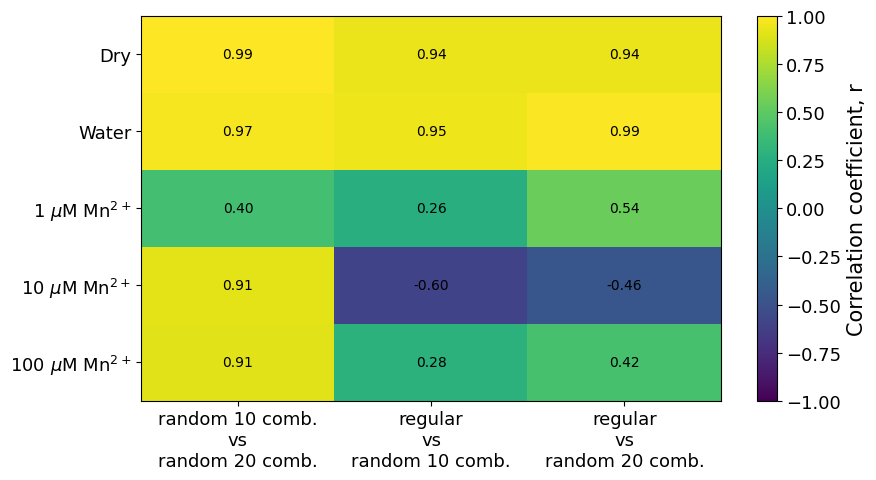

Saved heatmap: std_error_correlation_heatmap_no-title.png


In [15]:
# ============================================================
# COMPACT HEATMAP OF STD ERROR CORRELATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make comparison label
heatmap_df = correlation_table.copy()

heatmap_df["Comparison"] = (
    heatmap_df["Method 1"]
    + "\nvs\n"
    + heatmap_df["Method 2"]
)

# Create heatmap table
heatmap_data = heatmap_df.pivot_table(
    index="Variation Label",
    columns="Comparison",
    values="r"
)

# Optional: set variation order
variation_order = [
    variation_labels[v]
    for v in variations
    if variation_labels[v] in heatmap_data.index
]

heatmap_data = heatmap_data.loc[variation_order]

# ============================================================
# PLOT HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    heatmap_data,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

# Axis ticks
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(
    heatmap_data.columns,
    rotation=0,
    ha="center"
)

ax.set_yticklabels(heatmap_data.index)

# Write correlation values inside cells
 # Write correlation values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        if pd.isna(value):
            text = "NaN"
        else:
            text = f"{value:.2f}"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize=10
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation coefficient, r")

# Labels and title
# ax.set_title("Correlation of STD Error Curves Across Sampling Methods")
# ax.set_xlabel("Sampling method comparison")
# ax.set_ylabel("Sample variation")

plt.tight_layout()

output_heatmap = "std_error_correlation_heatmap_no-title.png"
plt.savefig(output_heatmap, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved heatmap: {output_heatmap}")

C:\Users\trina\AppData\Local\Temp\ipykernel_23408\3512090451.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


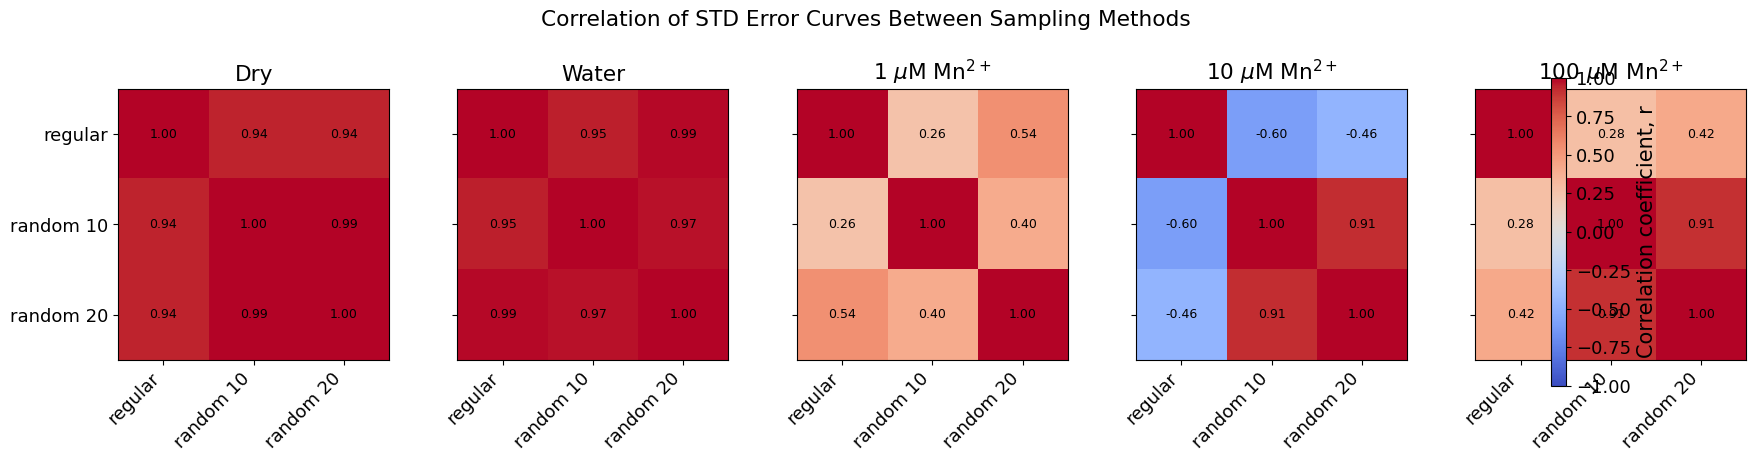

Saved: std_error_correlation_3x3_all_variations.png


In [16]:
# ============================================================
# ALL VARIATIONS IN ONE FIGURE: 3 x 3 HEATMAPS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

short_method_labels = {
    "regular": "regular",
    "random 10 comb.": "random 10",
    "random 20 comb.": "random 20"
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(variations),
    figsize=(18, 4),
    sharey=True
)

if len(variations) == 1:
    axes = [axes]

last_im = None

for ax, variation in zip(axes, variations):

    if variation not in correlation_matrices:
        ax.axis("off")
        continue

    corr_matrix = correlation_matrices[variation].copy()

    corr_matrix = corr_matrix.rename(
        index=short_method_labels,
        columns=short_method_labels
    )

    im = ax.imshow(
        corr_matrix,
        vmin=-1,
        vmax=1,
        cmap="coolwarm"
    )

    last_im = im

    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))

    ax.set_xticklabels(
        corr_matrix.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(corr_matrix.index)

    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):

            value = corr_matrix.iloc[i, j]

            if pd.isna(value):
                text = "NaN"
            else:
                text = f"{value:.2f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=9
            )

    ax.set_title(variation_labels.get(variation, variation))

# Shared colorbar
fig.colorbar(
    last_im,
    ax=axes,
    fraction=0.025,
    pad=0.04,
    label="Correlation coefficient, r"
)

fig.suptitle(
    "Correlation of STD Error Curves Between Sampling Methods",
    y=1.05
)

plt.tight_layout()

output_file = "std_error_correlation_3x3_all_variations.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {output_file}")

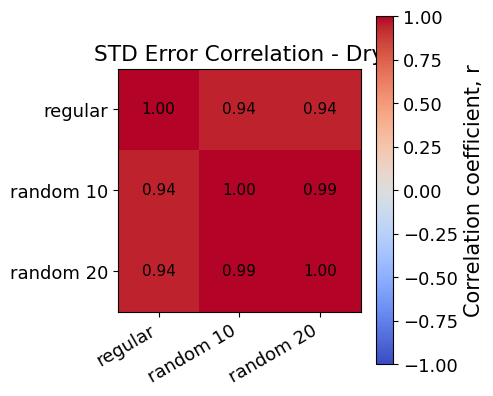

Saved: correlation_heatmaps_3x3\std_error_correlation_3x3_dry.png


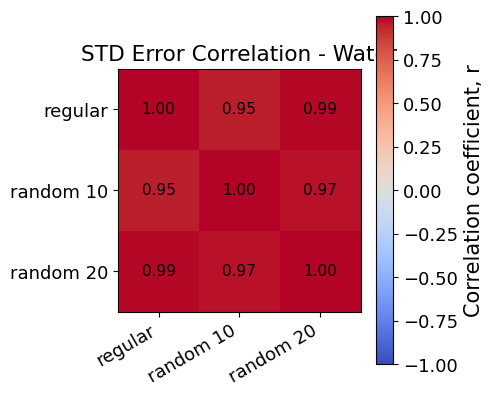

Saved: correlation_heatmaps_3x3\std_error_correlation_3x3_water.png


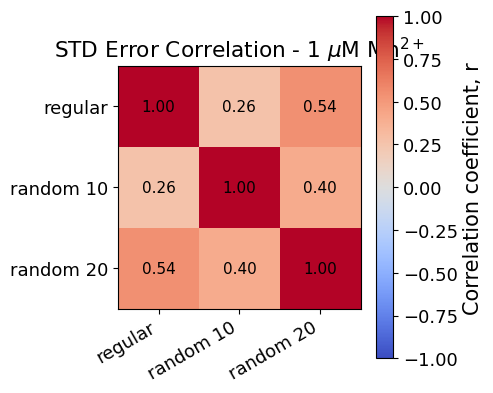

Saved: correlation_heatmaps_3x3\std_error_correlation_3x3_1_uM.png


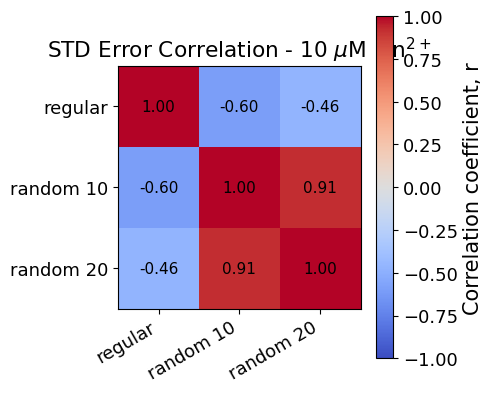

Saved: correlation_heatmaps_3x3\std_error_correlation_3x3_10_uM.png


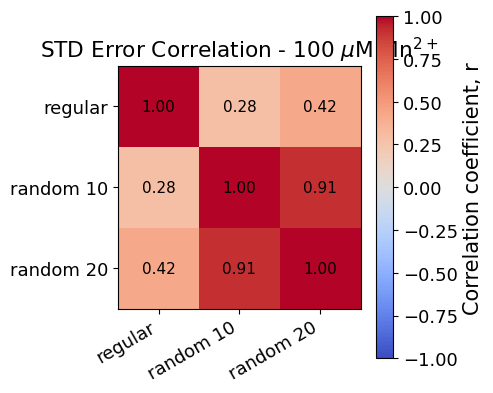

Saved: correlation_heatmaps_3x3\std_error_correlation_3x3_100_uM.png


In [17]:
# ============================================================
# 3 x 3 CORRELATION HEATMAP FOR EACH VARIATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Shorter labels for cleaner heatmap
short_method_labels = {
    "regular": "regular",
    "random 10 comb.": "random 10",
    "random 20 comb.": "random 20"
}

output_folder = "correlation_heatmaps_3x3"
os.makedirs(output_folder, exist_ok=True)

for variation in variations:

    if variation not in correlation_matrices:
        print(f"Skipped {variation}: no correlation matrix found.")
        continue

    corr_matrix = correlation_matrices[variation].copy()

    # Rename labels to make the heatmap cleaner
    corr_matrix = corr_matrix.rename(
        index=short_method_labels,
        columns=short_method_labels
    )

    fig, ax = plt.subplots(figsize=(5, 4.5))

    im = ax.imshow(
        corr_matrix,
        vmin=-1,
        vmax=1,
        cmap="coolwarm"
    )

    # Tick labels
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))

    ax.set_xticklabels(
        corr_matrix.columns,
        rotation=30,
        ha="right"
    )

    ax.set_yticklabels(corr_matrix.index)

    # Write correlation values inside cells
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):

            value = corr_matrix.iloc[i, j]

            if pd.isna(value):
                text = "NaN"
            else:
                text = f"{value:.2f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=11
            )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Correlation coefficient, r")

    # Title
    ax.set_title(
        f"STD Error Correlation - {variation_labels.get(variation, variation)}"
    )

    plt.tight_layout()

    output_file = os.path.join(
        output_folder,
        f"std_error_correlation_3x3_{variation}.png".replace(" ", "_")
    )

    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_file}")

In [4]:
import os
import re
import glob
import numpy as np
import pandas as pd

# ============================================================
# USER INPUT
# ============================================================

variation = input("Input variation name: dry/water/1 uM/10 uM/100 uM: ").strip()

valid_variations = ["dry", "water", "1 uM", "10 uM", "100 uM"]

if variation not in valid_variations:
    raise ValueError(f"Invalid variation name. Choose from: {valid_variations}")


# ============================================================
# SETTINGS
# ============================================================

signal_col = "Signal"

sampling_map = {
    "regular": {
        "data_folder": "regular",
        "sheet_single": "regular_single",
        "sheet_bi": "regular_bi"
    },
    "random10": {
        "data_folder": "random",
        "sheet_single": "random10_single",
        "sheet_bi": "random10_bi"
    },
    "random20": {
        "data_folder": "random2",
        "sheet_single": "random20_single",
        "sheet_bi": "random20_bi"
    }
}

# Number of fitting parameters
n_param_single = 3
n_param_bi = 5


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def natural_sort_key(path):
    filename = os.path.basename(path)

    return [
        int(text) if text.isdigit() else text.lower()
        for text in re.split(r"(\d+)", filename)
    ]


def find_fitting_file(variation):
    possible_files = [
        os.path.join("fitting_metrics", f"{variation}.xlsx"),
        os.path.join("fitting_metrics", f"{variation}.xls")
    ]

    for file in possible_files:
        if os.path.exists(file):
            return file

    raise FileNotFoundError(
        f"No fitting file found for '{variation}' inside fitting_metrics/"
    )


def get_excel_files(folder):
    files = glob.glob(os.path.join(folder, "*.xlsx"))
    files += glob.glob(os.path.join(folder, "*.xls"))

    return sorted(files, key=natural_sort_key)


def normalize_with_raw_range(raw, fitted):
    raw = np.asarray(raw, dtype=float)
    fitted = np.asarray(fitted, dtype=float)

    raw_min = np.nanmin(raw)
    raw_max = np.nanmax(raw)

    if raw_max == raw_min:
        return np.full_like(raw, np.nan), np.full_like(fitted, np.nan)

    raw_norm = (raw - raw_min) / (raw_max - raw_min)
    fitted_norm = (fitted - raw_min) / (raw_max - raw_min)

    return raw_norm, fitted_norm


def rmse(observed, fitted):
    observed = np.asarray(observed, dtype=float)
    fitted = np.asarray(fitted, dtype=float)

    mask = np.isfinite(observed) & np.isfinite(fitted)

    observed = observed[mask]
    fitted = fitted[mask]

    if len(observed) == 0:
        return np.nan

    return np.sqrt(np.mean((observed - fitted) ** 2))


def reduced_chi_square(observed, fitted, n_params):
    observed = np.asarray(observed, dtype=float)
    fitted = np.asarray(fitted, dtype=float)

    # Avoid division by zero or near-zero normalized fitted values
    mask = (
        np.isfinite(observed)
        & np.isfinite(fitted)
        & (np.abs(fitted) > 1e-12)
    )

    observed = observed[mask]
    fitted = fitted[mask]

    n = len(observed)
    dof = n - n_params

    if dof <= 0:
        return np.nan

    chi_square = np.sum((observed - fitted) ** 2 / np.abs(fitted))

    return chi_square / dof


def calculate_metrics_for_sampling(variation, sampling_name, info, fitting_file):
    measured_folder = os.path.join(variation, info["data_folder"])
    measured_files = get_excel_files(measured_folder)

    if len(measured_files) == 0:
        print(f"Warning: No Excel files found in {measured_folder}")

        return pd.DataFrame(
            columns=[
                "red_chi_sq_single",
                "red_chi_sq_bi",
                "RMSE_single",
                "RMSE_bi"
            ]
        )

    df_fit_single = pd.read_excel(fitting_file, sheet_name=info["sheet_single"])
    df_fit_bi = pd.read_excel(fitting_file, sheet_name=info["sheet_bi"])

    df_fit_single.columns = df_fit_single.columns.str.strip()
    df_fit_bi.columns = df_fit_bi.columns.str.strip()

    results = []

    for i, measured_file in enumerate(measured_files, start=1):
        fitted_col = f"Signal_fitted_{i}"

        if fitted_col not in df_fit_single.columns:
            print(f"Warning: {fitted_col} not found in {info['sheet_single']}. Skipping.")
            continue

        if fitted_col not in df_fit_bi.columns:
            print(f"Warning: {fitted_col} not found in {info['sheet_bi']}. Skipping.")
            continue

        df_measured = pd.read_excel(measured_file)
        df_measured.columns = df_measured.columns.str.strip()

        if signal_col not in df_measured.columns:
            print(f"Warning: Column '{signal_col}' not found in {measured_file}. Skipping.")
            continue

        y_obs = df_measured[signal_col].to_numpy(dtype=float)

        y_fit_single = df_fit_single[fitted_col].to_numpy(dtype=float)
        y_fit_bi = df_fit_bi[fitted_col].to_numpy(dtype=float)

        # Match by row order
        n_single = min(len(y_obs), len(y_fit_single))
        n_bi = min(len(y_obs), len(y_fit_bi))

        y_obs_single = y_obs[:n_single]
        y_fit_single = y_fit_single[:n_single]

        y_obs_bi = y_obs[:n_bi]
        y_fit_bi = y_fit_bi[:n_bi]

        # Normalize measured and fitted signals using measured signal range
        y_obs_single_norm, y_fit_single_norm = normalize_with_raw_range(
            y_obs_single,
            y_fit_single
        )

        y_obs_bi_norm, y_fit_bi_norm = normalize_with_raw_range(
            y_obs_bi,
            y_fit_bi
        )

        results.append({
            "red_chi_sq_single": reduced_chi_square(
                y_obs_single_norm,
                y_fit_single_norm,
                n_param_single
            ),
            "red_chi_sq_bi": reduced_chi_square(
                y_obs_bi_norm,
                y_fit_bi_norm,
                n_param_bi
            ),
            "RMSE_single": rmse(
                y_obs_single_norm,
                y_fit_single_norm
            ),
            "RMSE_bi": rmse(
                y_obs_bi_norm,
                y_fit_bi_norm
            )
        })

    return pd.DataFrame(results)


# ============================================================
# MAIN PROGRAM
# ============================================================

fitting_file = find_fitting_file(variation)

output_file = f"normalized_fit_quality_metrics_{variation}.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for sampling_name, info in sampling_map.items():
        print(f"Processing {sampling_name}...")

        df_result = calculate_metrics_for_sampling(
            variation=variation,
            sampling_name=sampling_name,
            info=info,
            fitting_file=fitting_file
        )

        df_result.to_excel(
            writer,
            sheet_name=sampling_name,
            index=False
        )

print(f"Done. Output saved as: {output_file}")

Processing regular...
Processing random10...
Processing random20...
Done. Output saved as: normalized_fit_quality_metrics_dry.xlsx


Variation       : dry
Sampling method : regular
Fitting model   : single
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
Data range      : 0.005328 to 0.985952
Fit range       : 0.147989 to 0.974310
RMSE            : 0.081762
Fit parameters  : [ 0.1479891   0.93547213 16.12014308]
Variation       : 100 uM Mn2+
Sampling method : regular
Fitting model   : single
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
Data range      : 0.040066 to 0.985902
Fit range       : 0.104871 to 1.012767
RMSE            : 0.119343
Fit parameters  : [0.10487083 1.21246877 6.91363578]
Variation       : dry
Sampling method : regular
Fitting model   : biexp
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used   

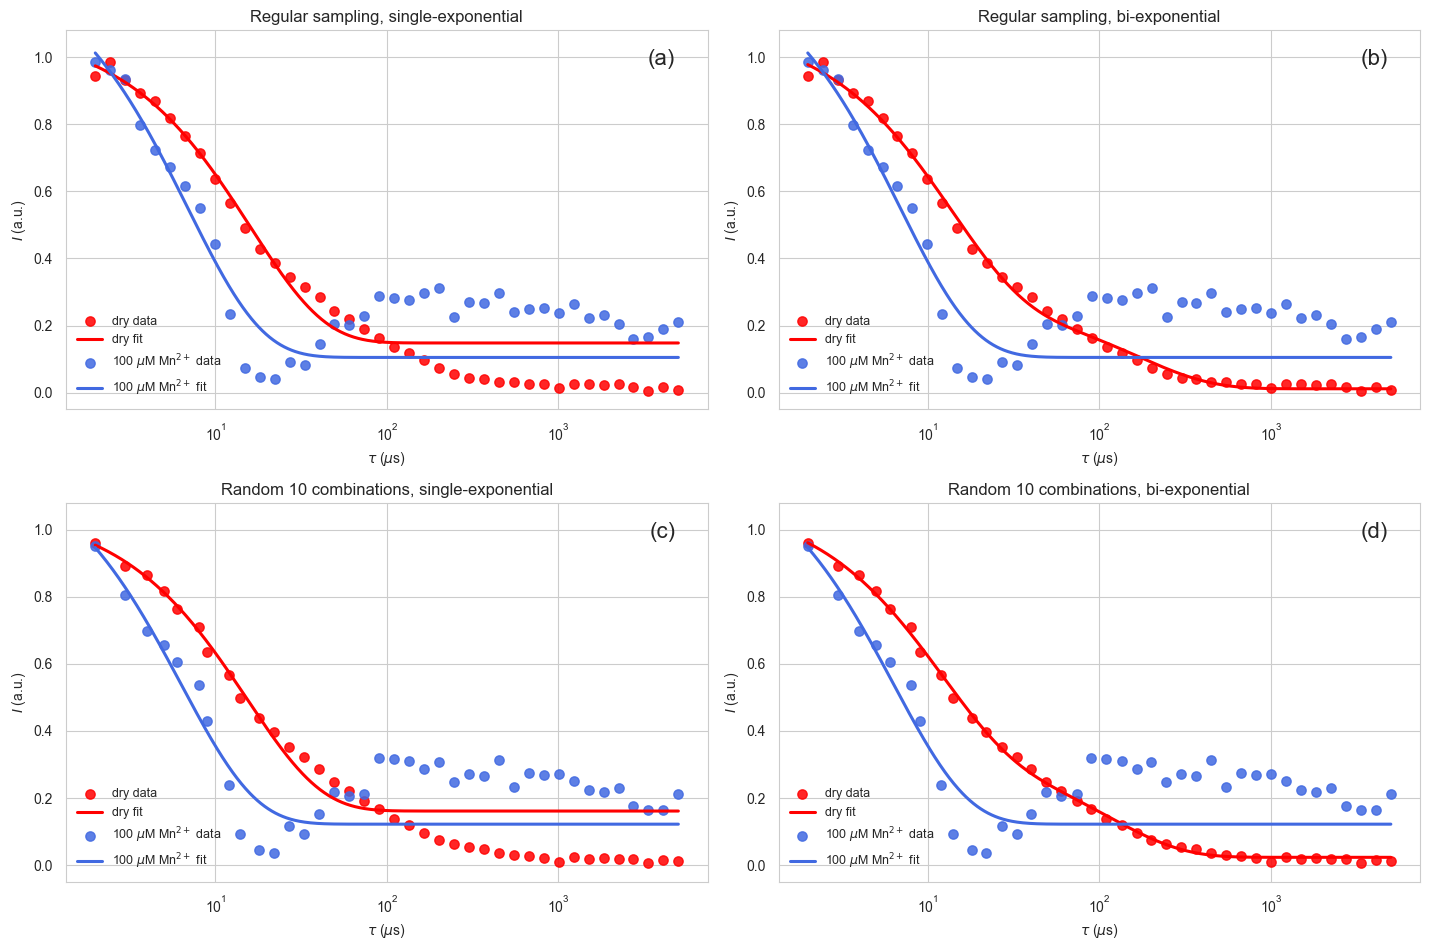


Saved refit parameters to:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\refit_parameters_from_averaged_normalized_signal.xlsx


,variation,method,model,RMSE_normalized,I0,A1,Tau1_us,A2,Tau2_us
0,dry,regular,single,0.081762,0.147989,0.935472,16.120143,NaN,NaN
1,100 uM Mn2+,regular,single,0.119343,0.104871,1.212469,6.913636,NaN,NaN
2,dry,regular,biexp,0.014665,0.011382,0.820715,13.173062,0.264777,166.499306
3,100 uM Mn2+,regular,biexp,0.119318,0.104910,0.781732,6.912897,0.430733,6.912974
4,dry,random10,single,0.092014,0.161212,0.902736,15.419398,NaN,NaN
5,100 uM Mn2+,random10,single,0.116443,0.122059,1.129824,6.352439,NaN,NaN
6,dry,random10,biexp,0.009633,0.023185,0.738892,11.180935,0.325854,114.140423
7,100 uM Mn2+,random10,biexp,0.116441,0.122062,0.612306,6.352348,0.517520,6.352368


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
import re
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = Path(r"C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old")
RECAP_FILE = Path(r"a_recap.xlsx")

PLOT_VARIATIONS = ["dry", "100 uM Mn2+"]

PANEL_CONFIG = [
    ("regular",  "single"),
    ("regular",  "biexp"),
    ("random10", "single"),
    ("random10", "biexp"),
]

# To use random 20 instead, change PANEL_CONFIG to:
# PANEL_CONFIG = [
#     ("regular",  "single"),
#     ("regular",  "biexp"),
#     ("random20", "single"),
#     ("random20", "biexp"),
# ]

SAVE_FIGURE = True
OUTPUT_NAME = "averaged_signal_refitted_curve.png"

# Set manually only if the printed signal column is wrong.
# Example:
# TAU_COLUMN = "Tau (us)"
# SIGNAL_COLUMN = "Signal"
TAU_COLUMN = None
SIGNAL_COLUMN = None

# This version refits the averaged normalized signal directly.
# a_recap.xlsx is used only as an initial guess if possible.
USE_RECAP_AS_INITIAL_GUESS = True

# ============================================================
# FOLDER AND SHEET SETTINGS
# ============================================================

VARIATIONS = {
    "dry": {
        "folder": "dry",
        "label": "dry",
    },
    "water": {
        "folder": "water",
        "label": "water",
    },
    "1 uM Mn2+": {
        "folder": "1 uM",
        "label": r"1 $\mu$M Mn$^{2+}$",
    },
    "10 uM Mn2+": {
        "folder": "10 uM",
        "label": r"10 $\mu$M Mn$^{2+}$",
    },
    "100 uM Mn2+": {
        "folder": "100 uM",
        "label": r"100 $\mu$M Mn$^{2+}$",
    },
}

METHODS = {
    "regular": {
        "folder": "regular",
        "label": "Regular sampling",
    },
    "random10": {
        "folder": "random",
        "label": "Random 10 combinations",
    },
    "random20": {
        "folder": "random2",
        "label": "Random 20 combinations",
    },
}

FIT_SHEETS = {
    ("regular",  "single"): "single",
    ("regular",  "biexp"): "biexp",
    ("random10", "single"): "single_rand",
    ("random10", "biexp"): "biexp_rand",
    ("random20", "single"): "single_rand2",
    ("random20", "biexp"): "biexp_rand2",
}

COLORS = {
    "dry": "red",
    "water": "green",
    "1 uM Mn2+": "orange",
    "10 uM Mn2+": "purple",
    "100 uM Mn2+": "royalblue",
}

MARKERS = {
    "dry": "o",
    "water": "s",
    "1 uM Mn2+": "^",
    "10 uM Mn2+": "D",
    "100 uM Mn2+": "o",
}

# ============================================================
# BASIC FUNCTIONS
# ============================================================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("µ", "u").replace("μ", "u")
    text = re.sub(r"[^a-z0-9]+", "", text)
    return text


def resolve_folder(parent, folder_hint):
    direct = parent / folder_hint

    if direct.exists():
        return direct

    target = normalize_text(folder_hint)

    for p in parent.iterdir():
        if p.is_dir() and normalize_text(p.name) == target:
            return p

    raise FileNotFoundError(f"Folder not found: {parent / folder_hint}")


def find_signal_files(variation_name, method_key):
    variation_folder = resolve_folder(BASE_DIR, VARIATIONS[variation_name]["folder"])
    method_folder = resolve_folder(variation_folder, METHODS[method_key]["folder"])

    all_files = sorted([
        p for p in method_folder.rglob("*.xlsx")
        if not p.name.startswith("~$")
    ])

    average_files = [
        p for p in all_files
        if ("average" in p.name.lower()) or ("averaged" in p.name.lower())
    ]

    files = average_files if len(average_files) > 0 else all_files

    if len(files) == 0:
        raise FileNotFoundError(f"No Excel signal files found in: {method_folder}")

    return files


def choose_tau_column(df):
    if TAU_COLUMN is not None:
        return TAU_COLUMN

    columns = list(df.columns)

    priority_names = [
        "tauus",
        "tau",
        "darktimeus",
        "darktime",
    ]

    for target in priority_names:
        for col in columns:
            if normalize_text(col) == target:
                return col

    for col in columns:
        c = normalize_text(col)
        if "tau" in c and "err" not in c and "error" not in c:
            return col

    numeric_cols = list(df.select_dtypes(include=[np.number]).columns)

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def choose_signal_column(df, tau_col):
    if SIGNAL_COLUMN is not None:
        return SIGNAL_COLUMN

    columns = list(df.columns)

    priority_names = [
        "signal",
        "signalmean",
        "meansignal",
        "signalavg",
        "averagesignal",
        "averagedsignal",
        "normalizedsignal",
        "signalnormalized",
        "ratio",
        "intensity",
        "i",
    ]

    for target in priority_names:
        for col in columns:
            if col == tau_col:
                continue
            if normalize_text(col) == target:
                return col

    for col in columns:
        if col == tau_col:
            continue

        c = normalize_text(col)

        bad_keywords = [
            "tau", "time", "err", "error", "std", "sd", "sem",
            "sigma", "uncert", "fit", "fitted", "x"
        ]

        good_keywords = [
            "signal", "ratio", "intensity", "normalized", "norm"
        ]

        if any(bad in c for bad in bad_keywords):
            continue

        if any(good in c for good in good_keywords):
            return col

    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col != tau_col
    ]

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def read_one_signal_file(file_path):
    xls = pd.ExcelFile(file_path)

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        df = df.dropna(how="all")
        df.columns = [str(c).strip() for c in df.columns]

        if df.empty:
            continue

        tau_col = choose_tau_column(df)
        signal_col = choose_signal_column(df, tau_col)

        if tau_col is None or signal_col is None:
            continue

        out = pd.DataFrame({
            "Tau_us": pd.to_numeric(df[tau_col], errors="coerce"),
            "Signal": pd.to_numeric(df[signal_col], errors="coerce"),
        })

        out = out.dropna(subset=["Tau_us", "Signal"])
        out = out[out["Tau_us"] > 0]
        out = out.sort_values("Tau_us").reset_index(drop=True)

        if len(out) > 0:
            info = {
                "file": file_path.name,
                "sheet": sheet,
                "tau_col": tau_col,
                "signal_col": signal_col,
            }

            return out, info

    raise ValueError(f"Could not detect tau and signal columns in: {file_path}")


def scale01(y):
    y = np.asarray(y, dtype=float)

    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    yrange = ymax - ymin

    if not np.isfinite(yrange) or abs(yrange) < 1e-30:
        return np.zeros_like(y)

    return (y - ymin) / yrange


def normalize_each_file_then_average(files):
    all_data = []
    first_info = None

    for source_index, file_path in enumerate(files, start=1):
        df, info = read_one_signal_file(file_path)

        if first_info is None:
            first_info = info

        tau = df["Tau_us"].to_numpy()
        signal = df["Signal"].to_numpy()

        signal_norm = scale01(signal)

        temp = pd.DataFrame({
            "Tau_us": tau,
            "Signal_norm": signal_norm,
            "source": source_index,
        })

        temp["Tau_key"] = temp["Tau_us"].round(9)
        all_data.append(temp)

    combined = pd.concat(all_data, ignore_index=True)

    averaged = combined.groupby("Tau_key", as_index=False).agg(
        Tau_us=("Tau_us", "mean"),
        Signal_mean=("Signal_norm", "mean"),
        Signal_std=("Signal_norm", "std"),
        N=("Signal_norm", "count"),
    )

    averaged["Signal_sem"] = averaged["Signal_std"] / np.sqrt(averaged["N"])
    averaged = averaged.sort_values("Tau_us").reset_index(drop=True)

    return averaged, first_info


# ============================================================
# FITTING FUNCTIONS
# ============================================================

def single_exp(tau, I0, A1, Tau1):
    return I0 + A1 * np.exp(-tau / Tau1)


def biexp(tau, I0, A1, Tau1, A2, Tau2):
    return I0 + A1 * np.exp(-tau / Tau1) + A2 * np.exp(-tau / Tau2)


def get_recap_rows(recap_df, variation_name):
    if recap_df is None:
        return pd.DataFrame()

    if "variations" not in recap_df.columns:
        return pd.DataFrame()

    target = normalize_text(variation_name)

    rows = recap_df[
        recap_df["variations"].apply(normalize_text) == target
    ].copy()

    rows = rows.reset_index(drop=True)

    return rows


def recap_initial_guess(recap_df, variation_name, model_name, y_data):
    rows = get_recap_rows(recap_df, variation_name)

    if rows.empty:
        return None

    row = rows.iloc[0]

    y0 = float(np.nanmin(y_data))
    y1 = float(np.nanmax(y_data))
    amp = y1 - y0

    try:
        if model_name == "single":
            tau_guess = float(np.nanmedian(rows["Tau1"]))
            if not np.isfinite(tau_guess) or tau_guess <= 0:
                return None

            return [y0, amp, tau_guess]

        if model_name == "biexp":
            tau1_guess = float(np.nanmedian(rows["Tau1"]))
            tau2_guess = float(np.nanmedian(rows["Tau2"]))

            if not np.isfinite(tau1_guess) or tau1_guess <= 0:
                return None
            if not np.isfinite(tau2_guess) or tau2_guess <= 0:
                return None

            tau_short = min(tau1_guess, tau2_guess)
            tau_long = max(tau1_guess, tau2_guess)

            return [y0, 0.6 * amp, tau_short, 0.4 * amp, tau_long]

    except Exception:
        return None

    return None


def default_initial_guess(tau, y, model_name):
    y = np.asarray(y, dtype=float)
    tau = np.asarray(tau, dtype=float)

    I0_guess = float(np.nanmedian(y[-5:]))
    amp_guess = float(np.nanmax(y) - I0_guess)

    if amp_guess <= 0:
        amp_guess = float(np.nanmax(y) - np.nanmin(y))

    if amp_guess <= 0:
        amp_guess = 1.0

    tau_mid = float(np.nanmedian(tau))

    if model_name == "single":
        return [I0_guess, amp_guess, tau_mid]

    if model_name == "biexp":
        return [
            I0_guess,
            0.6 * amp_guess,
            tau_mid / 3,
            0.4 * amp_guess,
            tau_mid * 3,
        ]

    raise ValueError("model_name must be 'single' or 'biexp'")


def fit_averaged_signal(tau, y, model_name, recap_df=None, variation_name=None):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(tau) & np.isfinite(y) & (tau > 0)

    tau = tau[valid]
    y = y[valid]

    order = np.argsort(tau)
    tau = tau[order]
    y = y[order]

    if model_name == "single":
        model = single_exp

        lower = [-0.20, -2.00, 0.01]
        upper = [ 1.20,  2.00, 1e6]

        p0 = None

        if USE_RECAP_AS_INITIAL_GUESS:
            p0 = recap_initial_guess(recap_df, variation_name, model_name, y)

        if p0 is None:
            p0 = default_initial_guess(tau, y, model_name)

    elif model_name == "biexp":
        model = biexp

        lower = [-0.20, -2.00, 0.01, -2.00, 0.01]
        upper = [ 1.20,  2.00, 1e6,  2.00, 1e6]

        p0 = None

        if USE_RECAP_AS_INITIAL_GUESS:
            p0 = recap_initial_guess(recap_df, variation_name, model_name, y)

        if p0 is None:
            p0 = default_initial_guess(tau, y, model_name)

    else:
        raise ValueError("model_name must be 'single' or 'biexp'")

    # Make sure initial guess is inside bounds
    p0 = np.asarray(p0, dtype=float)
    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)
    p0 = np.maximum(p0, lower_arr + 1e-12)
    p0 = np.minimum(p0, upper_arr - 1e-12)

    # Weighting:
    # To avoid the fit being dominated by the long-tau plateau,
    # use mild weighting that gives early decay region reasonable influence.
    sigma = np.sqrt(tau / np.nanmin(tau))
    sigma = sigma / np.nanmin(sigma)

    try:
        popt, pcov = curve_fit(
            model,
            tau,
            y,
            p0=p0,
            bounds=(lower, upper),
            sigma=sigma,
            absolute_sigma=False,
            maxfev=200000,
        )

    except Exception as e:
        print(f"Warning: fitting failed for {variation_name}, {model_name}. Error: {e}")
        print("Using initial guess instead.")
        popt = p0
        pcov = None

    y_pred = model(tau, *popt)

    rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

    return popt, rmse


def evaluate_model(tau, params, model_name):
    if model_name == "single":
        return single_exp(tau, *params)

    if model_name == "biexp":
        return biexp(tau, *params)

    raise ValueError("model_name must be 'single' or 'biexp'")


# ============================================================
# LOAD RECAP FILE
# ============================================================

recap = {}

for key, sheet_name in FIT_SHEETS.items():
    try:
        df = pd.read_excel(RECAP_FILE, sheet_name=sheet_name)
        df.columns = [str(c).strip() for c in df.columns]
        recap[key] = df
    except Exception:
        recap[key] = None
        print(f"Warning: could not read sheet {sheet_name} from {RECAP_FILE}")


# ============================================================
# MAKE FIGURE
# ============================================================

n_panels = len(PANEL_CONFIG)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(7.2 * ncols, 4.8 * nrows),
    squeeze=False
)

axes = axes.flatten()
panel_letters = "abcdefghijklmnopqrstuvwxyz"

fit_summary = []

for ax_idx, (method_key, model_name) in enumerate(PANEL_CONFIG):
    ax = axes[ax_idx]

    method_label = METHODS[method_key]["label"]
    model_label = "single-exponential" if model_name == "single" else "bi-exponential"

    for variation_name in PLOT_VARIATIONS:
        files = find_signal_files(variation_name, method_key)

        avg_df, detected_info = normalize_each_file_then_average(files)

        tau_data = avg_df["Tau_us"].to_numpy()
        signal_plot = avg_df["Signal_mean"].to_numpy()

        recap_df = recap.get((method_key, model_name), None)

        params, rmse = fit_averaged_signal(
            tau=tau_data,
            y=signal_plot,
            model_name=model_name,
            recap_df=recap_df,
            variation_name=variation_name,
        )

        tau_fit = np.logspace(
            np.log10(np.nanmin(tau_data)),
            np.log10(np.nanmax(tau_data)),
            800
        )

        fit_plot = evaluate_model(tau_fit, params, model_name)

        color = COLORS.get(variation_name, None)
        marker = MARKERS.get(variation_name, "o")

        ax.scatter(
            tau_data,
            signal_plot,
            s=45,
            marker=marker,
            color=color,
            alpha=0.85,
            label=f"{VARIATIONS[variation_name]['label']} data"
        )

        ax.plot(
            tau_fit,
            fit_plot,
            linewidth=2.2,
            color=color,
            label=f"{VARIATIONS[variation_name]['label']} fit"
        )

        print("=" * 75)
        print(f"Variation       : {variation_name}")
        print(f"Sampling method : {method_key}")
        print(f"Fitting model   : {model_name}")
        print(f"Files averaged  : {len(files)}")
        print(f"Example file    : {detected_info['file']}")
        print(f"Sheet used      : {detected_info['sheet']}")
        print(f"Tau column      : {detected_info['tau_col']}")
        print(f"Signal column   : {detected_info['signal_col']}")
        print(f"Data range      : {np.nanmin(signal_plot):.6f} to {np.nanmax(signal_plot):.6f}")
        print(f"Fit range       : {np.nanmin(fit_plot):.6f} to {np.nanmax(fit_plot):.6f}")
        print(f"RMSE            : {rmse:.6f}")
        print(f"Fit parameters  : {params}")

        row = {
            "variation": variation_name,
            "method": method_key,
            "model": model_name,
            "RMSE_normalized": rmse,
        }

        if model_name == "single":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
            })

        if model_name == "biexp":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
                "A2": params[3],
                "Tau2_us": params[4],
            })

        fit_summary.append(row)

    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.08)

    ax.set_xlabel(r"$\tau$ ($\mu$s)")
    ax.set_ylabel(r"$I$ (a.u.)")
    ax.set_title(f"{method_label}, {model_label}")

    ax.text(
        0.95,
        0.95,
        f"({panel_letters[ax_idx]})",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=16
    )

    ax.tick_params(axis="both", which="major", length=6, width=1)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8)
    ax.legend(frameon=False, fontsize=9)

for j in range(n_panels, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

if SAVE_FIGURE:
    out_path = BASE_DIR / OUTPUT_NAME
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"\nSaved figure to:\n{out_path}")

plt.show()

# ============================================================
# SAVE REFIT PARAMETERS
# ============================================================

fit_summary_df = pd.DataFrame(fit_summary)

summary_path = BASE_DIR / "refit_parameters_from_averaged_normalized_signal.xlsx"
fit_summary_df.to_excel(summary_path, index=False)

print(f"\nSaved refit parameters to:\n{summary_path}")
display(fit_summary_df)

# Relaxation curve

Variation       : dry
Sampling method : regular
Fitting model   : single
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
Data range      : 0.005328 to 0.985952
Fit range       : 0.147989 to 0.974310
RMSE            : 0.081762
Fit parameters  : [ 0.1479891   0.93547213 16.12014308]
Variation       : 100 uM Mn2+
Sampling method : regular
Fitting model   : single
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
Data range      : 0.040066 to 0.985902
Fit range       : 0.104871 to 1.012767
RMSE            : 0.119343
Fit parameters  : [0.10487083 1.21246877 6.91363578]
Variation       : dry
Sampling method : regular
Fitting model   : biexp
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used   

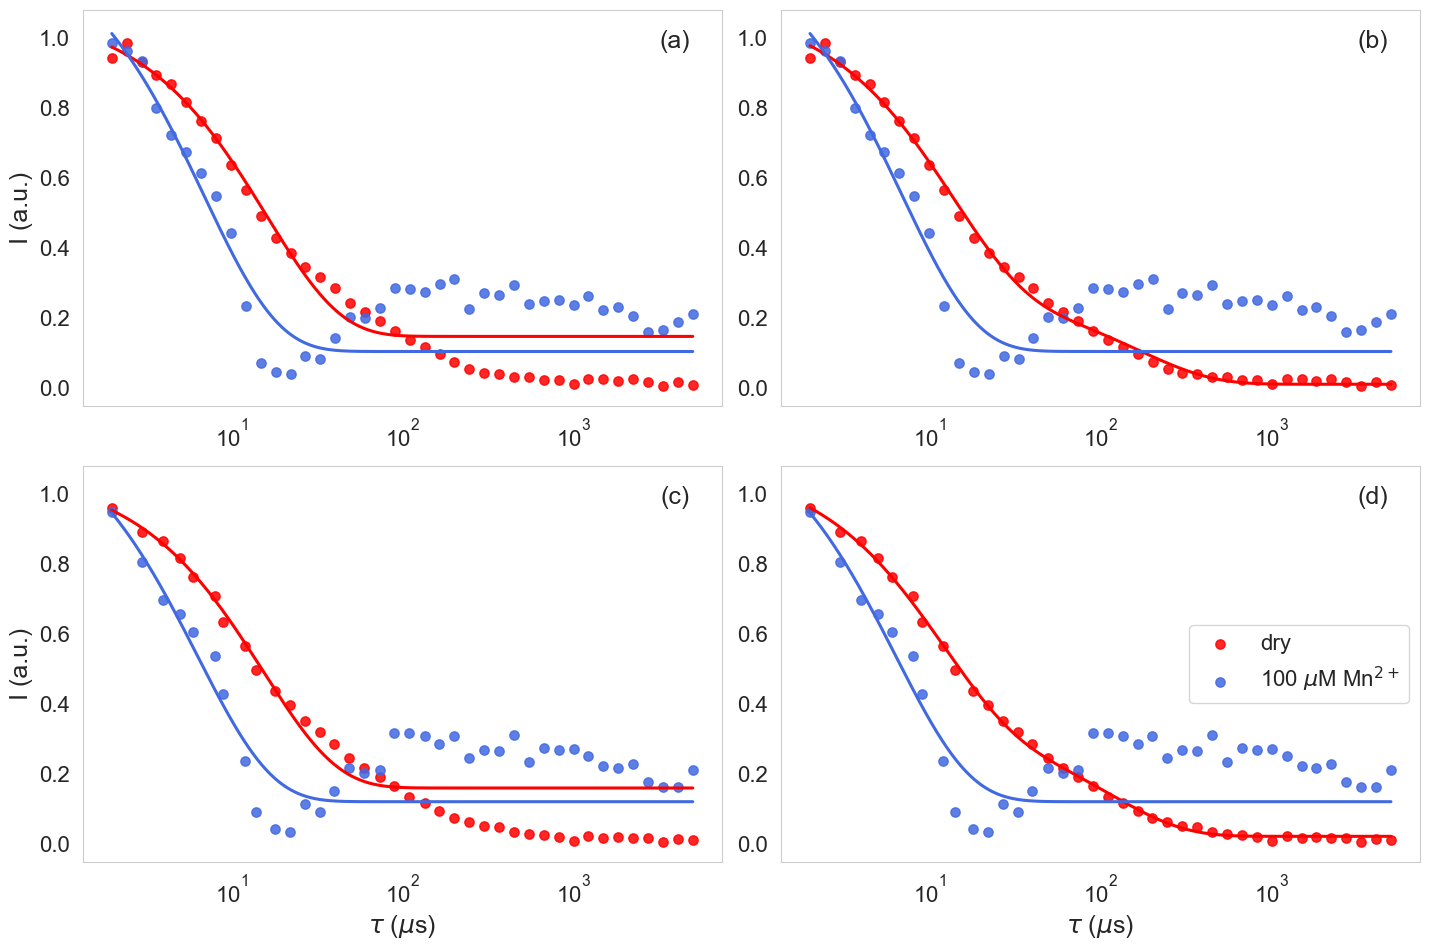


Saved refit parameters to:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\refit_parameters_from_averaged_normalized_signal.xlsx


,variation,method,model,RMSE_normalized,I0,A1,Tau1_us,A2,Tau2_us
0,dry,regular,single,0.081762,0.147989,0.935472,16.120143,NaN,NaN
1,100 uM Mn2+,regular,single,0.119343,0.104871,1.212469,6.913636,NaN,NaN
2,dry,regular,biexp,0.014665,0.011382,0.820715,13.173062,0.264777,166.499306
3,100 uM Mn2+,regular,biexp,0.119318,0.104910,0.781732,6.912897,0.430733,6.912974
4,dry,random10,single,0.092014,0.161212,0.902736,15.419398,NaN,NaN
5,100 uM Mn2+,random10,single,0.116443,0.122059,1.129824,6.352439,NaN,NaN
6,dry,random10,biexp,0.009633,0.023185,0.738892,11.180935,0.325854,114.140423
7,100 uM Mn2+,random10,biexp,0.116441,0.122062,0.612306,6.352348,0.517520,6.352368


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
import re
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = Path(r"C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old")
RECAP_FILE = Path(r"a_recap.xlsx")

PLOT_VARIATIONS = ["dry", "100 uM Mn2+"]

PANEL_CONFIG = [
    ("regular",  "single"),
    ("regular",  "biexp"),
    ("random10", "single"),
    ("random10", "biexp"),
]

# To use random 20 instead, change PANEL_CONFIG to:
# PANEL_CONFIG = [
#     ("regular",  "single"),
#     ("regular",  "biexp"),
#     ("random20", "single"),
#     ("random20", "biexp"),
# ]

SAVE_FIGURE = True
OUTPUT_NAME = "TA-graphs-fitting_dry_100uM.png"

# Set manually only if the printed signal column is wrong.
# Example:
# TAU_COLUMN = "Tau (us)"
# SIGNAL_COLUMN = "Signal"
TAU_COLUMN = None
SIGNAL_COLUMN = None

# This version refits the averaged normalized signal directly.
# a_recap.xlsx is used only as an initial guess if possible.
USE_RECAP_AS_INITIAL_GUESS = True

# ============================================================
# FOLDER AND SHEET SETTINGS
# ============================================================

VARIATIONS = {
    "dry": {
        "folder": "dry",
        "label": "dry",
    },
    "water": {
        "folder": "water",
        "label": "water",
    },
    "1 uM Mn2+": {
        "folder": "1 uM",
        "label": r"1 $\mu$M Mn$^{2+}$",
    },
    "10 uM Mn2+": {
        "folder": "10 uM",
        "label": r"10 $\mu$M Mn$^{2+}$",
    },
    "100 uM Mn2+": {
        "folder": "100 uM",
        "label": r"100 $\mu$M Mn$^{2+}$",
    },
}

METHODS = {
    "regular": {
        "folder": "regular",
        "label": "Regular sampling",
    },
    "random10": {
        "folder": "random",
        "label": "Random 10 combinations",
    },
    "random20": {
        "folder": "random2",
        "label": "Random 20 combinations",
    },
}

FIT_SHEETS = {
    ("regular",  "single"): "single",
    ("regular",  "biexp"): "biexp",
    ("random10", "single"): "single_rand",
    ("random10", "biexp"): "biexp_rand",
    ("random20", "single"): "single_rand2",
    ("random20", "biexp"): "biexp_rand2",
}

COLORS = {
    "dry": "red",
    "water": "green",
    "1 uM Mn2+": "orange",
    "10 uM Mn2+": "purple",
    "100 uM Mn2+": "royalblue",
}

MARKERS = {
    "dry": "o",
    "water": "s",
    "1 uM Mn2+": "^",
    "10 uM Mn2+": "D",
    "100 uM Mn2+": "o",
}

# ============================================================
# BASIC FUNCTIONS
# ============================================================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("µ", "u").replace("μ", "u")
    text = re.sub(r"[^a-z0-9]+", "", text)
    return text


def resolve_folder(parent, folder_hint):
    direct = parent / folder_hint

    if direct.exists():
        return direct

    target = normalize_text(folder_hint)

    for p in parent.iterdir():
        if p.is_dir() and normalize_text(p.name) == target:
            return p

    raise FileNotFoundError(f"Folder not found: {parent / folder_hint}")


def find_signal_files(variation_name, method_key):
    variation_folder = resolve_folder(BASE_DIR, VARIATIONS[variation_name]["folder"])
    method_folder = resolve_folder(variation_folder, METHODS[method_key]["folder"])

    all_files = sorted([
        p for p in method_folder.rglob("*.xlsx")
        if not p.name.startswith("~$")
    ])

    average_files = [
        p for p in all_files
        if ("average" in p.name.lower()) or ("averaged" in p.name.lower())
    ]

    files = average_files if len(average_files) > 0 else all_files

    if len(files) == 0:
        raise FileNotFoundError(f"No Excel signal files found in: {method_folder}")

    return files


def choose_tau_column(df):
    if TAU_COLUMN is not None:
        return TAU_COLUMN

    columns = list(df.columns)

    priority_names = [
        "tauus",
        "tau",
        "darktimeus",
        "darktime",
    ]

    for target in priority_names:
        for col in columns:
            if normalize_text(col) == target:
                return col

    for col in columns:
        c = normalize_text(col)
        if "tau" in c and "err" not in c and "error" not in c:
            return col

    numeric_cols = list(df.select_dtypes(include=[np.number]).columns)

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def choose_signal_column(df, tau_col):
    if SIGNAL_COLUMN is not None:
        return SIGNAL_COLUMN

    columns = list(df.columns)

    priority_names = [
        "signal",
        "signalmean",
        "meansignal",
        "signalavg",
        "averagesignal",
        "averagedsignal",
        "normalizedsignal",
        "signalnormalized",
        "ratio",
        "intensity",
        "i",
    ]

    for target in priority_names:
        for col in columns:
            if col == tau_col:
                continue
            if normalize_text(col) == target:
                return col

    for col in columns:
        if col == tau_col:
            continue

        c = normalize_text(col)

        bad_keywords = [
            "tau", "time", "err", "error", "std", "sd", "sem",
            "sigma", "uncert", "fit", "fitted", "x"
        ]

        good_keywords = [
            "signal", "ratio", "intensity", "normalized", "norm"
        ]

        if any(bad in c for bad in bad_keywords):
            continue

        if any(good in c for good in good_keywords):
            return col

    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col != tau_col
    ]

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def read_one_signal_file(file_path):
    xls = pd.ExcelFile(file_path)

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        df = df.dropna(how="all")
        df.columns = [str(c).strip() for c in df.columns]

        if df.empty:
            continue

        tau_col = choose_tau_column(df)
        signal_col = choose_signal_column(df, tau_col)

        if tau_col is None or signal_col is None:
            continue

        out = pd.DataFrame({
            "Tau_us": pd.to_numeric(df[tau_col], errors="coerce"),
            "Signal": pd.to_numeric(df[signal_col], errors="coerce"),
        })

        out = out.dropna(subset=["Tau_us", "Signal"])
        out = out[out["Tau_us"] > 0]
        out = out.sort_values("Tau_us").reset_index(drop=True)

        if len(out) > 0:
            info = {
                "file": file_path.name,
                "sheet": sheet,
                "tau_col": tau_col,
                "signal_col": signal_col,
            }

            return out, info

    raise ValueError(f"Could not detect tau and signal columns in: {file_path}")


def scale01(y):
    y = np.asarray(y, dtype=float)

    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    yrange = ymax - ymin

    if not np.isfinite(yrange) or abs(yrange) < 1e-30:
        return np.zeros_like(y)

    return (y - ymin) / yrange


def normalize_each_file_then_average(files):
    all_data = []
    first_info = None

    for source_index, file_path in enumerate(files, start=1):
        df, info = read_one_signal_file(file_path)

        if first_info is None:
            first_info = info

        tau = df["Tau_us"].to_numpy()
        signal = df["Signal"].to_numpy()

        signal_norm = scale01(signal)

        temp = pd.DataFrame({
            "Tau_us": tau,
            "Signal_norm": signal_norm,
            "source": source_index,
        })

        temp["Tau_key"] = temp["Tau_us"].round(9)
        all_data.append(temp)

    combined = pd.concat(all_data, ignore_index=True)

    averaged = combined.groupby("Tau_key", as_index=False).agg(
        Tau_us=("Tau_us", "mean"),
        Signal_mean=("Signal_norm", "mean"),
        Signal_std=("Signal_norm", "std"),
        N=("Signal_norm", "count"),
    )

    averaged["Signal_sem"] = averaged["Signal_std"] / np.sqrt(averaged["N"])
    averaged = averaged.sort_values("Tau_us").reset_index(drop=True)

    return averaged, first_info


# ============================================================
# FITTING FUNCTIONS
# ============================================================

def single_exp(tau, I0, A1, Tau1):
    return I0 + A1 * np.exp(-tau / Tau1)


def biexp(tau, I0, A1, Tau1, A2, Tau2):
    return I0 + A1 * np.exp(-tau / Tau1) + A2 * np.exp(-tau / Tau2)


def get_recap_rows(recap_df, variation_name):
    if recap_df is None:
        return pd.DataFrame()

    if "variations" not in recap_df.columns:
        return pd.DataFrame()

    target = normalize_text(variation_name)

    rows = recap_df[
        recap_df["variations"].apply(normalize_text) == target
    ].copy()

    rows = rows.reset_index(drop=True)

    return rows


def recap_initial_guess(recap_df, variation_name, model_name, y_data):
    rows = get_recap_rows(recap_df, variation_name)

    if rows.empty:
        return None

    row = rows.iloc[0]

    y0 = float(np.nanmin(y_data))
    y1 = float(np.nanmax(y_data))
    amp = y1 - y0

    try:
        if model_name == "single":
            tau_guess = float(np.nanmedian(rows["Tau1"]))
            if not np.isfinite(tau_guess) or tau_guess <= 0:
                return None

            return [y0, amp, tau_guess]

        if model_name == "biexp":
            tau1_guess = float(np.nanmedian(rows["Tau1"]))
            tau2_guess = float(np.nanmedian(rows["Tau2"]))

            if not np.isfinite(tau1_guess) or tau1_guess <= 0:
                return None
            if not np.isfinite(tau2_guess) or tau2_guess <= 0:
                return None

            tau_short = min(tau1_guess, tau2_guess)
            tau_long = max(tau1_guess, tau2_guess)

            return [y0, 0.6 * amp, tau_short, 0.4 * amp, tau_long]

    except Exception:
        return None

    return None


def default_initial_guess(tau, y, model_name):
    y = np.asarray(y, dtype=float)
    tau = np.asarray(tau, dtype=float)

    I0_guess = float(np.nanmedian(y[-5:]))
    amp_guess = float(np.nanmax(y) - I0_guess)

    if amp_guess <= 0:
        amp_guess = float(np.nanmax(y) - np.nanmin(y))

    if amp_guess <= 0:
        amp_guess = 1.0

    tau_mid = float(np.nanmedian(tau))

    if model_name == "single":
        return [I0_guess, amp_guess, tau_mid]

    if model_name == "biexp":
        return [
            I0_guess,
            0.6 * amp_guess,
            tau_mid / 3,
            0.4 * amp_guess,
            tau_mid * 3,
        ]

    raise ValueError("model_name must be 'single' or 'biexp'")


def fit_averaged_signal(tau, y, model_name, recap_df=None, variation_name=None):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(tau) & np.isfinite(y) & (tau > 0)

    tau = tau[valid]
    y = y[valid]

    order = np.argsort(tau)
    tau = tau[order]
    y = y[order]

    if model_name == "single":
        model = single_exp

        lower = [-0.20, -2.00, 0.01]
        upper = [ 1.20,  2.00, 1e6]

        p0 = None

        if USE_RECAP_AS_INITIAL_GUESS:
            p0 = recap_initial_guess(recap_df, variation_name, model_name, y)

        if p0 is None:
            p0 = default_initial_guess(tau, y, model_name)

    elif model_name == "biexp":
        model = biexp

        lower = [-0.20, -2.00, 0.01, -2.00, 0.01]
        upper = [ 1.20,  2.00, 1e6,  2.00, 1e6]

        p0 = None

        if USE_RECAP_AS_INITIAL_GUESS:
            p0 = recap_initial_guess(recap_df, variation_name, model_name, y)

        if p0 is None:
            p0 = default_initial_guess(tau, y, model_name)

    else:
        raise ValueError("model_name must be 'single' or 'biexp'")

    # Make sure initial guess is inside bounds
    p0 = np.asarray(p0, dtype=float)
    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)
    p0 = np.maximum(p0, lower_arr + 1e-12)
    p0 = np.minimum(p0, upper_arr - 1e-12)

    # Weighting:
    # To avoid the fit being dominated by the long-tau plateau,
    # use mild weighting that gives early decay region reasonable influence.
    sigma = np.sqrt(tau / np.nanmin(tau))
    sigma = sigma / np.nanmin(sigma)

    try:
        popt, pcov = curve_fit(
            model,
            tau,
            y,
            p0=p0,
            bounds=(lower, upper),
            sigma=sigma,
            absolute_sigma=False,
            maxfev=200000,
        )

    except Exception as e:
        print(f"Warning: fitting failed for {variation_name}, {model_name}. Error: {e}")
        print("Using initial guess instead.")
        popt = p0
        pcov = None

    y_pred = model(tau, *popt)

    rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

    return popt, rmse


def evaluate_model(tau, params, model_name):
    if model_name == "single":
        return single_exp(tau, *params)

    if model_name == "biexp":
        return biexp(tau, *params)

    raise ValueError("model_name must be 'single' or 'biexp'")


# ============================================================
# LOAD RECAP FILE
# ============================================================

recap = {}

for key, sheet_name in FIT_SHEETS.items():
    try:
        df = pd.read_excel(RECAP_FILE, sheet_name=sheet_name)
        df.columns = [str(c).strip() for c in df.columns]
        recap[key] = df
    except Exception:
        recap[key] = None
        print(f"Warning: could not read sheet {sheet_name} from {RECAP_FILE}")


# ============================================================
# MAKE FIGURE
# ============================================================

n_panels = len(PANEL_CONFIG)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(7.2 * ncols, 4.8 * nrows),
    squeeze=False
)

axes = axes.flatten()
panel_letters = "abcdefghijklmnopqrstuvwxyz"

fit_summary = []

for ax_idx, (method_key, model_name) in enumerate(PANEL_CONFIG):
    ax = axes[ax_idx]

    method_label = METHODS[method_key]["label"]
    model_label = "single-exponential" if model_name == "single" else "bi-exponential"

    for variation_name in PLOT_VARIATIONS:
        files = find_signal_files(variation_name, method_key)

        avg_df, detected_info = normalize_each_file_then_average(files)

        tau_data = avg_df["Tau_us"].to_numpy()
        signal_plot = avg_df["Signal_mean"].to_numpy()

        recap_df = recap.get((method_key, model_name), None)

        params, rmse = fit_averaged_signal(
            tau=tau_data,
            y=signal_plot,
            model_name=model_name,
            recap_df=recap_df,
            variation_name=variation_name,
        )

        tau_fit = np.logspace(
            np.log10(np.nanmin(tau_data)),
            np.log10(np.nanmax(tau_data)),
            800
        )

        fit_plot = evaluate_model(tau_fit, params, model_name)

        color = COLORS.get(variation_name, None)
        marker = MARKERS.get(variation_name, "o")

        ax.grid(False)
        
        ax.scatter(
            tau_data,
            signal_plot,
            s=45,
            marker=marker,
            color=color,
            alpha=0.85,
            label=f"{VARIATIONS[variation_name]['label']}"
        )

        ax.plot(
            tau_fit,
            fit_plot,
            linewidth=2.2,
            color=color,
            # label=f"{VARIATIONS[variation_name]['label']} fit"
        )

        print("=" * 75)
        print(f"Variation       : {variation_name}")
        print(f"Sampling method : {method_key}")
        print(f"Fitting model   : {model_name}")
        print(f"Files averaged  : {len(files)}")
        print(f"Example file    : {detected_info['file']}")
        print(f"Sheet used      : {detected_info['sheet']}")
        print(f"Tau column      : {detected_info['tau_col']}")
        print(f"Signal column   : {detected_info['signal_col']}")
        print(f"Data range      : {np.nanmin(signal_plot):.6f} to {np.nanmax(signal_plot):.6f}")
        print(f"Fit range       : {np.nanmin(fit_plot):.6f} to {np.nanmax(fit_plot):.6f}")
        print(f"RMSE            : {rmse:.6f}")
        print(f"Fit parameters  : {params}")

        row = {
            "variation": variation_name,
            "method": method_key,
            "model": model_name,
            "RMSE_normalized": rmse,
        }

        if model_name == "single":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
            })

        if model_name == "biexp":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
                "A2": params[3],
                "Tau2_us": params[4],
            })

        fit_summary.append(row)

    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.08)

    if ax_idx == 2 or ax_idx == 3:
        ax.set_xlabel(r"$\tau$ ($\mu$s)",fontsize=18)
    
    if ax_idx == 0 or ax_idx == 2:
        ax.set_ylabel(r"I (a.u.)",fontsize=18)
    # ax.set_title(f"{method_label}, {model_label}") #  RELAXATION CURVE TITLE

    ax.text(
        0.95,
        0.95,
        f"({panel_letters[ax_idx]})",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=18
    )

    ax.tick_params(axis="both", which="major", length=6, width=1,labelsize=16)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8,labelsize=16)
    
    if ax_idx == 3:
        ax.legend(frameon=True, fontsize=16, loc="center right")

for j in range(n_panels, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

if SAVE_FIGURE:
    out_path = f"C:/Users/trina/UGM/OneDrive - UGM 365/A - TA/A - DATA/graphs/{OUTPUT_NAME}"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"\nSaved figure to:\n{out_path}")

plt.show()

# ============================================================
# SAVE REFIT PARAMETERS
# ============================================================

fit_summary_df = pd.DataFrame(fit_summary)

summary_path = BASE_DIR / "refit_parameters_from_averaged_normalized_signal.xlsx"
fit_summary_df.to_excel(summary_path, index=False)

print(f"\nSaved refit parameters to:\n{summary_path}")
display(fit_summary_df)

## 1

Variation       : dry
Sampling method : regular
Fitting model   : single
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
Data range      : 0.005328 to 0.985952
Fit range       : 0.147989 to 0.974310
RMSE            : 0.081762
Fit parameters  : [ 0.1479891   0.93547213 16.12014308]


C:\Users\trina\AppData\Local\Temp\ipykernel_56156\4128180944.py:670: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=True, fontsize=13, loc="best")



Saved figure to:
C:/Users/trina/UGM/OneDrive - UGM 365/A - TA/A - DATA/graphs/TA-graphs-fitting_dry_100uM.png


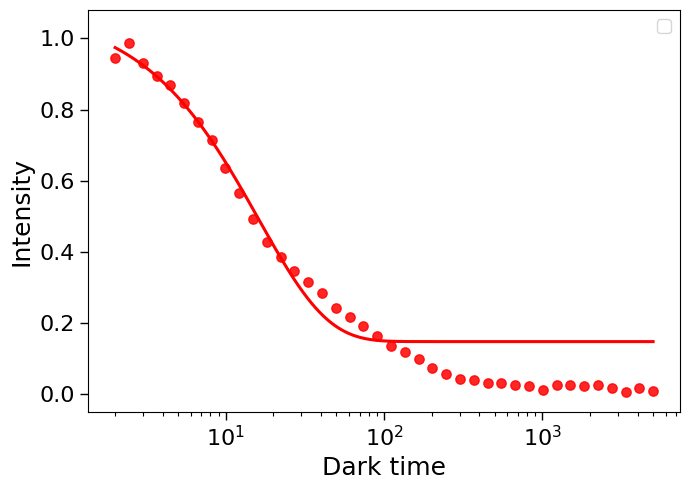


Saved refit parameters to:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\refit_parameters_from_averaged_normalized_signal.xlsx


,variation,method,model,RMSE_normalized,I0,A1,Tau1_us
0,dry,regular,single,0.081762,0.147989,0.935472,16.120143


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
import re
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = Path(r"C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old")
RECAP_FILE = Path(r"a_recap.xlsx")

PLOT_VARIATIONS = ["dry"]

PANEL_CONFIG = [
    ("regular", "single"),
]


SAVE_FIGURE = True
OUTPUT_NAME = "TA-graphs-fitting_dry_100uM.png"

# Set manually only if the printed signal column is wrong.
# Example:
# TAU_COLUMN = "Tau (us)"
# SIGNAL_COLUMN = "Signal"
TAU_COLUMN = None
SIGNAL_COLUMN = None

# This version refits the averaged normalized signal directly.
# a_recap.xlsx is used only as an initial guess if possible.
USE_RECAP_AS_INITIAL_GUESS = True

# ============================================================
# FOLDER AND SHEET SETTINGS
# ============================================================

VARIATIONS = {
    "dry": {
        "folder": "dry",
        "label": "dry",
    },
    "water": {
        "folder": "water",
        "label": "water",
    },
    "1 uM Mn2+": {
        "folder": "1 uM",
        "label": r"1 $\mu$M Mn$^{2+}$",
    },
    "10 uM Mn2+": {
        "folder": "10 uM",
        "label": r"10 $\mu$M Mn$^{2+}$",
    },
    "100 uM Mn2+": {
        "folder": "100 uM",
        "label": r"100 $\mu$M Mn$^{2+}$",
    },
}

METHODS = {
    "regular": {
        "folder": "regular",
        "label": "Regular sampling",
    },
    "random10": {
        "folder": "random",
        "label": "Random 10 combinations",
    },
    "random20": {
        "folder": "random2",
        "label": "Random 20 combinations",
    },
}

FIT_SHEETS = {
    ("regular",  "single"): "single",
    ("regular",  "biexp"): "biexp",
    ("random10", "single"): "single_rand",
    ("random10", "biexp"): "biexp_rand",
    ("random20", "single"): "single_rand2",
    ("random20", "biexp"): "biexp_rand2",
}

COLORS = {
    "dry": "red",
    "water": "green",
    "1 uM Mn2+": "orange",
    "10 uM Mn2+": "purple",
    "100 uM Mn2+": "royalblue",
}

MARKERS = {
    "dry": "o",
    "water": "s",
    "1 uM Mn2+": "^",
    "10 uM Mn2+": "D",
    "100 uM Mn2+": "o",
}

# ============================================================
# BASIC FUNCTIONS
# ============================================================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("µ", "u").replace("μ", "u")
    text = re.sub(r"[^a-z0-9]+", "", text)
    return text


def resolve_folder(parent, folder_hint):
    direct = parent / folder_hint

    if direct.exists():
        return direct

    target = normalize_text(folder_hint)

    for p in parent.iterdir():
        if p.is_dir() and normalize_text(p.name) == target:
            return p

    raise FileNotFoundError(f"Folder not found: {parent / folder_hint}")


def find_signal_files(variation_name, method_key):
    variation_folder = resolve_folder(BASE_DIR, VARIATIONS[variation_name]["folder"])
    method_folder = resolve_folder(variation_folder, METHODS[method_key]["folder"])

    all_files = sorted([
        p for p in method_folder.rglob("*.xlsx")
        if not p.name.startswith("~$")
    ])

    average_files = [
        p for p in all_files
        if ("average" in p.name.lower()) or ("averaged" in p.name.lower())
    ]

    files = average_files if len(average_files) > 0 else all_files

    if len(files) == 0:
        raise FileNotFoundError(f"No Excel signal files found in: {method_folder}")

    return files


def choose_tau_column(df):
    if TAU_COLUMN is not None:
        return TAU_COLUMN

    columns = list(df.columns)

    priority_names = [
        "tauus",
        "tau",
        "darktimeus",
        "darktime",
    ]

    for target in priority_names:
        for col in columns:
            if normalize_text(col) == target:
                return col

    for col in columns:
        c = normalize_text(col)
        if "tau" in c and "err" not in c and "error" not in c:
            return col

    numeric_cols = list(df.select_dtypes(include=[np.number]).columns)

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def choose_signal_column(df, tau_col):
    if SIGNAL_COLUMN is not None:
        return SIGNAL_COLUMN

    columns = list(df.columns)

    priority_names = [
        "signal",
        "signalmean",
        "meansignal",
        "signalavg",
        "averagesignal",
        "averagedsignal",
        "normalizedsignal",
        "signalnormalized",
        "ratio",
        "intensity",
        "i",
    ]

    for target in priority_names:
        for col in columns:
            if col == tau_col:
                continue
            if normalize_text(col) == target:
                return col

    for col in columns:
        if col == tau_col:
            continue

        c = normalize_text(col)

        bad_keywords = [
            "tau", "time", "err", "error", "std", "sd", "sem",
            "sigma", "uncert", "fit", "fitted", "x"
        ]

        good_keywords = [
            "signal", "ratio", "intensity", "normalized", "norm"
        ]

        if any(bad in c for bad in bad_keywords):
            continue

        if any(good in c for good in good_keywords):
            return col

    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col != tau_col
    ]

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def read_one_signal_file(file_path):
    xls = pd.ExcelFile(file_path)

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        df = df.dropna(how="all")
        df.columns = [str(c).strip() for c in df.columns]

        if df.empty:
            continue

        tau_col = choose_tau_column(df)
        signal_col = choose_signal_column(df, tau_col)

        if tau_col is None or signal_col is None:
            continue

        out = pd.DataFrame({
            "Tau_us": pd.to_numeric(df[tau_col], errors="coerce"),
            "Signal": pd.to_numeric(df[signal_col], errors="coerce"),
        })

        out = out.dropna(subset=["Tau_us", "Signal"])
        out = out[out["Tau_us"] > 0]
        out = out.sort_values("Tau_us").reset_index(drop=True)

        if len(out) > 0:
            info = {
                "file": file_path.name,
                "sheet": sheet,
                "tau_col": tau_col,
                "signal_col": signal_col,
            }

            return out, info

    raise ValueError(f"Could not detect tau and signal columns in: {file_path}")


def scale01(y):
    y = np.asarray(y, dtype=float)

    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    yrange = ymax - ymin

    if not np.isfinite(yrange) or abs(yrange) < 1e-30:
        return np.zeros_like(y)

    return (y - ymin) / yrange


def normalize_each_file_then_average(files):
    all_data = []
    first_info = None

    for source_index, file_path in enumerate(files, start=1):
        df, info = read_one_signal_file(file_path)

        if first_info is None:
            first_info = info

        tau = df["Tau_us"].to_numpy()
        signal = df["Signal"].to_numpy()

        signal_norm = scale01(signal)

        temp = pd.DataFrame({
            "Tau_us": tau,
            "Signal_norm": signal_norm,
            "source": source_index,
        })

        temp["Tau_key"] = temp["Tau_us"].round(9)
        all_data.append(temp)

    combined = pd.concat(all_data, ignore_index=True)

    averaged = combined.groupby("Tau_key", as_index=False).agg(
        Tau_us=("Tau_us", "mean"),
        Signal_mean=("Signal_norm", "mean"),
        Signal_std=("Signal_norm", "std"),
        N=("Signal_norm", "count"),
    )

    averaged["Signal_sem"] = averaged["Signal_std"] / np.sqrt(averaged["N"])
    averaged = averaged.sort_values("Tau_us").reset_index(drop=True)

    return averaged, first_info


# ============================================================
# FITTING FUNCTIONS
# ============================================================

def single_exp(tau, I0, A1, Tau1):
    return I0 + A1 * np.exp(-tau / Tau1)


def biexp(tau, I0, A1, Tau1, A2, Tau2):
    return I0 + A1 * np.exp(-tau / Tau1) + A2 * np.exp(-tau / Tau2)


def get_recap_rows(recap_df, variation_name):
    if recap_df is None:
        return pd.DataFrame()

    if "variations" not in recap_df.columns:
        return pd.DataFrame()

    target = normalize_text(variation_name)

    rows = recap_df[
        recap_df["variations"].apply(normalize_text) == target
    ].copy()

    rows = rows.reset_index(drop=True)

    return rows


def recap_initial_guess(recap_df, variation_name, model_name, y_data):
    rows = get_recap_rows(recap_df, variation_name)

    if rows.empty:
        return None

    row = rows.iloc[0]

    y0 = float(np.nanmin(y_data))
    y1 = float(np.nanmax(y_data))
    amp = y1 - y0

    try:
        if model_name == "single":
            tau_guess = float(np.nanmedian(rows["Tau1"]))
            if not np.isfinite(tau_guess) or tau_guess <= 0:
                return None

            return [y0, amp, tau_guess]

        if model_name == "biexp":
            tau1_guess = float(np.nanmedian(rows["Tau1"]))
            tau2_guess = float(np.nanmedian(rows["Tau2"]))

            if not np.isfinite(tau1_guess) or tau1_guess <= 0:
                return None
            if not np.isfinite(tau2_guess) or tau2_guess <= 0:
                return None

            tau_short = min(tau1_guess, tau2_guess)
            tau_long = max(tau1_guess, tau2_guess)

            return [y0, 0.6 * amp, tau_short, 0.4 * amp, tau_long]

    except Exception:
        return None

    return None


def default_initial_guess(tau, y, model_name):
    y = np.asarray(y, dtype=float)
    tau = np.asarray(tau, dtype=float)

    I0_guess = float(np.nanmedian(y[-5:]))
    amp_guess = float(np.nanmax(y) - I0_guess)

    if amp_guess <= 0:
        amp_guess = float(np.nanmax(y) - np.nanmin(y))

    if amp_guess <= 0:
        amp_guess = 1.0

    tau_mid = float(np.nanmedian(tau))

    if model_name == "single":
        return [I0_guess, amp_guess, tau_mid]

    if model_name == "biexp":
        return [
            I0_guess,
            0.6 * amp_guess,
            tau_mid / 3,
            0.4 * amp_guess,
            tau_mid * 3,
        ]

    raise ValueError("model_name must be 'single' or 'biexp'")


def fit_averaged_signal(tau, y, model_name, recap_df=None, variation_name=None):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(tau) & np.isfinite(y) & (tau > 0)

    tau = tau[valid]
    y = y[valid]

    order = np.argsort(tau)
    tau = tau[order]
    y = y[order]

    if model_name == "single":
        model = single_exp

        lower = [-0.20, -2.00, 0.01]
        upper = [ 1.20,  2.00, 1e6]

        p0 = None

        if USE_RECAP_AS_INITIAL_GUESS:
            p0 = recap_initial_guess(recap_df, variation_name, model_name, y)

        if p0 is None:
            p0 = default_initial_guess(tau, y, model_name)

    elif model_name == "biexp":
        model = biexp

        lower = [-0.20, -2.00, 0.01, -2.00, 0.01]
        upper = [ 1.20,  2.00, 1e6,  2.00, 1e6]

        p0 = None

        if USE_RECAP_AS_INITIAL_GUESS:
            p0 = recap_initial_guess(recap_df, variation_name, model_name, y)

        if p0 is None:
            p0 = default_initial_guess(tau, y, model_name)

    else:
        raise ValueError("model_name must be 'single' or 'biexp'")

    # Make sure initial guess is inside bounds
    p0 = np.asarray(p0, dtype=float)
    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)
    p0 = np.maximum(p0, lower_arr + 1e-12)
    p0 = np.minimum(p0, upper_arr - 1e-12)

    # Weighting:
    # To avoid the fit being dominated by the long-tau plateau,
    # use mild weighting that gives early decay region reasonable influence.
    sigma = np.sqrt(tau / np.nanmin(tau))
    sigma = sigma / np.nanmin(sigma)

    try:
        popt, pcov = curve_fit(
            model,
            tau,
            y,
            p0=p0,
            bounds=(lower, upper),
            sigma=sigma,
            absolute_sigma=False,
            maxfev=200000,
        )

    except Exception as e:
        print(f"Warning: fitting failed for {variation_name}, {model_name}. Error: {e}")
        print("Using initial guess instead.")
        popt = p0
        pcov = None

    y_pred = model(tau, *popt)

    rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

    return popt, rmse


def evaluate_model(tau, params, model_name):
    if model_name == "single":
        return single_exp(tau, *params)

    if model_name == "biexp":
        return biexp(tau, *params)

    raise ValueError("model_name must be 'single' or 'biexp'")


# ============================================================
# LOAD RECAP FILE
# ============================================================

recap = {}

for key, sheet_name in FIT_SHEETS.items():
    try:
        df = pd.read_excel(RECAP_FILE, sheet_name=sheet_name)
        df.columns = [str(c).strip() for c in df.columns]
        recap[key] = df
    except Exception:
        recap[key] = None
        print(f"Warning: could not read sheet {sheet_name} from {RECAP_FILE}")


# ============================================================
# MAKE FIGURE
# ============================================================

n_panels = 1

fig, ax = plt.subplots(figsize=(7,5))
axes = [ax]
panel_letters = "a"

fit_summary = []

for ax_idx, (method_key, model_name) in enumerate(PANEL_CONFIG):
    ax = axes[ax_idx]

    method_label = METHODS[method_key]["label"]
    model_label = "single-exponential" if model_name == "single" else "bi-exponential"

    for variation_name in PLOT_VARIATIONS:
        files = find_signal_files(variation_name, method_key)

        avg_df, detected_info = normalize_each_file_then_average(files)

        tau_data = avg_df["Tau_us"].to_numpy()
        signal_plot = avg_df["Signal_mean"].to_numpy()

        recap_df = recap.get((method_key, model_name), None)

        params, rmse = fit_averaged_signal(
            tau=tau_data,
            y=signal_plot,
            model_name=model_name,
            recap_df=recap_df,
            variation_name=variation_name,
        )

        tau_fit = np.logspace(
            np.log10(np.nanmin(tau_data)),
            np.log10(np.nanmax(tau_data)),
            800
        )

        fit_plot = evaluate_model(tau_fit, params, model_name)

        color = COLORS.get(variation_name, None)
        marker = MARKERS.get(variation_name, "o")

        ax.grid(False)
        
        ax.scatter( # uncomment scatter
            tau_data,
            signal_plot,
            s=45,
            marker=marker,
            color=color,
            alpha=0.85,
            # label=f"{VARIATIONS[variation_name]['label']}"
        )

        ax.plot( # uncomment plot
            tau_fit,
            fit_plot,
            linewidth=2.2,
            color=color,
            # label=f"{VARIATIONS[variation_name]['label']} fit"
        )

        print("=" * 75)
        print(f"Variation       : {variation_name}")
        print(f"Sampling method : {method_key}")
        print(f"Fitting model   : {model_name}")
        print(f"Files averaged  : {len(files)}")
        print(f"Example file    : {detected_info['file']}")
        print(f"Sheet used      : {detected_info['sheet']}")
        print(f"Tau column      : {detected_info['tau_col']}")
        print(f"Signal column   : {detected_info['signal_col']}")
        print(f"Data range      : {np.nanmin(signal_plot):.6f} to {np.nanmax(signal_plot):.6f}")
        print(f"Fit range       : {np.nanmin(fit_plot):.6f} to {np.nanmax(fit_plot):.6f}")
        print(f"RMSE            : {rmse:.6f}")
        print(f"Fit parameters  : {params}")

        row = {
            "variation": variation_name,
            "method": method_key,
            "model": model_name,
            "RMSE_normalized": rmse,
        }

        if model_name == "single":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
            })

        if model_name == "biexp":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
                "A2": params[3],
                "Tau2_us": params[4],
            })

        fit_summary.append(row)

    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.08)

    # if ax_idx == 2 or ax_idx == 3:
    ax.set_xlabel(r"Dark time",fontsize=18)
    
    # if ax_idx == 0 or ax_idx == 2:
    ax.set_ylabel(r"Intensity",fontsize=18)
    # ax.set_title(f"{method_label}, {model_label}") #  RELAXATION CURVE TITLE

    # ax.text(
    #     0.95,
    #     0.95,
    #     f"({panel_letters[ax_idx]})",
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="top",
    #     fontsize=18
    # )

    ax.tick_params(axis="both", which="major", length=6, width=1,labelsize=16)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8,labelsize=16)
    
    ax.legend(frameon=True, fontsize=13, loc="best")

fig.tight_layout()

if SAVE_FIGURE:
    out_path = f"C:/Users/trina/UGM/OneDrive - UGM 365/A - TA/A - DATA/graphs/{OUTPUT_NAME}"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"\nSaved figure to:\n{out_path}")

plt.show()

# ============================================================
# SAVE REFIT PARAMETERS
# ============================================================

fit_summary_df = pd.DataFrame(fit_summary)

summary_path = BASE_DIR / "refit_parameters_from_averaged_normalized_signal.xlsx"
fit_summary_df.to_excel(summary_path, index=False)

print(f"\nSaved refit parameters to:\n{summary_path}")
display(fit_summary_df)

## 2

Variation       : dry
Sampling method : regular
Fitting model   : single
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
Data range      : 0.005328 to 0.985952
Fit range       : 0.054399 to 0.933953
RMSE            : 0.046396
Fit parameters  : [ 0.05439947  0.95741562 23.57833064]
Single I0 bounds: -0.060703 to 0.099297
Tail median     : 0.019297
Tail std        : 0.007282
Recap Tau guess : 23.12993118567913
Variation       : dry
Sampling method : regular
Fitting model   : biexp
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
Data range      : 0.005328 to 0.985952
Fit range       : 0.011385 to 0.978105
RMSE            : 0.014664
Fit parameters  : [1.13851097e-02 8.20710899e-01 1.31729930e+01 2.64778110e-01
 1.66490127e+02]
Variation       :

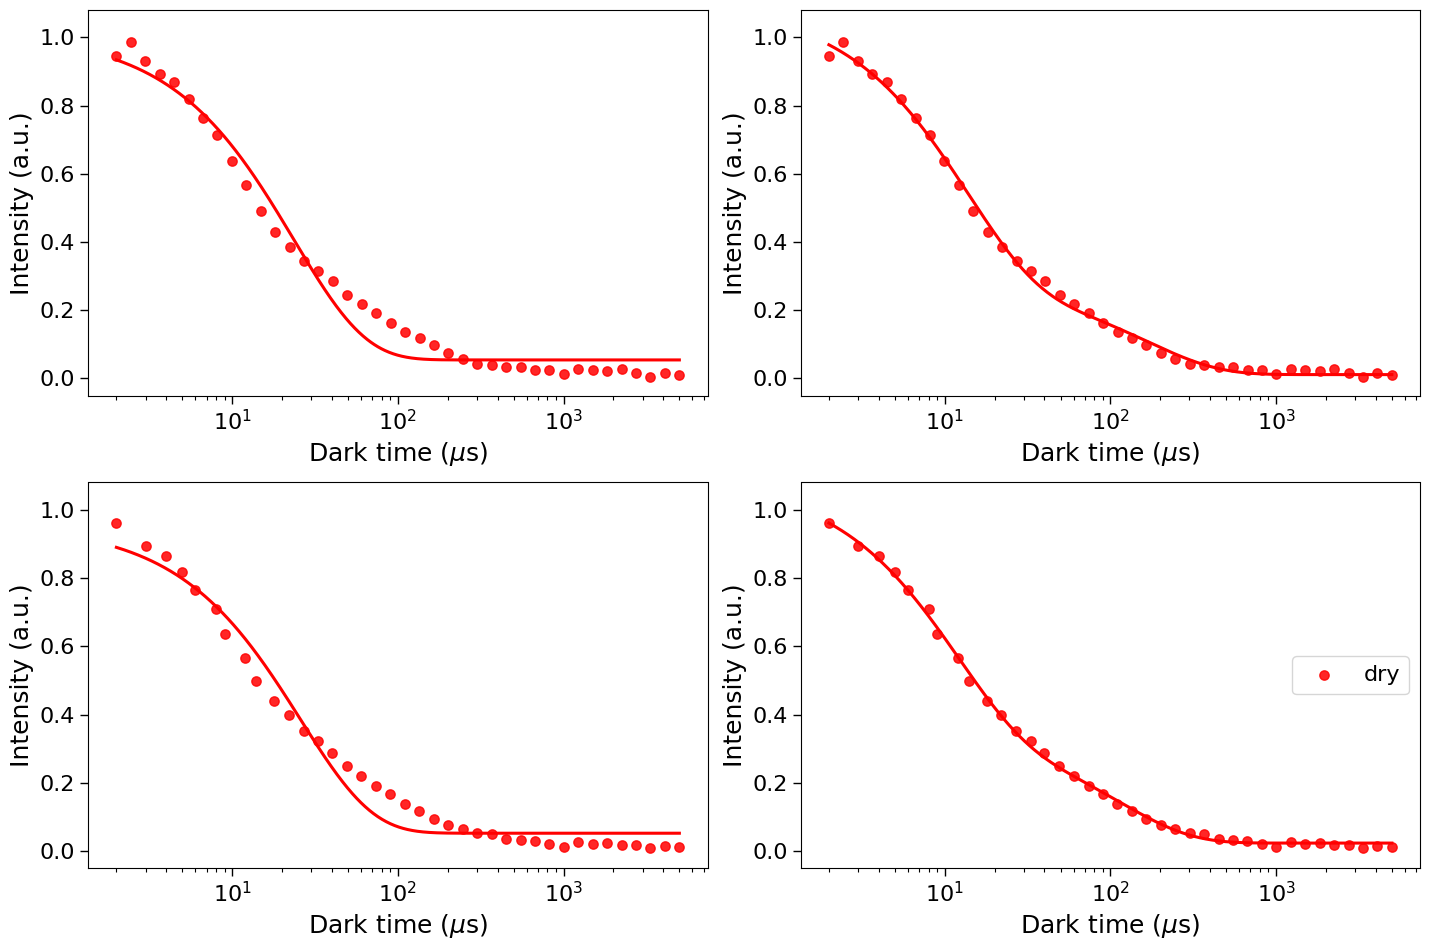


Saved refit parameters to:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\refit_parameters_fixed_single_exp.xlsx


,variation,method,model,RMSE_normalized,I0,A1,Tau1_us,I0_lower,I0_upper,tail_median,tail_std,recap_tau_guess,A2,Tau2_us
0,dry,regular,single,0.046396,0.054399,0.957416,23.578331,-0.060703,0.099297,0.019297,0.007282,23.129931,NaN,NaN
1,dry,regular,biexp,0.014664,0.011385,0.820711,13.172993,NaN,NaN,NaN,NaN,NaN,0.264778,166.490127
2,dry,random10,single,0.045639,0.052093,0.905146,25.875935,-0.062595,0.097405,0.017405,0.005198,23.552628,NaN,NaN
3,dry,random10,biexp,0.009633,0.023184,0.738893,11.180963,NaN,NaN,NaN,NaN,NaN,0.325853,114.141555


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
import re
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = Path(r"C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old")
RECAP_FILE = Path(r"a_recap.xlsx")

PLOT_VARIATIONS = ["dry"]

PANEL_CONFIG = [
    ("regular",  "single"),
    ("regular",  "biexp"),
    ("random10", "single"),
    ("random10", "biexp"),
]

# To use random 20 instead, change PANEL_CONFIG to:
# PANEL_CONFIG = [
#     ("regular",  "single"),
#     ("regular",  "biexp"),
#     ("random20", "single"),
#     ("random20", "biexp"),
# ]

SAVE_FIGURE = False
OUTPUT_NAME = "TA-graphs-fitting_dry_100uM_fixed_single.png"
OUTPUT_PATH = Path(r"C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\graphs") / OUTPUT_NAME

# Set manually only if the printed signal column is wrong.
# Example:
# TAU_COLUMN = "Tau (us)"
# SIGNAL_COLUMN = "Signal"
TAU_COLUMN = None
SIGNAL_COLUMN = None

# Use a_recap.xlsx only as a possible source of Tau1 initial guess.
USE_RECAP_AS_INITIAL_GUESS = True

# Single-exponential fitting control.
# The single-exp baseline I0 should represent the long-tau plateau.
SINGLE_TAIL_POINTS = 10
SINGLE_I0_MIN_MARGIN = 0.08
SINGLE_I0_STD_FACTOR = 2.0

# ============================================================
# FOLDER AND SHEET SETTINGS
# ============================================================

VARIATIONS = {
    "dry": {
        "folder": "dry",
        "label": "dry",
    },
    "water": {
        "folder": "water",
        "label": "water",
    },
    "1 uM Mn2+": {
        "folder": "1 uM",
        "label": r"1 $\mu$M Mn$^{2+}$",
    },
    "10 uM Mn2+": {
        "folder": "10 uM",
        "label": r"10 $\mu$M Mn$^{2+}$",
    },
    "100 uM Mn2+": {
        "folder": "100 uM",
        "label": r"100 $\mu$M Mn$^{2+}$",
    },
}

METHODS = {
    "regular": {
        "folder": "regular",
        "label": "Regular sampling",
    },
    "random10": {
        "folder": "random",
        "label": "Random 10 combinations",
    },
    "random20": {
        "folder": "random2",
        "label": "Random 20 combinations",
    },
}

FIT_SHEETS = {
    ("regular",  "single"): "single",
    ("regular",  "biexp"): "biexp",
    ("random10", "single"): "single_rand",
    ("random10", "biexp"): "biexp_rand",
    ("random20", "single"): "single_rand2",
    ("random20", "biexp"): "biexp_rand2",
}

COLORS = {
    "dry": "red",
    "water": "green",
    "1 uM Mn2+": "orange",
    "10 uM Mn2+": "purple",
    "100 uM Mn2+": "royalblue",
}

MARKERS = {
    "dry": "o",
    "water": "s",
    "1 uM Mn2+": "^",
    "10 uM Mn2+": "D",
    "100 uM Mn2+": "o",
}

# ============================================================
# BASIC FUNCTIONS
# ============================================================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("µ", "u").replace("μ", "u")
    text = re.sub(r"[^a-z0-9]+", "", text)
    return text


def resolve_folder(parent, folder_hint):
    direct = parent / folder_hint

    if direct.exists():
        return direct

    target = normalize_text(folder_hint)

    for p in parent.iterdir():
        if p.is_dir() and normalize_text(p.name) == target:
            return p

    raise FileNotFoundError(f"Folder not found: {parent / folder_hint}")


def find_signal_files(variation_name, method_key):
    variation_folder = resolve_folder(BASE_DIR, VARIATIONS[variation_name]["folder"])
    method_folder = resolve_folder(variation_folder, METHODS[method_key]["folder"])

    all_files = sorted([
        p for p in method_folder.rglob("*.xlsx")
        if not p.name.startswith("~$")
    ])

    average_files = [
        p for p in all_files
        if ("average" in p.name.lower()) or ("averaged" in p.name.lower())
    ]

    files = average_files if len(average_files) > 0 else all_files

    if len(files) == 0:
        raise FileNotFoundError(f"No Excel signal files found in: {method_folder}")

    return files


def choose_tau_column(df):
    if TAU_COLUMN is not None:
        return TAU_COLUMN

    columns = list(df.columns)

    priority_names = [
        "tauus",
        "tau",
        "darktimeus",
        "darktime",
    ]

    for target in priority_names:
        for col in columns:
            if normalize_text(col) == target:
                return col

    for col in columns:
        c = normalize_text(col)
        if "tau" in c and "err" not in c and "error" not in c:
            return col

    numeric_cols = list(df.select_dtypes(include=[np.number]).columns)

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def choose_signal_column(df, tau_col):
    if SIGNAL_COLUMN is not None:
        return SIGNAL_COLUMN

    columns = list(df.columns)

    priority_names = [
        "signal",
        "signalmean",
        "meansignal",
        "signalavg",
        "averagesignal",
        "averagedsignal",
        "normalizedsignal",
        "signalnormalized",
        "ratio",
        "intensity",
        "i",
    ]

    for target in priority_names:
        for col in columns:
            if col == tau_col:
                continue
            if normalize_text(col) == target:
                return col

    for col in columns:
        if col == tau_col:
            continue

        c = normalize_text(col)

        bad_keywords = [
            "tau", "time", "err", "error", "std", "sd", "sem",
            "sigma", "uncert", "fit", "fitted", "x"
        ]

        good_keywords = [
            "signal", "ratio", "intensity", "normalized", "norm"
        ]

        if any(bad in c for bad in bad_keywords):
            continue

        if any(good in c for good in good_keywords):
            return col

    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col != tau_col
    ]

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def read_one_signal_file(file_path):
    xls = pd.ExcelFile(file_path)

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        df = df.dropna(how="all")
        df.columns = [str(c).strip() for c in df.columns]

        if df.empty:
            continue

        tau_col = choose_tau_column(df)
        signal_col = choose_signal_column(df, tau_col)

        if tau_col is None or signal_col is None:
            continue

        out = pd.DataFrame({
            "Tau_us": pd.to_numeric(df[tau_col], errors="coerce"),
            "Signal": pd.to_numeric(df[signal_col], errors="coerce"),
        })

        out = out.dropna(subset=["Tau_us", "Signal"])
        out = out[out["Tau_us"] > 0]
        out = out.sort_values("Tau_us").reset_index(drop=True)

        if len(out) > 0:
            info = {
                "file": file_path.name,
                "sheet": sheet,
                "tau_col": tau_col,
                "signal_col": signal_col,
            }

            return out, info

    raise ValueError(f"Could not detect tau and signal columns in: {file_path}")


def scale01(y):
    y = np.asarray(y, dtype=float)

    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    yrange = ymax - ymin

    if not np.isfinite(yrange) or abs(yrange) < 1e-30:
        return np.zeros_like(y)

    return (y - ymin) / yrange


def normalize_each_file_then_average(files):
    all_data = []
    first_info = None

    for source_index, file_path in enumerate(files, start=1):
        df, info = read_one_signal_file(file_path)

        if first_info is None:
            first_info = info

        tau = df["Tau_us"].to_numpy()
        signal = df["Signal"].to_numpy()

        signal_norm = scale01(signal)

        temp = pd.DataFrame({
            "Tau_us": tau,
            "Signal_norm": signal_norm,
            "source": source_index,
        })

        temp["Tau_key"] = temp["Tau_us"].round(9)
        all_data.append(temp)

    combined = pd.concat(all_data, ignore_index=True)

    averaged = combined.groupby("Tau_key", as_index=False).agg(
        Tau_us=("Tau_us", "mean"),
        Signal_mean=("Signal_norm", "mean"),
        Signal_std=("Signal_norm", "std"),
        N=("Signal_norm", "count"),
    )

    averaged["Signal_sem"] = averaged["Signal_std"] / np.sqrt(averaged["N"])
    averaged = averaged.sort_values("Tau_us").reset_index(drop=True)

    return averaged, first_info


# ============================================================
# FITTING FUNCTIONS
# ============================================================

def single_exp(tau, I0, A1, Tau1):
    return I0 + A1 * np.exp(-tau / Tau1)


def biexp(tau, I0, A1, Tau1, A2, Tau2):
    return I0 + A1 * np.exp(-tau / Tau1) + A2 * np.exp(-tau / Tau2)


def get_recap_rows(recap_df, variation_name):
    if recap_df is None:
        return pd.DataFrame()

    if "variations" not in recap_df.columns:
        return pd.DataFrame()

    target = normalize_text(variation_name)

    rows = recap_df[
        recap_df["variations"].apply(normalize_text) == target
    ].copy()

    rows = rows.reset_index(drop=True)

    return rows


def get_recap_tau_guess(recap_df, variation_name):
    rows = get_recap_rows(recap_df, variation_name)

    if rows.empty:
        return None

    if "Tau1" not in rows.columns:
        return None

    tau_guess = float(np.nanmedian(rows["Tau1"]))

    if not np.isfinite(tau_guess) or tau_guess <= 0:
        return None

    return tau_guess


def default_biexp_initial_guess(tau, y):
    y = np.asarray(y, dtype=float)
    tau = np.asarray(tau, dtype=float)

    I0_guess = float(np.nanmedian(y[-5:]))
    amp_guess = float(np.nanmax(y) - I0_guess)

    if amp_guess <= 0:
        amp_guess = float(np.nanmax(y) - np.nanmin(y))

    if amp_guess <= 0:
        amp_guess = 1.0

    tau_mid = float(np.nanmedian(tau))

    return [
        I0_guess,
        0.6 * amp_guess,
        tau_mid / 3,
        0.4 * amp_guess,
        tau_mid * 3,
    ]


def recap_biexp_initial_guess(recap_df, variation_name, y_data):
    rows = get_recap_rows(recap_df, variation_name)

    if rows.empty:
        return None

    y0 = float(np.nanmedian(y_data[-5:]))
    amp = float(np.nanmax(y_data) - y0)

    if amp <= 0:
        amp = float(np.nanmax(y_data) - np.nanmin(y_data))

    if amp <= 0:
        amp = 1.0

    try:
        tau1_guess = float(np.nanmedian(rows["Tau1"]))
        tau2_guess = float(np.nanmedian(rows["Tau2"]))

        if not np.isfinite(tau1_guess) or tau1_guess <= 0:
            return None

        if not np.isfinite(tau2_guess) or tau2_guess <= 0:
            return None

        tau_short = min(tau1_guess, tau2_guess)
        tau_long = max(tau1_guess, tau2_guess)

        return [y0, 0.6 * amp, tau_short, 0.4 * amp, tau_long]

    except Exception:
        return None


def estimate_single_i0_bounds(y):
    y = np.asarray(y, dtype=float)

    n_tail = min(SINGLE_TAIL_POINTS, len(y))
    tail = y[-n_tail:]

    tail_median = float(np.nanmedian(tail))
    tail_std = float(np.nanstd(tail))

    margin = max(SINGLE_I0_MIN_MARGIN, SINGLE_I0_STD_FACTOR * tail_std)

    # I0 is the long-tau baseline. This keeps it near the long-tau points,
    # preventing the single-exp curve from floating too high.
    i0_lower = max(-0.10, tail_median - margin)
    i0_upper = min(0.60, tail_median + margin)

    if i0_upper <= i0_lower:
        i0_lower = -0.10
        i0_upper = 0.60

    return i0_lower, i0_upper, tail_median, tail_std


def make_single_initial_guesses(tau, y, recap_tau_guess=None):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    i0_lower, i0_upper, tail_median, tail_std = estimate_single_i0_bounds(y)

    first_level = float(np.nanmedian(y[:3]))
    y_max = float(np.nanmax(y))
    y_min = float(np.nanmin(y))

    tau_min = float(np.nanmin(tau))
    tau_med = float(np.nanmedian(tau))
    tau_max = float(np.nanmax(tau))

    tau_guesses = [
        tau_min * 3,
        tau_min * 5,
        5.0,
        10.0,
        20.0,
        50.0,
        tau_med / 3,
        tau_med,
        tau_max / 20,
    ]

    if recap_tau_guess is not None:
        tau_guesses.append(recap_tau_guess)

    i0_guesses = [
        tail_median,
        np.nanmedian(y[-5:]),
        y_min,
        (i0_lower + i0_upper) / 2,
    ]

    guesses = []

    for i0 in i0_guesses:
        i0 = float(np.clip(i0, i0_lower + 1e-9, i0_upper - 1e-9))

        amp_guesses = [
            first_level - i0,
            y_max - i0,
            1.0 - i0,
        ]

        for amp in amp_guesses:
            amp = float(amp)

            if amp <= 0:
                amp = max(0.1, y_max - y_min)

            for tau_guess in tau_guesses:
                if np.isfinite(tau_guess) and tau_guess > 0:
                    guesses.append([i0, amp, tau_guess])

    return guesses, (i0_lower, i0_upper, tail_median, tail_std)


def fit_single_exp_robust(tau, y, recap_df=None, variation_name=None):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(tau) & np.isfinite(y) & (tau > 0)

    tau = tau[valid]
    y = y[valid]

    order = np.argsort(tau)
    tau = tau[order]
    y = y[order]

    recap_tau_guess = None

    if USE_RECAP_AS_INITIAL_GUESS:
        recap_tau_guess = get_recap_tau_guess(recap_df, variation_name)

    guesses, i0_info = make_single_initial_guesses(
        tau=tau,
        y=y,
        recap_tau_guess=recap_tau_guess,
    )

    i0_lower, i0_upper, tail_median, tail_std = i0_info

    # Important for single-exponential:
    # A1 is kept positive because the normalized curve is a decay.
    # I0 is constrained close to the long-tau tail.
    lower = [i0_lower, 0.00, 0.01]
    upper = [i0_upper, 2.00, 1e6]

    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)

    best_params = None
    best_rmse = np.inf

    for p0 in guesses:
        p0 = np.asarray(p0, dtype=float)
        p0 = np.maximum(p0, lower_arr + 1e-12)
        p0 = np.minimum(p0, upper_arr - 1e-12)

        try:
            # No sigma weighting for single exponential.
            # This prevents long-tau points from being ignored.
            popt, pcov = curve_fit(
                single_exp,
                tau,
                y,
                p0=p0,
                bounds=(lower, upper),
                maxfev=300000,
            )

            y_pred = single_exp(tau, *popt)
            rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = popt

        except Exception:
            continue

    if best_params is None:
        print(f"Warning: single-exp fitting failed for {variation_name}. Using initial guess.")
        best_params = np.asarray(guesses[0], dtype=float)
        best_params = np.maximum(best_params, lower_arr + 1e-12)
        best_params = np.minimum(best_params, upper_arr - 1e-12)

        y_pred = single_exp(tau, *best_params)
        best_rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

    debug_info = {
        "I0_lower": i0_lower,
        "I0_upper": i0_upper,
        "tail_median": tail_median,
        "tail_std": tail_std,
        "recap_tau_guess": recap_tau_guess,
    }

    return best_params, best_rmse, debug_info


def fit_biexp_original_style(tau, y, recap_df=None, variation_name=None):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(tau) & np.isfinite(y) & (tau > 0)

    tau = tau[valid]
    y = y[valid]

    order = np.argsort(tau)
    tau = tau[order]
    y = y[order]

    lower = [-0.20, -2.00, 0.01, -2.00, 0.01]
    upper = [ 1.20,  2.00, 1e6,  2.00, 1e6]

    p0 = None

    if USE_RECAP_AS_INITIAL_GUESS:
        p0 = recap_biexp_initial_guess(recap_df, variation_name, y)

    if p0 is None:
        p0 = default_biexp_initial_guess(tau, y)

    p0 = np.asarray(p0, dtype=float)
    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)

    p0 = np.maximum(p0, lower_arr + 1e-12)
    p0 = np.minimum(p0, upper_arr - 1e-12)

    # Keep your previous mild weighting for bi-exponential fitting.
    sigma = np.sqrt(tau / np.nanmin(tau))
    sigma = sigma / np.nanmin(sigma)

    try:
        popt, pcov = curve_fit(
            biexp,
            tau,
            y,
            p0=p0,
            bounds=(lower, upper),
            sigma=sigma,
            absolute_sigma=False,
            maxfev=200000,
        )

    except Exception as e:
        print(f"Warning: bi-exp fitting failed for {variation_name}. Error: {e}")
        print("Using initial guess instead.")
        popt = p0

    y_pred = biexp(tau, *popt)
    rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

    return popt, rmse


def fit_averaged_signal(tau, y, model_name, recap_df=None, variation_name=None):
    if model_name == "single":
        params, rmse, debug_info = fit_single_exp_robust(
            tau=tau,
            y=y,
            recap_df=recap_df,
            variation_name=variation_name,
        )

        return params, rmse, debug_info

    if model_name == "biexp":
        params, rmse = fit_biexp_original_style(
            tau=tau,
            y=y,
            recap_df=recap_df,
            variation_name=variation_name,
        )

        return params, rmse, None

    raise ValueError("model_name must be 'single' or 'biexp'")


def evaluate_model(tau, params, model_name):
    if model_name == "single":
        return single_exp(tau, *params)

    if model_name == "biexp":
        return biexp(tau, *params)

    raise ValueError("model_name must be 'single' or 'biexp'")


# ============================================================
# LOAD RECAP FILE
# ============================================================

recap = {}

for key, sheet_name in FIT_SHEETS.items():
    try:
        df = pd.read_excel(RECAP_FILE, sheet_name=sheet_name)
        df.columns = [str(c).strip() for c in df.columns]
        recap[key] = df
    except Exception:
        recap[key] = None
        print(f"Warning: could not read sheet {sheet_name} from {RECAP_FILE}")


# ============================================================
# MAKE FIGURE
# ============================================================

n_panels = len(PANEL_CONFIG)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(7.2 * ncols, 4.8 * nrows),
    squeeze=False
)

axes = axes.flatten()
panel_letters = "abcdefghijklmnopqrstuvwxyz"

fit_summary = []

for ax_idx, (method_key, model_name) in enumerate(PANEL_CONFIG):
    ax = axes[ax_idx]

    method_label = METHODS[method_key]["label"]
    model_label = "single-exponential" if model_name == "single" else "bi-exponential"

    for variation_name in PLOT_VARIATIONS:
        files = find_signal_files(variation_name, method_key)

        avg_df, detected_info = normalize_each_file_then_average(files)

        tau_data = avg_df["Tau_us"].to_numpy()
        signal_plot = avg_df["Signal_mean"].to_numpy()

        recap_df = recap.get((method_key, model_name), None)

        params, rmse, debug_info = fit_averaged_signal(
            tau=tau_data,
            y=signal_plot,
            model_name=model_name,
            recap_df=recap_df,
            variation_name=variation_name,
        )

        tau_fit = np.logspace(
            np.log10(np.nanmin(tau_data)),
            np.log10(np.nanmax(tau_data)),
            800
        )

        fit_plot = evaluate_model(tau_fit, params, model_name)

        color = COLORS.get(variation_name, None)
        marker = MARKERS.get(variation_name, "o")

        ax.grid(False)

        ax.scatter(
            tau_data,
            signal_plot,
            s=45,
            marker=marker,
            color=color,
            alpha=0.85,
            label=f"{VARIATIONS[variation_name]['label']}"
        )

        ax.plot(
            tau_fit,
            fit_plot,
            linewidth=2.2,
            color=color,
        )

        print("=" * 75)
        print(f"Variation       : {variation_name}")
        print(f"Sampling method : {method_key}")
        print(f"Fitting model   : {model_name}")
        print(f"Files averaged  : {len(files)}")
        print(f"Example file    : {detected_info['file']}")
        print(f"Sheet used      : {detected_info['sheet']}")
        print(f"Tau column      : {detected_info['tau_col']}")
        print(f"Signal column   : {detected_info['signal_col']}")
        print(f"Data range      : {np.nanmin(signal_plot):.6f} to {np.nanmax(signal_plot):.6f}")
        print(f"Fit range       : {np.nanmin(fit_plot):.6f} to {np.nanmax(fit_plot):.6f}")
        print(f"RMSE            : {rmse:.6f}")
        print(f"Fit parameters  : {params}")

        if model_name == "single" and debug_info is not None:
            print(f"Single I0 bounds: {debug_info['I0_lower']:.6f} to {debug_info['I0_upper']:.6f}")
            print(f"Tail median     : {debug_info['tail_median']:.6f}")
            print(f"Tail std        : {debug_info['tail_std']:.6f}")
            print(f"Recap Tau guess : {debug_info['recap_tau_guess']}")

        row = {
            "variation": variation_name,
            "method": method_key,
            "model": model_name,
            "RMSE_normalized": rmse,
        }

        if model_name == "single":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
                "I0_lower": debug_info["I0_lower"],
                "I0_upper": debug_info["I0_upper"],
                "tail_median": debug_info["tail_median"],
                "tail_std": debug_info["tail_std"],
                "recap_tau_guess": debug_info["recap_tau_guess"],
            })

        if model_name == "biexp":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
                "A2": params[3],
                "Tau2_us": params[4],
            })

        fit_summary.append(row)

    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.08)

    ax.set_xlabel(r"Dark time ($\mu$s)", fontsize=18)
    ax.set_ylabel(r"Intensity (a.u.)", fontsize=18)

    # if ax_idx == 2 or ax_idx == 3:
    #     ax.set_xlabel(r"$\tau$ ($\mu$s)", fontsize=18)

    # if ax_idx == 0 or ax_idx == 2:
    #     ax.set_ylabel(r"I (a.u.)", fontsize=18)

    # ax.text(
    #     0.95,
    #     0.95,
    #     f"({panel_letters[ax_idx]})",
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="top",
    #     fontsize=18
    # )

    ax.tick_params(axis="both", which="major", length=6, width=1, labelsize=16)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8, labelsize=16)

    if ax_idx == 3:
        ax.legend(frameon=True, fontsize=16, loc="center right")

for j in range(n_panels, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

if SAVE_FIGURE:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
    print(f"\nSaved figure to:\n{OUTPUT_PATH}")

plt.show()

# ============================================================
# SAVE REFIT PARAMETERS
# ============================================================

fit_summary_df = pd.DataFrame(fit_summary)

summary_path = BASE_DIR / "refit_parameters_fixed_single_exp.xlsx"
fit_summary_df.to_excel(summary_path, index=False)

print(f"\nSaved refit parameters to:\n{summary_path}")
display(fit_summary_df)

---

Figure          : regular_single
Panel label     : (a)
Variation       : dry
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.046396
Fit parameters  : [ 0.05439872  0.95741309 23.57862834]
Figure          : regular_single
Panel label     : (a)
Variation       : 100 uM Mn2+
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.078273
Fit parameters  : [0.20951007 1.25959498 4.94694086]

Saved figure:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\four_separate_fitting_figures\regular_single_a.png


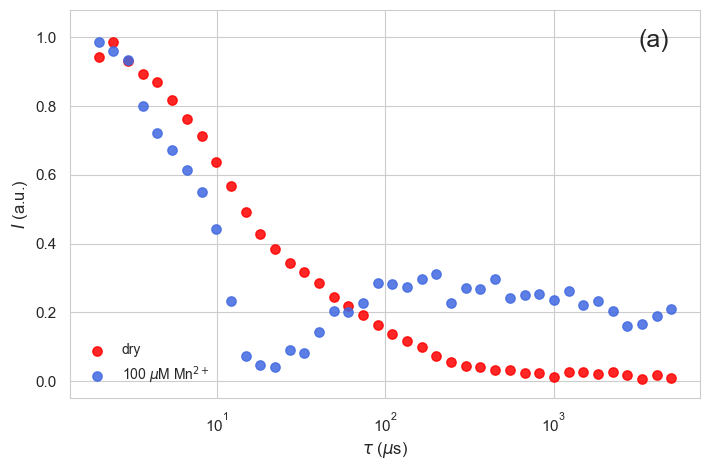

Figure          : regular_biexp
Panel label     : (b)
Variation       : dry
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.011803
Fit parameters  : [2.05598768e-02 7.74278605e-01 1.10498830e+01 3.28502784e-01
 1.12801882e+02]
Figure          : regular_biexp
Panel label     : (b)
Variation       : 100 uM Mn2+
Files averaged  : 5
Example file    : t1_regular_regular_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.046124
Fit parameters  : [ 0.24802412  3.         11.13394069 -1.92186113 18.42932575]

Saved figure:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\four_separate_fitting_figures\regular_biexp_b.png


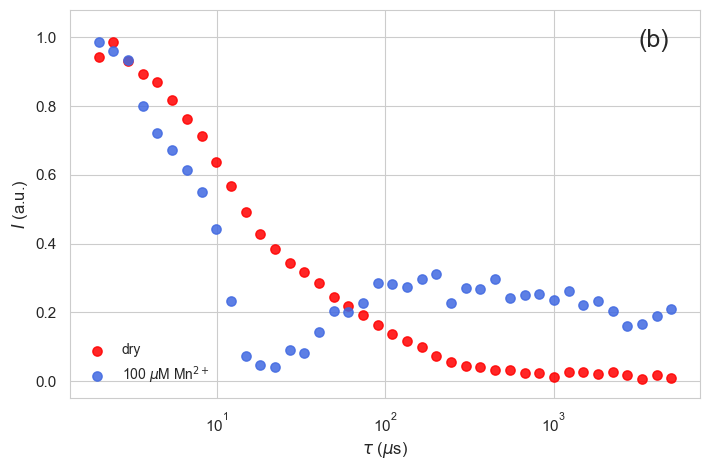

Figure          : random10_single
Panel label     : (c)
Variation       : dry
Files averaged  : 10
Example file    : t1_regular_random_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.045639
Fit parameters  : [ 0.05209215  0.90514281 25.87631159]
Figure          : random10_single
Panel label     : (c)
Variation       : 100 uM Mn2+
Files averaged  : 9
Example file    : t1_regular_random_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.079940
Fit parameters  : [0.21790739 1.18083573 4.58967766]

Saved figure:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\four_separate_fitting_figures\random10_single_c.png


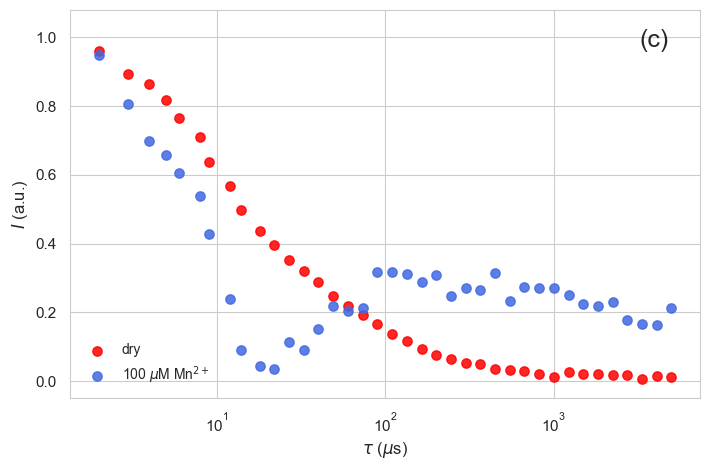

Figure          : random10_biexp
Panel label     : (d)
Variation       : dry
Files averaged  : 10
Example file    : t1_regular_random_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.009326
Fit parameters  : [2.09442947e-02 7.32423018e-01 1.06441180e+01 3.43565944e-01
 1.09567952e+02]
Figure          : random10_biexp
Panel label     : (d)
Variation       : 100 uM Mn2+
Files averaged  : 9
Example file    : t1_regular_random_average_01_width1000ns_start300ns.xlsx
Sheet used      : Sheet1
Tau column      : Tau (us)
Signal column   : Signal
RMSE            : 0.049087
Fit parameters  : [ 0.2553608   3.         10.9399948  -2.0065349  17.57041451]

Saved figure:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\four_separate_fitting_figures\random10_biexp_d.png


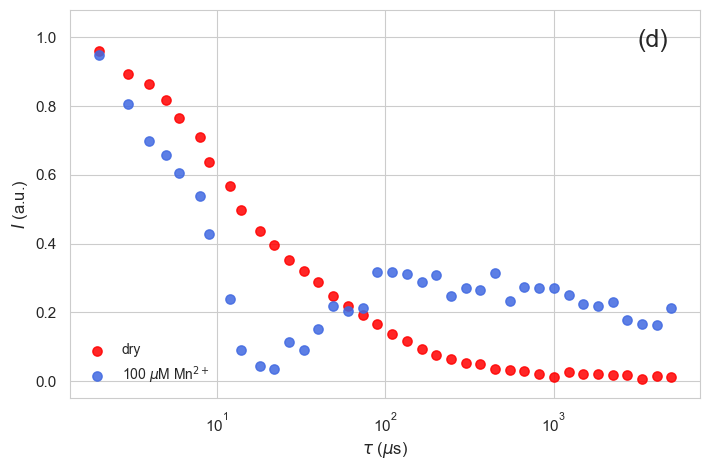


Saved fitting summary:
C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old\four_separate_fitting_figures\separate_figures_refit_summary.xlsx


,figure,panel_label,method,model,variation,RMSE_normalized,I0,A1,Tau1_us,A2,Tau2_us
0,regular_single,(a),regular,single,dry,0.046396,0.054399,0.957413,23.578628,NaN,NaN
1,regular_single,(a),regular,single,100 uM Mn2+,0.078273,0.209510,1.259595,4.946941,NaN,NaN
2,regular_biexp,(b),regular,biexp,dry,0.011803,0.020560,0.774279,11.049883,0.328503,112.801882
3,regular_biexp,(b),regular,biexp,100 uM Mn2+,0.046124,0.248024,3.000000,11.133941,-1.921861,18.429326
4,random10_single,(c),random10,single,dry,0.045639,0.052092,0.905143,25.876312,NaN,NaN
5,random10_single,(c),random10,single,100 uM Mn2+,0.079940,0.217907,1.180836,4.589678,NaN,NaN
6,random10_biexp,(d),random10,biexp,dry,0.009326,0.020944,0.732423,10.644118,0.343566,109.567952
7,random10_biexp,(d),random10,biexp,100 uM Mn2+,0.049087,0.255361,3.000000,10.939995,-2.006535,17.570415


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = Path(r"C:\Users\trina\UGM\OneDrive - UGM 365\A - TA\A - DATA\raw_data\old")

PLOT_VARIATIONS = ["dry", "100 uM Mn2+"]

FIGURE_CONFIG = [
    ("regular",  "single", "(a)"),
    ("regular",  "biexp",  "(b)"),
    ("random10", "single", "(c)"),
    ("random10", "biexp",  "(d)"),
]

SAVE_FIGURES = True
OUTPUT_FOLDER = BASE_DIR / "four_separate_fitting_figures"

# Set manually only if automatic column detection is wrong.
# Example:
# TAU_COLUMN = "Tau (us)"
# SIGNAL_COLUMN = "Signal"
TAU_COLUMN = None
SIGNAL_COLUMN = None

# Because your plotted data are normalized, this code refits the averaged normalized signal.
# This makes the plotted curve follow the shown data better than reusing old parameters.
FIT_AVERAGED_DATA_DIRECTLY = True

# ============================================================
# FOLDER AND LABEL SETTINGS
# ============================================================

VARIATIONS = {
    "dry": {
        "folder": "dry",
        "label": "dry",
    },
    "water": {
        "folder": "water",
        "label": "water",
    },
    "1 uM Mn2+": {
        "folder": "1 uM",
        "label": r"1 $\mu$M Mn$^{2+}$",
    },
    "10 uM Mn2+": {
        "folder": "10 uM",
        "label": r"10 $\mu$M Mn$^{2+}$",
    },
    "100 uM Mn2+": {
        "folder": "100 uM",
        "label": r"100 $\mu$M Mn$^{2+}$",
    },
}

METHODS = {
    "regular": {
        "folder": "regular",
        "label": "Regular sampling",
    },
    "random10": {
        "folder": "random",
        "label": "Random 10 combinations",
    },
    "random20": {
        "folder": "random2",
        "label": "Random 20 combinations",
    },
}

COLORS = {
    "dry": "red",
    "water": "green",
    "1 uM Mn2+": "orange",
    "10 uM Mn2+": "purple",
    "100 uM Mn2+": "royalblue",
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("µ", "u").replace("μ", "u")
    text = re.sub(r"[^a-z0-9]+", "", text)
    return text


def resolve_folder(parent, folder_hint):
    direct = parent / folder_hint

    if direct.exists():
        return direct

    target = normalize_text(folder_hint)

    for p in parent.iterdir():
        if p.is_dir() and normalize_text(p.name) == target:
            return p

    raise FileNotFoundError(f"Folder not found: {parent / folder_hint}")


def find_signal_files(variation_name, method_key):
    variation_folder = resolve_folder(BASE_DIR, VARIATIONS[variation_name]["folder"])
    method_folder = resolve_folder(variation_folder, METHODS[method_key]["folder"])

    all_files = sorted([
        p for p in method_folder.rglob("*.xlsx")
        if not p.name.startswith("~$")
    ])

    average_files = [
        p for p in all_files
        if ("average" in p.name.lower()) or ("averaged" in p.name.lower())
    ]

    files = average_files if len(average_files) > 0 else all_files

    if len(files) == 0:
        raise FileNotFoundError(f"No Excel files found in: {method_folder}")

    return files


def choose_tau_column(df):
    if TAU_COLUMN is not None:
        return TAU_COLUMN

    columns = list(df.columns)

    priority_names = [
        "tauus",
        "tau",
        "darktimeus",
        "darktime",
    ]

    for target in priority_names:
        for col in columns:
            if normalize_text(col) == target:
                return col

    for col in columns:
        c = normalize_text(col)
        if "tau" in c and "err" not in c and "error" not in c:
            return col

    numeric_cols = list(df.select_dtypes(include=[np.number]).columns)

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def choose_signal_column(df, tau_col):
    if SIGNAL_COLUMN is not None:
        return SIGNAL_COLUMN

    columns = list(df.columns)

    priority_names = [
        "signal",
        "signalmean",
        "meansignal",
        "signalavg",
        "averagesignal",
        "averagedsignal",
        "normalizedsignal",
        "signalnormalized",
        "ratio",
        "intensity",
        "i",
    ]

    for target in priority_names:
        for col in columns:
            if col == tau_col:
                continue
            if normalize_text(col) == target:
                return col

    for col in columns:
        if col == tau_col:
            continue

        c = normalize_text(col)

        bad_keywords = [
            "tau", "time", "err", "error", "std", "sd", "sem",
            "sigma", "uncert", "fit", "fitted", "x"
        ]

        good_keywords = [
            "signal", "ratio", "intensity", "normalized", "norm"
        ]

        if any(bad in c for bad in bad_keywords):
            continue

        if any(good in c for good in good_keywords):
            return col

    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col != tau_col
    ]

    if len(numeric_cols) > 0:
        return numeric_cols[0]

    return None


def read_one_signal_file(file_path):
    xls = pd.ExcelFile(file_path)

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        df = df.dropna(how="all")
        df.columns = [str(c).strip() for c in df.columns]

        if df.empty:
            continue

        tau_col = choose_tau_column(df)
        signal_col = choose_signal_column(df, tau_col)

        if tau_col is None or signal_col is None:
            continue

        out = pd.DataFrame({
            "Tau_us": pd.to_numeric(df[tau_col], errors="coerce"),
            "Signal": pd.to_numeric(df[signal_col], errors="coerce"),
        })

        out = out.dropna(subset=["Tau_us", "Signal"])
        out = out[out["Tau_us"] > 0]
        out = out.sort_values("Tau_us").reset_index(drop=True)

        if len(out) > 0:
            info = {
                "file": file_path.name,
                "sheet": sheet,
                "tau_col": tau_col,
                "signal_col": signal_col,
            }

            return out, info

    raise ValueError(f"Could not detect tau and signal columns in: {file_path}")


def scale01(y):
    y = np.asarray(y, dtype=float)

    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    yrange = ymax - ymin

    if not np.isfinite(yrange) or abs(yrange) < 1e-30:
        return np.zeros_like(y)

    return (y - ymin) / yrange


def normalize_each_file_then_average(files):
    all_data = []
    first_info = None

    for source_index, file_path in enumerate(files, start=1):
        df, info = read_one_signal_file(file_path)

        if first_info is None:
            first_info = info

        tau = df["Tau_us"].to_numpy()
        signal = df["Signal"].to_numpy()

        signal_norm = scale01(signal)

        temp = pd.DataFrame({
            "Tau_us": tau,
            "Signal_norm": signal_norm,
            "source": source_index,
        })

        temp["Tau_key"] = temp["Tau_us"].round(9)
        all_data.append(temp)

    combined = pd.concat(all_data, ignore_index=True)

    averaged = combined.groupby("Tau_key", as_index=False).agg(
        Tau_us=("Tau_us", "mean"),
        Signal_mean=("Signal_norm", "mean"),
        Signal_std=("Signal_norm", "std"),
        N=("Signal_norm", "count"),
    )

    averaged["Signal_sem"] = averaged["Signal_std"] / np.sqrt(averaged["N"])
    averaged = averaged.sort_values("Tau_us").reset_index(drop=True)

    return averaged, first_info


# ============================================================
# FITTING FUNCTIONS
# ============================================================

def single_exp(tau, I0, A1, Tau1):
    return I0 + A1 * np.exp(-tau / Tau1)


def biexp(tau, I0, A1, Tau1, A2, Tau2):
    return I0 + A1 * np.exp(-tau / Tau1) + A2 * np.exp(-tau / Tau2)


def evaluate_model(tau, params, model_name):
    if model_name == "single":
        return single_exp(tau, *params)

    if model_name == "biexp":
        return biexp(tau, *params)

    raise ValueError("model_name must be 'single' or 'biexp'")


def make_initial_guesses(tau, y, model_name):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    y_last = float(np.nanmedian(y[-5:]))
    y_min = float(np.nanmin(y))
    y_max = float(np.nanmax(y))

    amp = y_max - y_last

    if amp <= 0:
        amp = y_max - y_min

    if amp <= 0:
        amp = 1.0

    tau_min = float(np.nanmin(tau))
    tau_med = float(np.nanmedian(tau))
    tau_max = float(np.nanmax(tau))

    if model_name == "single":
        guesses = [
            [y_last, amp, tau_med],
            [y_min, 1.0, tau_med],
            [0.0, 1.0, 10.0],
            [0.1, 0.9, 20.0],
            [0.2, 0.8, 50.0],
            [y_last, amp, tau_max / 10],
        ]

    elif model_name == "biexp":
        guesses = [
            [y_last, 0.7 * amp, 10.0,  0.3 * amp, 100.0],
            [y_last, 0.7 * amp, 5.0,   0.3 * amp, 300.0],
            [y_last, 1.0 * amp, 10.0, -0.2 * amp, 200.0],
            [y_last, 1.0 * amp, 20.0, -0.3 * amp, 500.0],
            [0.2,    0.9,       10.0, -0.2,       300.0],
            [0.3,    0.8,       5.0,  -0.3,       1000.0],
            [y_min,  0.7,       tau_min * 5, 0.2, tau_med],
            [y_last, 0.5 * amp, tau_med / 3, 0.5 * amp, tau_med * 3],
        ]

    else:
        raise ValueError("model_name must be 'single' or 'biexp'")

    return guesses


def fit_averaged_signal(tau, y, model_name):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(tau) & np.isfinite(y) & (tau > 0)

    tau = tau[valid]
    y = y[valid]

    order = np.argsort(tau)
    tau = tau[order]
    y = y[order]

    if model_name == "single":
        model = single_exp

        lower = [-0.50, -3.00, 0.01]
        upper = [ 1.50,  3.00, 1e6]

    elif model_name == "biexp":
        model = biexp

        # A1 and A2 are allowed to be positive or negative.
        # This gives the bi-exponential fit more flexibility for dip-and-rise behavior.
        lower = [-0.50, -3.00, 0.01, -3.00, 0.01]
        upper = [ 1.50,  3.00, 1e6,  3.00, 1e6]

    else:
        raise ValueError("model_name must be 'single' or 'biexp'")

    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)

    best_params = None
    best_rmse = np.inf

    guesses = make_initial_guesses(tau, y, model_name)

    for p0 in guesses:
        p0 = np.asarray(p0, dtype=float)
        p0 = np.maximum(p0, lower_arr + 1e-12)
        p0 = np.minimum(p0, upper_arr - 1e-12)

        try:
            params, _ = curve_fit(
                model,
                tau,
                y,
                p0=p0,
                bounds=(lower, upper),
                maxfev=300000,
            )

            y_pred = model(tau, *params)
            rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = params

        except Exception:
            continue

    if best_params is None:
        print("Warning: fitting failed. Using first initial guess.")
        best_params = np.asarray(guesses[0], dtype=float)
        y_pred = model(tau, *best_params)
        best_rmse = np.sqrt(np.nanmean((y - y_pred) ** 2))

    return best_params, best_rmse


# ============================================================
# MAKE 4 SEPARATE FIGURES
# ============================================================

if SAVE_FIGURES:
    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

summary_rows = []

for method_key, model_name, panel_label in FIGURE_CONFIG:
    method_label = METHODS[method_key]["label"]
    model_label = "single-exponential" if model_name == "single" else "bi-exponential"

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for variation_name in PLOT_VARIATIONS:
        files = find_signal_files(variation_name, method_key)

        avg_df, detected_info = normalize_each_file_then_average(files)

        tau_data = avg_df["Tau_us"].to_numpy()
        signal_avg = avg_df["Signal_mean"].to_numpy()

        params, rmse = fit_averaged_signal(
            tau=tau_data,
            y=signal_avg,
            model_name=model_name,
        )

        tau_fit = np.logspace(
            np.log10(np.nanmin(tau_data)),
            np.log10(np.nanmax(tau_data)),
            800
        )

        fit_curve = evaluate_model(tau_fit, params, model_name)

        color = COLORS.get(variation_name, "black")

        ax.scatter(
            tau_data,
            signal_avg,
            s=45,
            color=color,
            alpha=0.85,
            label=f"{VARIATIONS[variation_name]['label']}"
        )

        # ax.plot(
        #     tau_fit,
        #     fit_curve,
        #     linewidth=2.3,
        #     color=color,
        #     label=f"{VARIATIONS[variation_name]['label']} fit"
        # )

        print("=" * 75)
        print(f"Figure          : {method_key}_{model_name}")
        print(f"Panel label     : {panel_label}")
        print(f"Variation       : {variation_name}")
        print(f"Files averaged  : {len(files)}")
        print(f"Example file    : {detected_info['file']}")
        print(f"Sheet used      : {detected_info['sheet']}")
        print(f"Tau column      : {detected_info['tau_col']}")
        print(f"Signal column   : {detected_info['signal_col']}")
        print(f"RMSE            : {rmse:.6f}")
        print(f"Fit parameters  : {params}")

        row = {
            "figure": f"{method_key}_{model_name}",
            "panel_label": panel_label,
            "method": method_key,
            "model": model_name,
            "variation": variation_name,
            "RMSE_normalized": rmse,
        }

        if model_name == "single":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
            })

        if model_name == "biexp":
            row.update({
                "I0": params[0],
                "A1": params[1],
                "Tau1_us": params[2],
                "A2": params[3],
                "Tau2_us": params[4],
            })

        summary_rows.append(row)

    # Graph format similar to your example
    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.08)

    ax.set_xlabel(r"$\tau$ ($\mu$s)", fontsize=12)
    ax.set_ylabel(r"$I$ (a.u.)", fontsize=12)

    ax.text(
        0.95,
        0.95,
        panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=18
    )

    ax.tick_params(axis="both", which="major", length=6, width=1, labelsize=11)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8)

    ax.legend(frameon=False, fontsize=10, loc="best")

    fig.tight_layout()

    if SAVE_FIGURES:
        output_name = f"{method_key}_{model_name}_{panel_label.strip('()')}.png"
        output_path = OUTPUT_FOLDER / output_name
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"\nSaved figure:\n{output_path}")

    plt.show()


# ============================================================
# SAVE FITTING SUMMARY
# ============================================================

summary_df = pd.DataFrame(summary_rows)

if SAVE_FIGURES:
    summary_path = OUTPUT_FOLDER / "separate_figures_refit_summary.xlsx"
else:
    summary_path = BASE_DIR / "separate_figures_refit_summary.xlsx"

summary_df.to_excel(summary_path, index=False)

print(f"\nSaved fitting summary:\n{summary_path}")
display(summary_df)